# **Gráficos e Tabelas do banco de dados brutos**

In [1]:
%%capture
%run "/workspaces/CEA-1/análise de dados/tratamento_das_variaveis_explicativas.ipynb"

## cls_fin_ajustada vs explicativas

In [2]:
coluna_resposta = ['cls_fin_ajustada']

colunas_explicativas = ['dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante',
            'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada',  'tp_atd_ajustada', 
            'cls_eien',  'idade_anos', 'evol_num',     'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']

dados_finais = dados[coluna_resposta + colunas_explicativas]
print(dados_finais.columns.tolist())
print(f"Dimensões: {dados_finais.shape[0]} linhas × {dados_finais.shape[1]} colunas")

['cls_fin_ajustada', 'dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante', 'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada', 'tp_atd_ajustada', 'cls_eien', 'idade_anos', 'evol_num', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor', 'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao', 'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre', 'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia', 'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia', 'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria', 'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia', 'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia', 'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']
Dimensões: 1083 linhas × 63 colunas


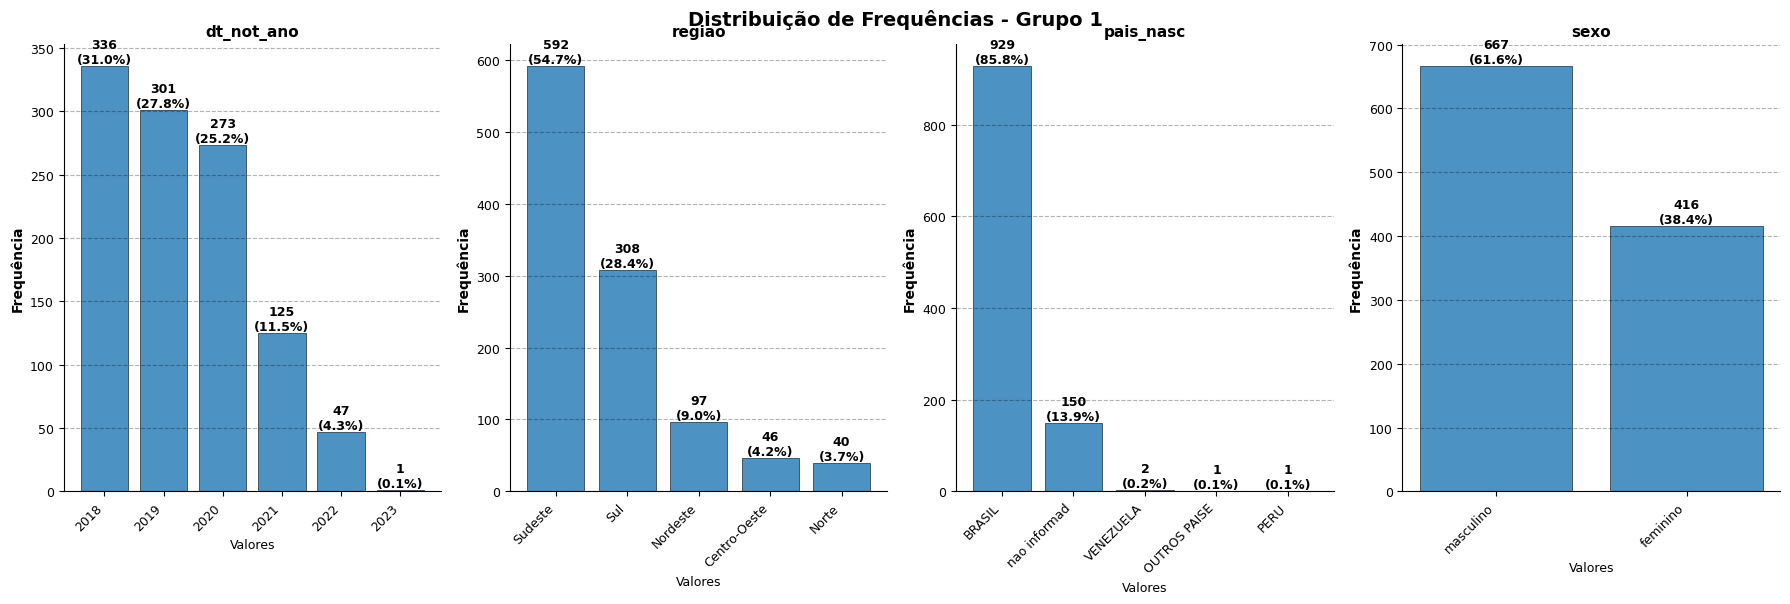

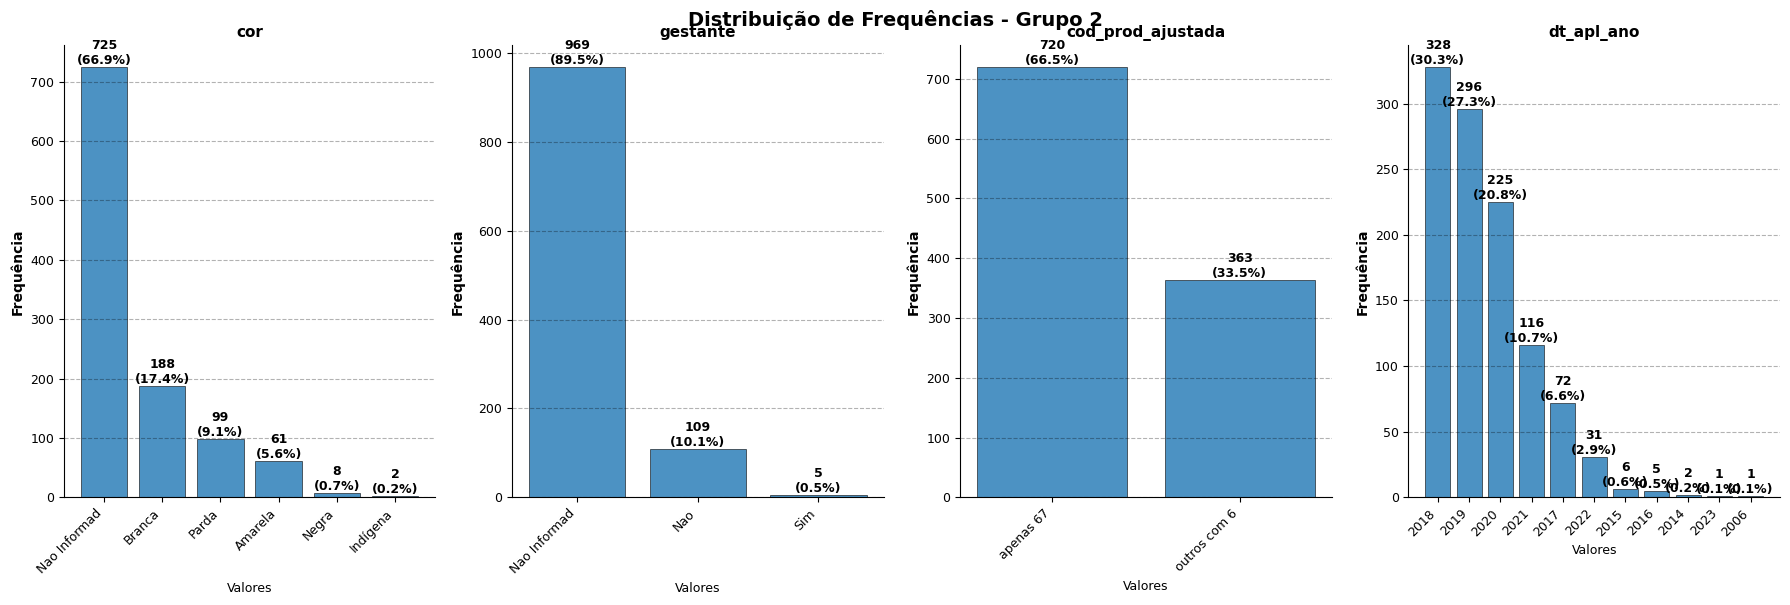

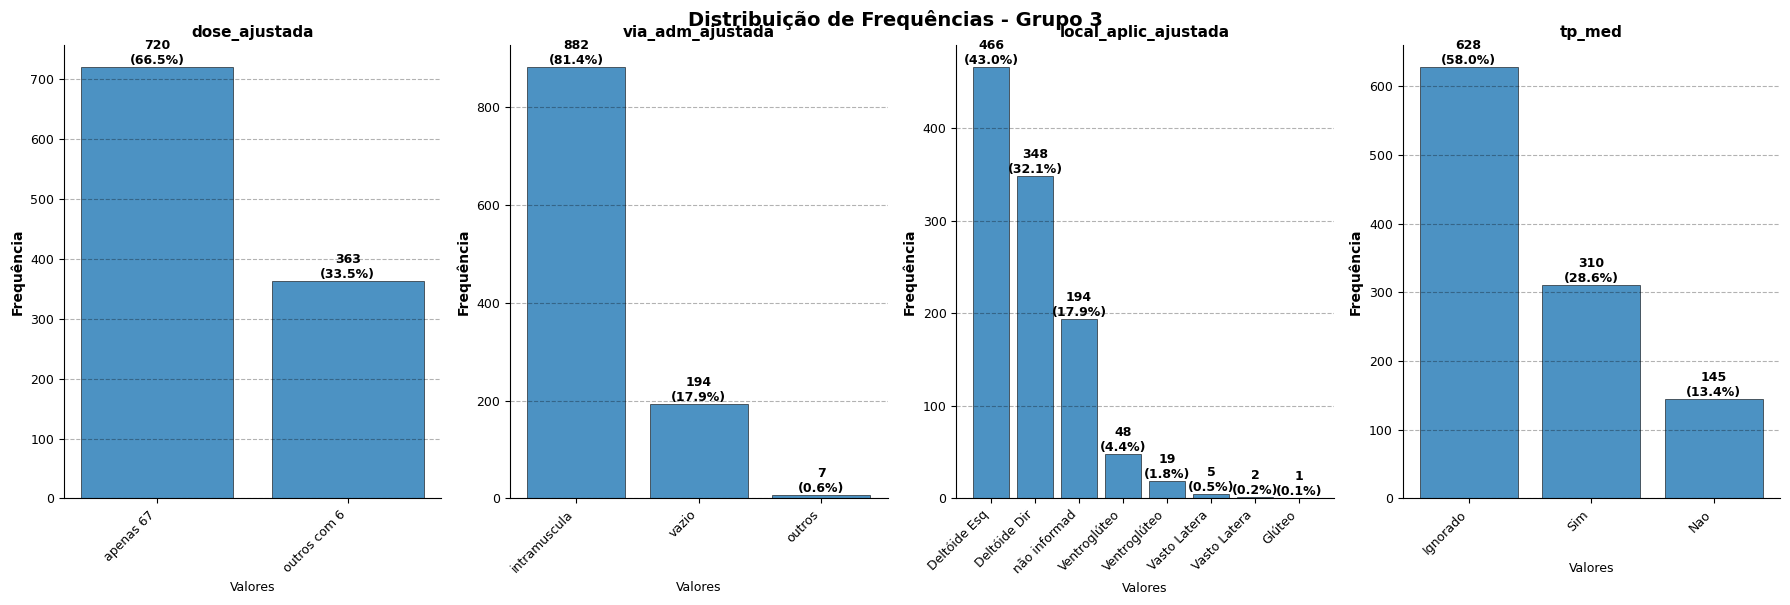

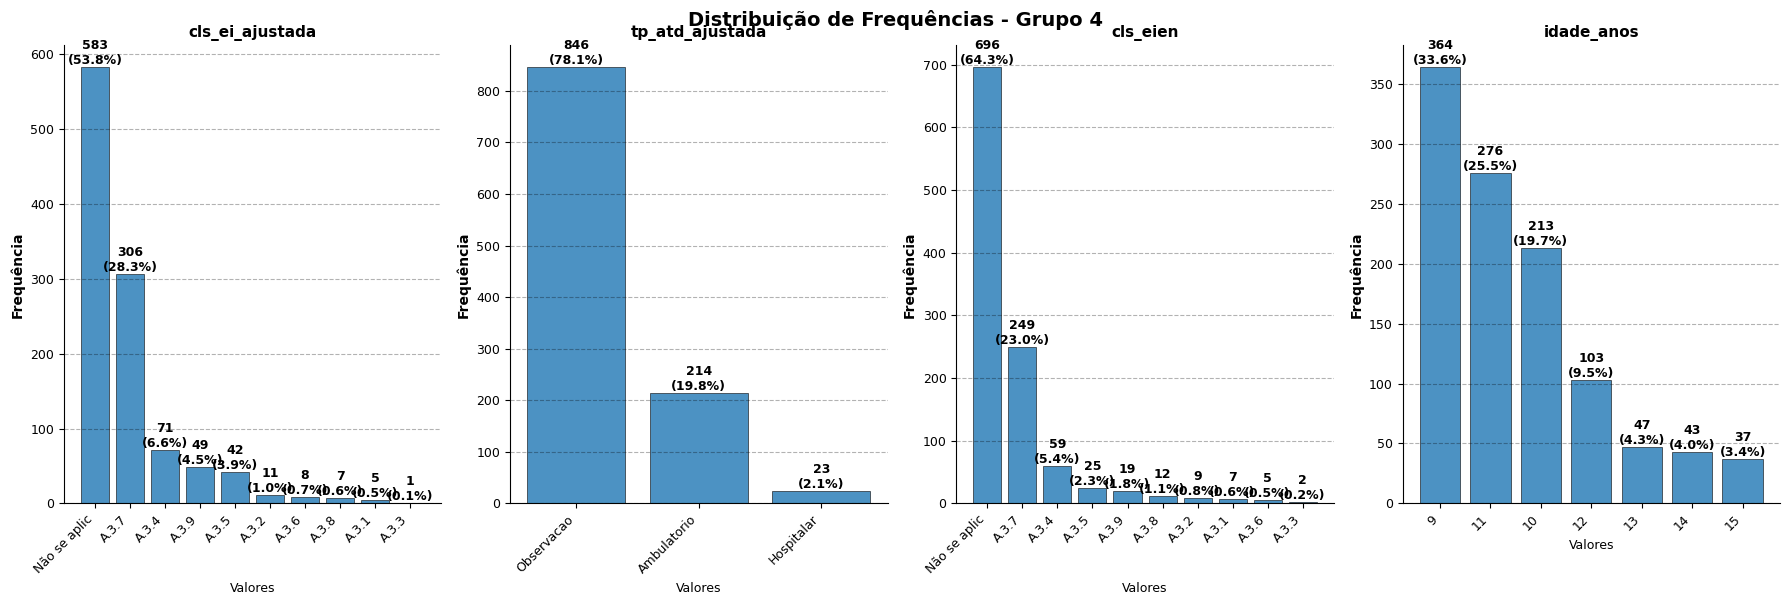

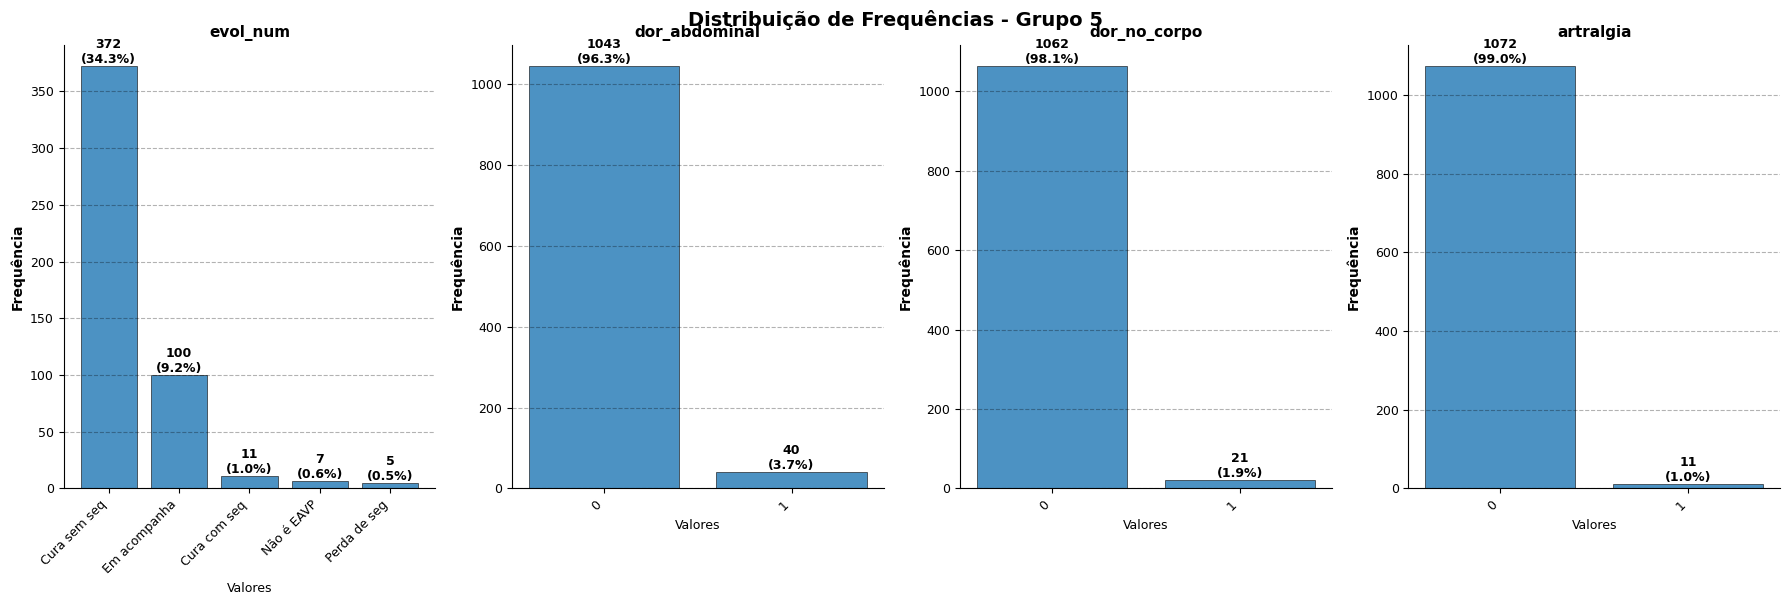

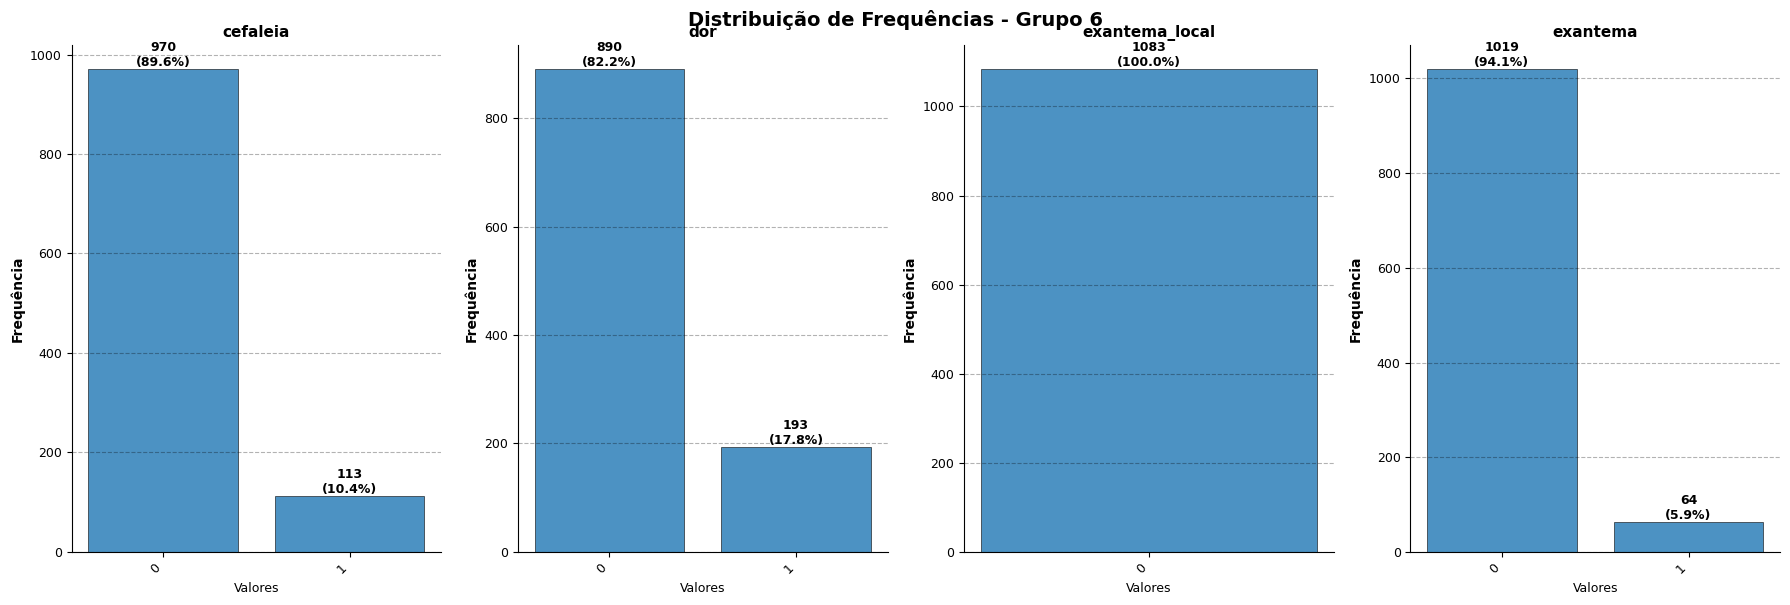

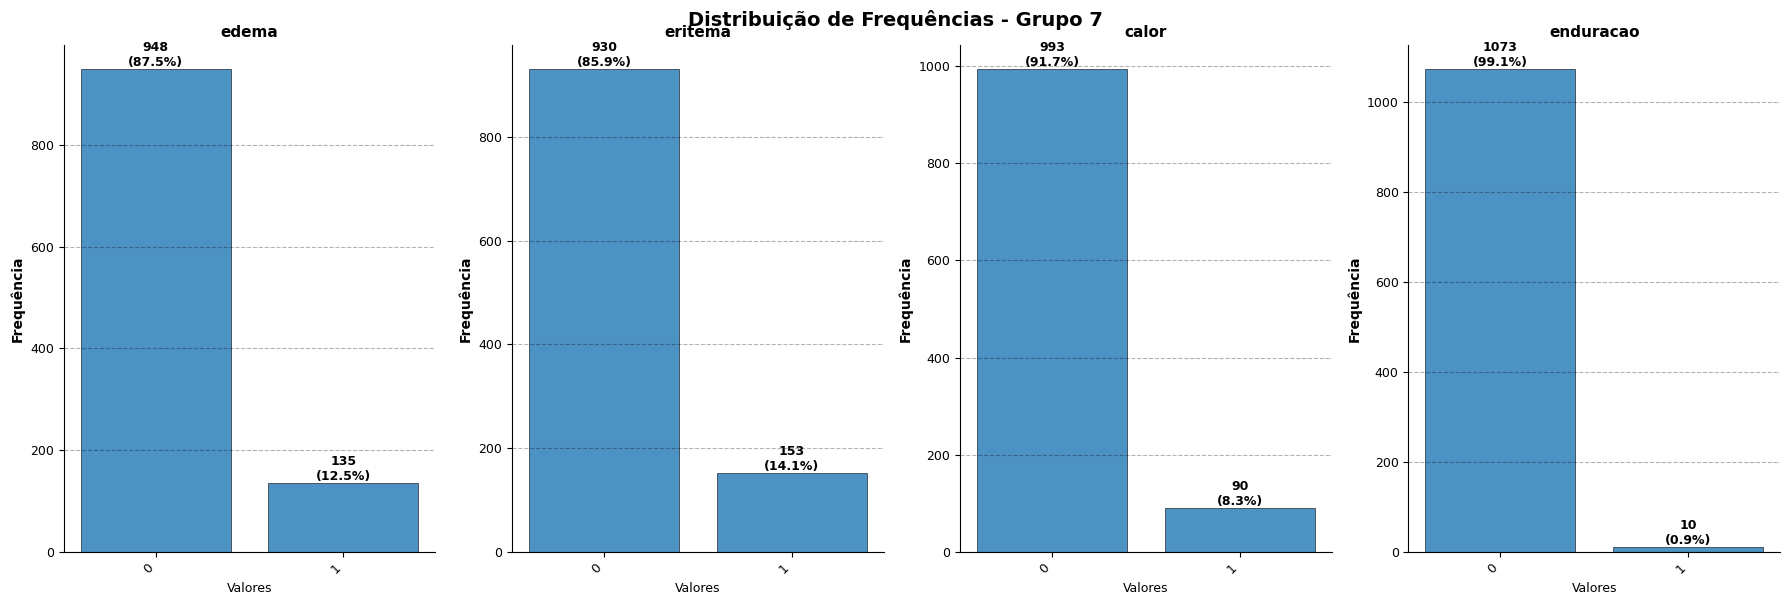

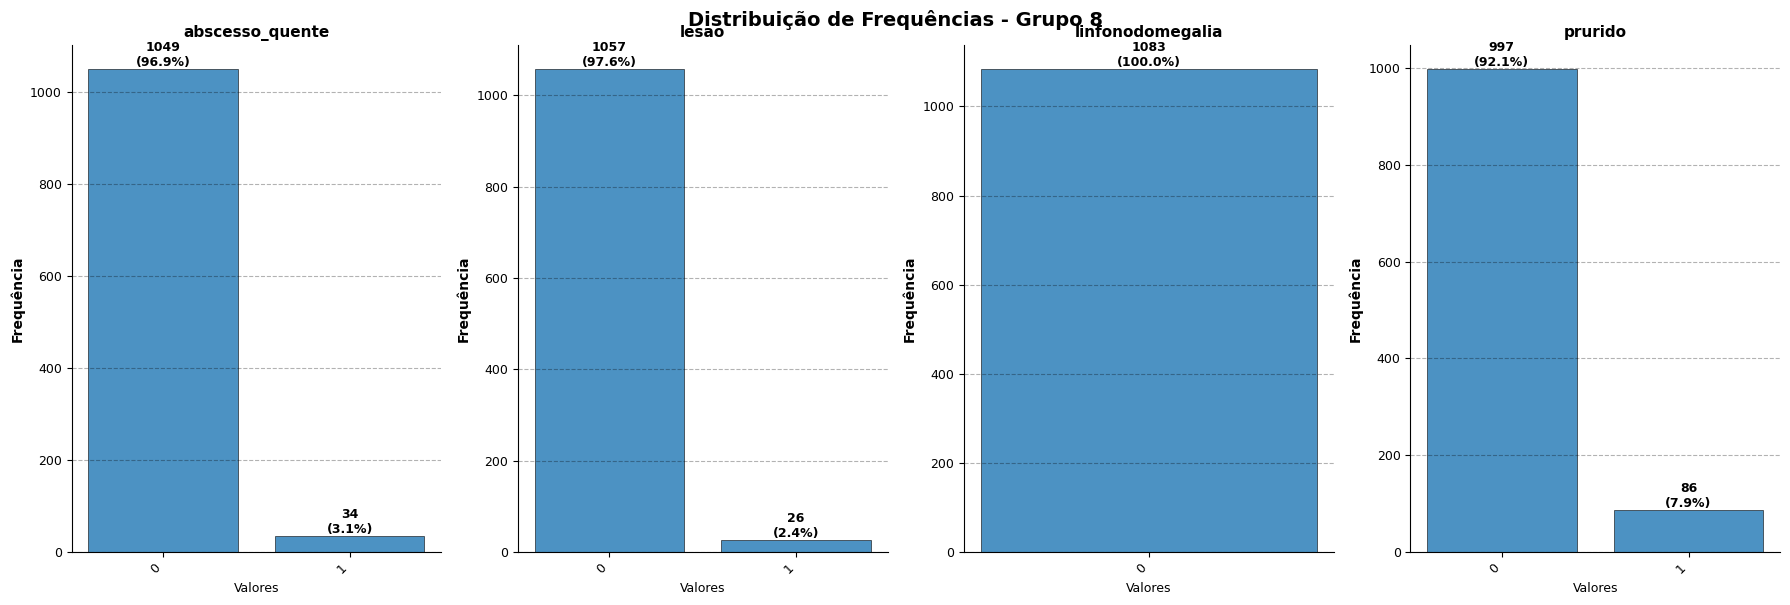

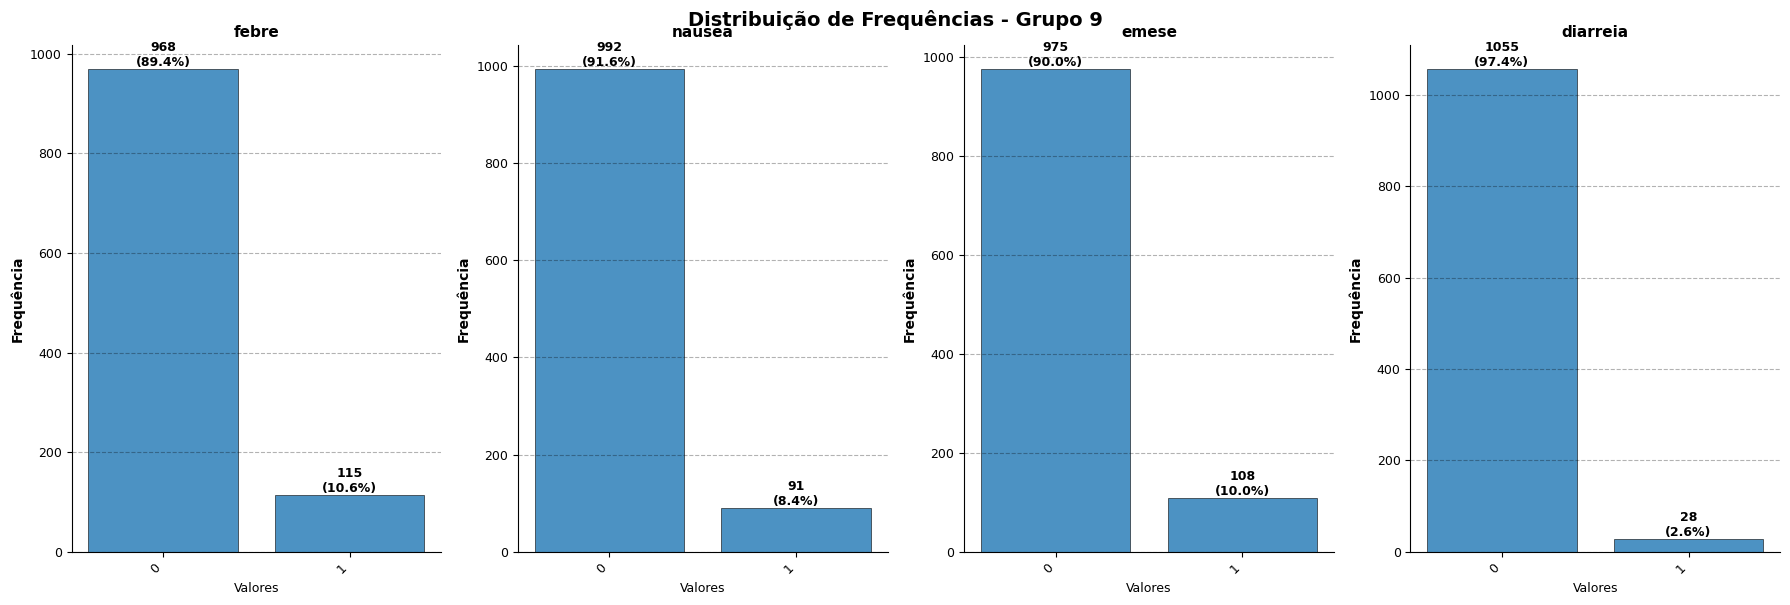

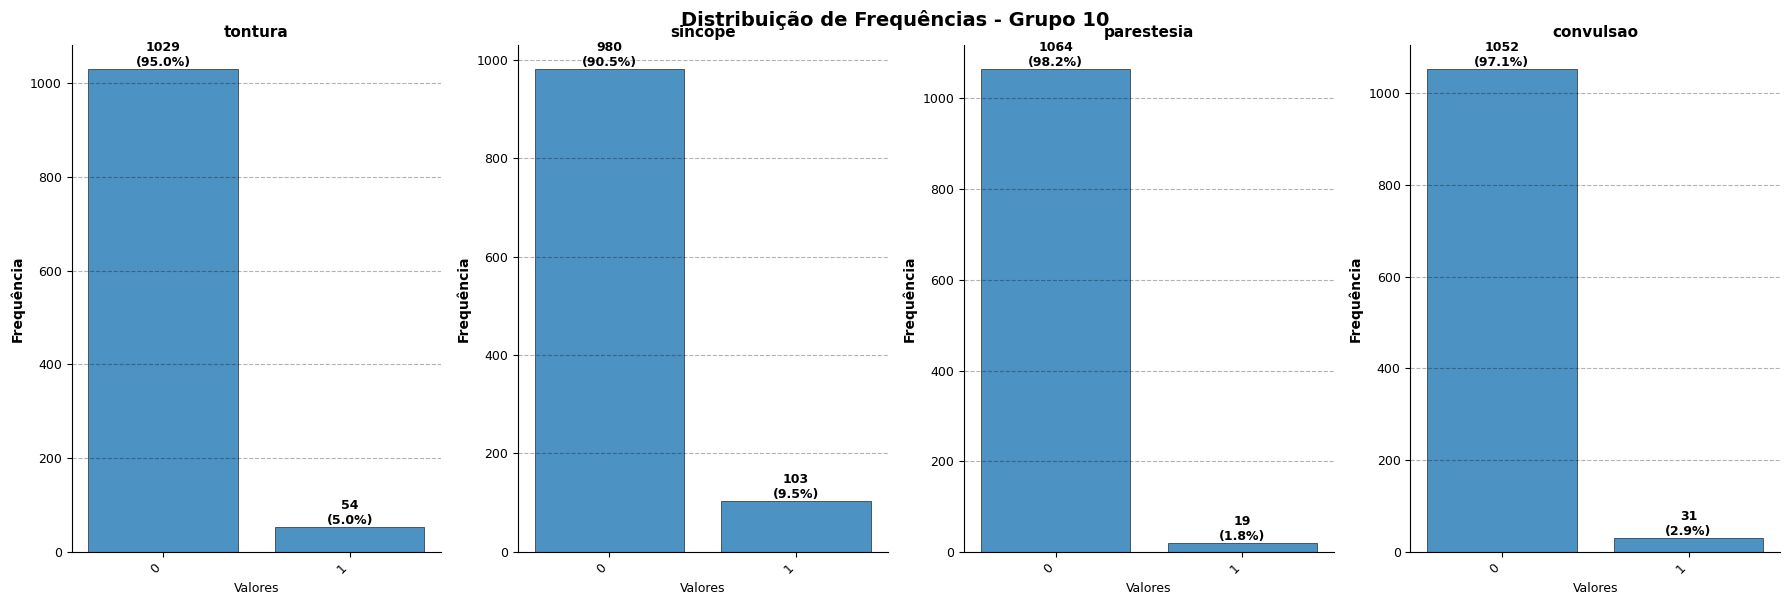

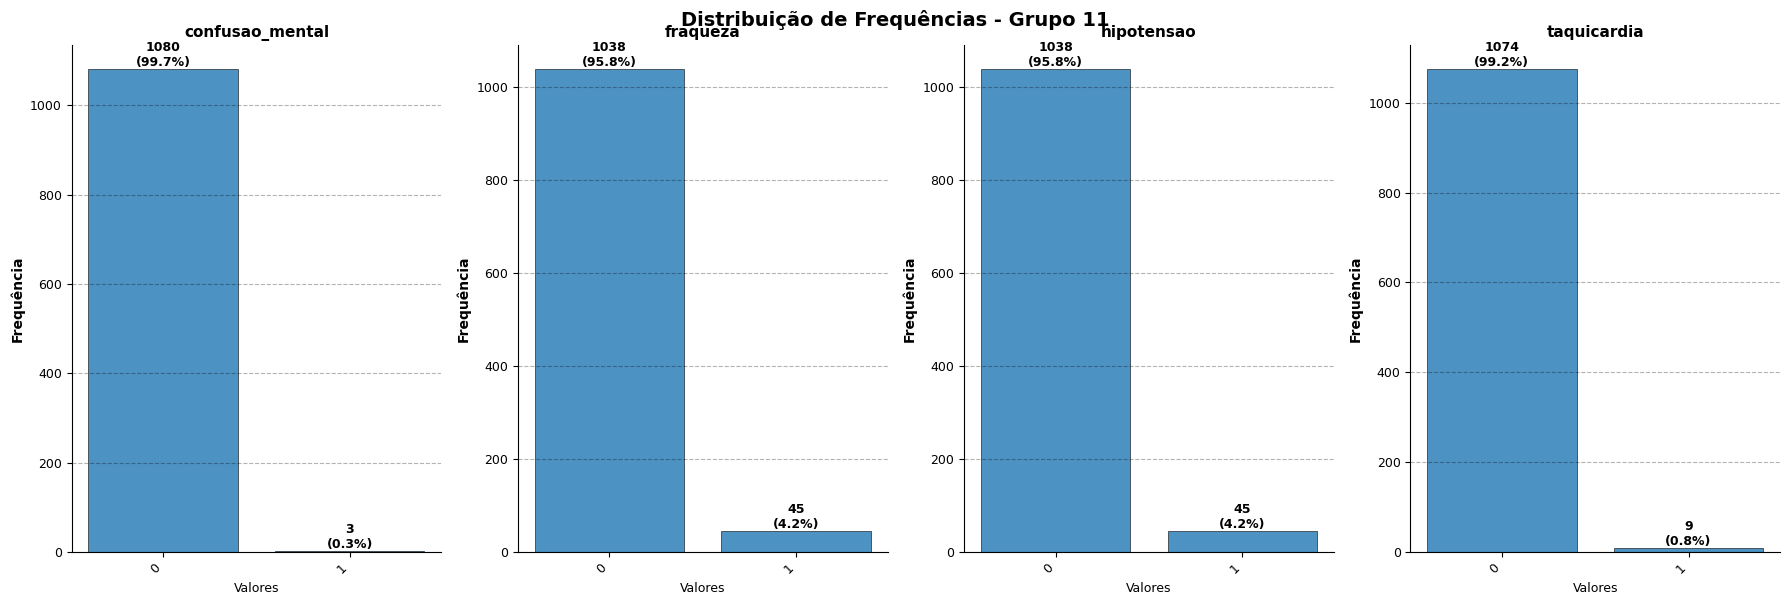

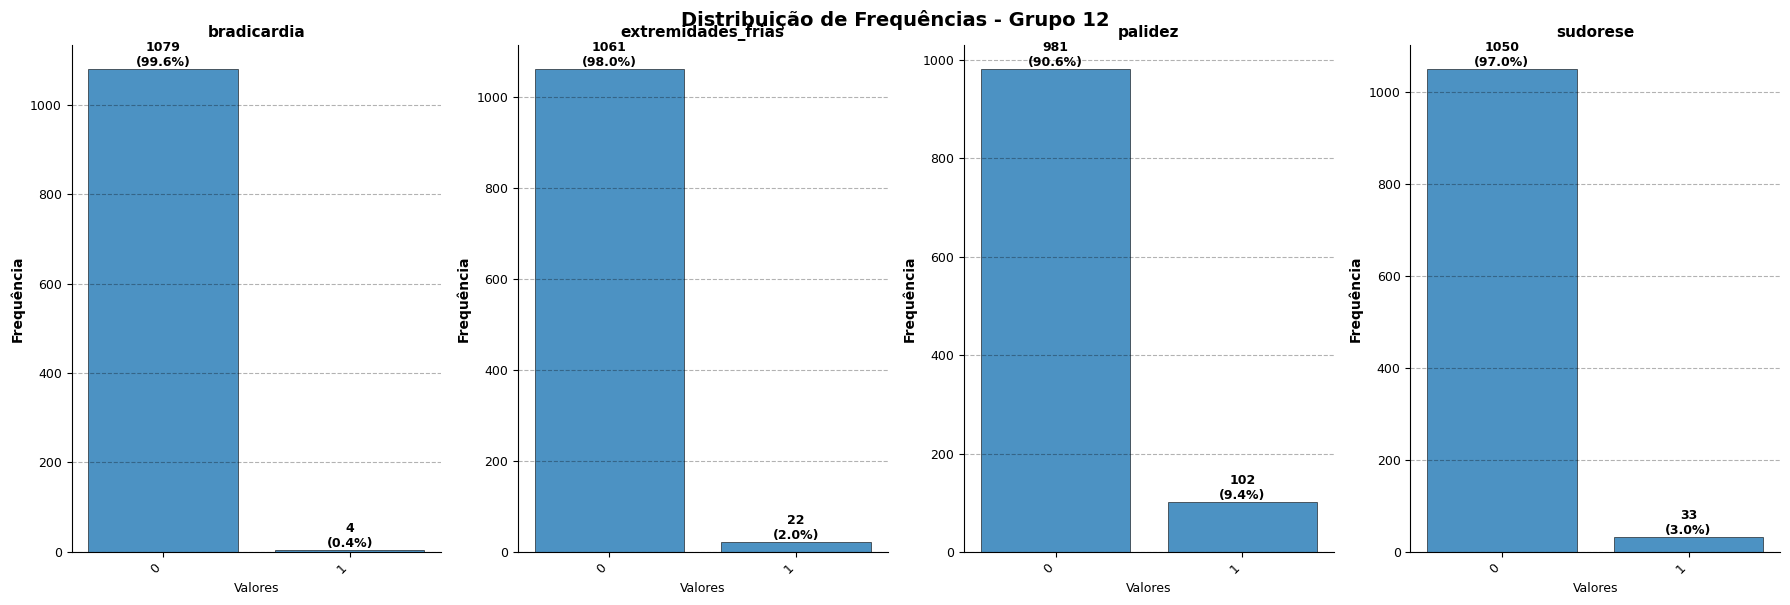

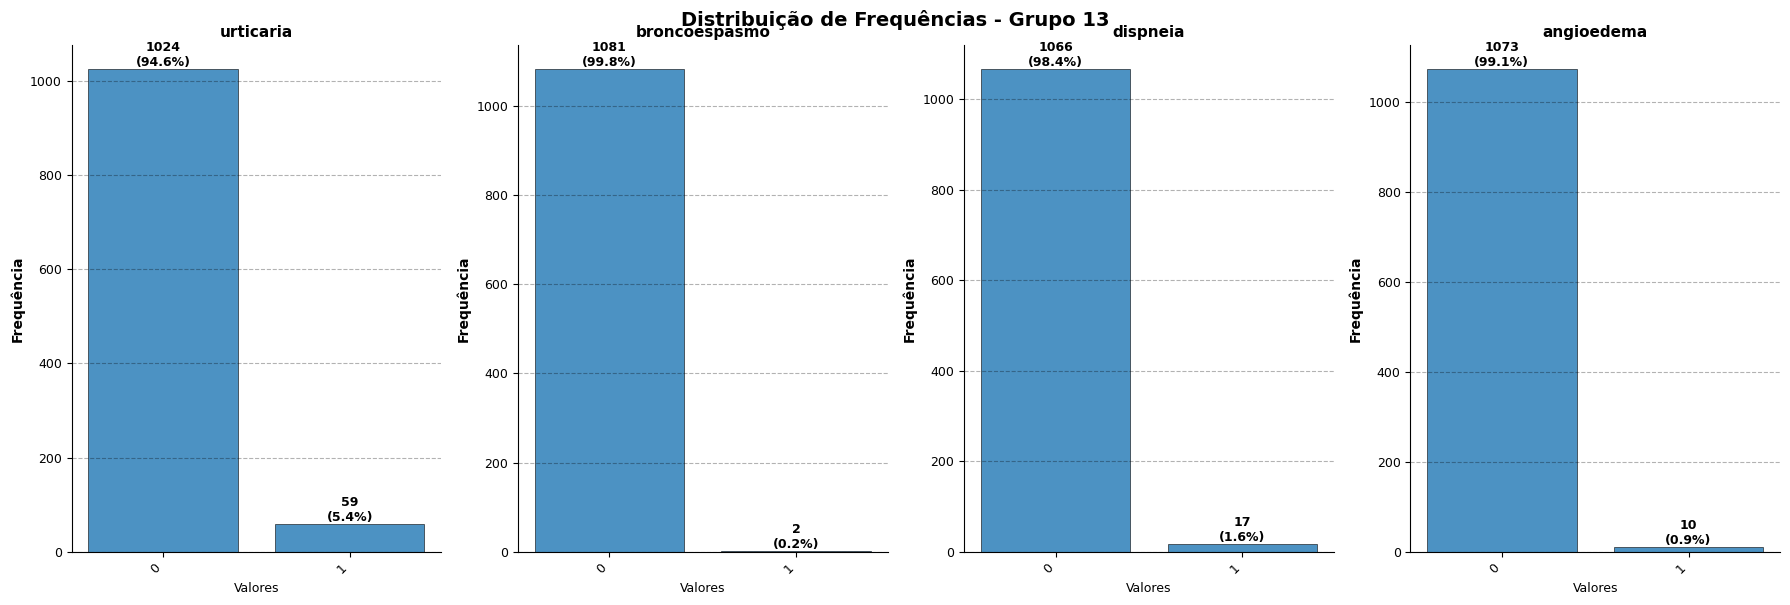

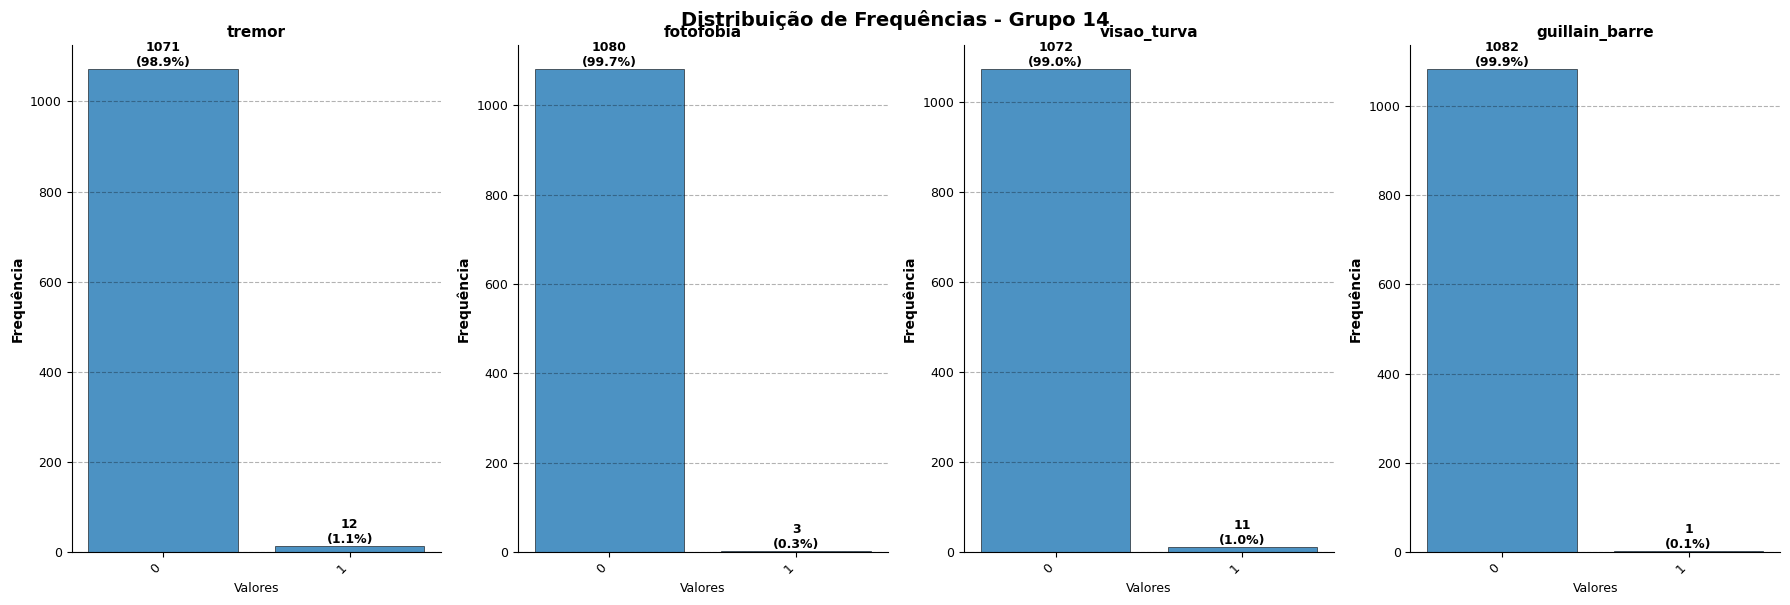

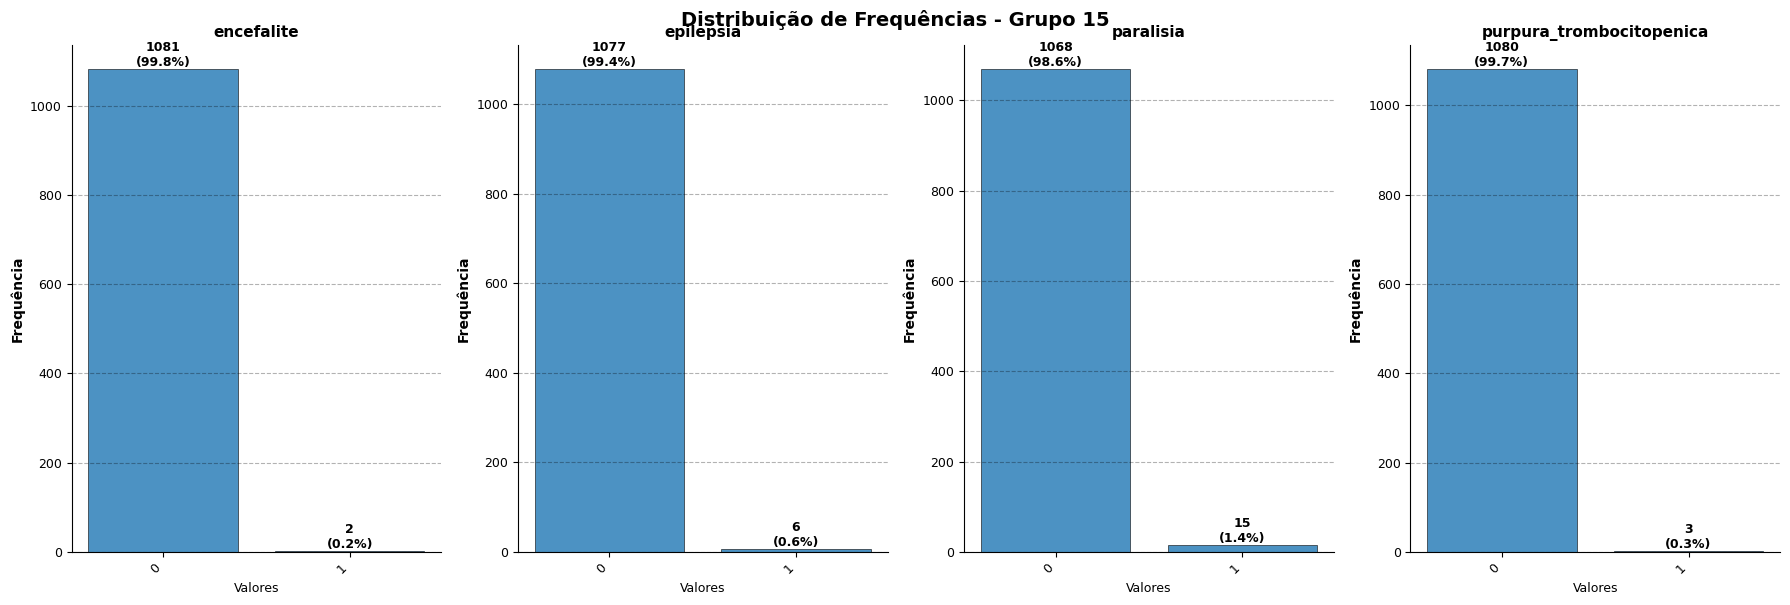

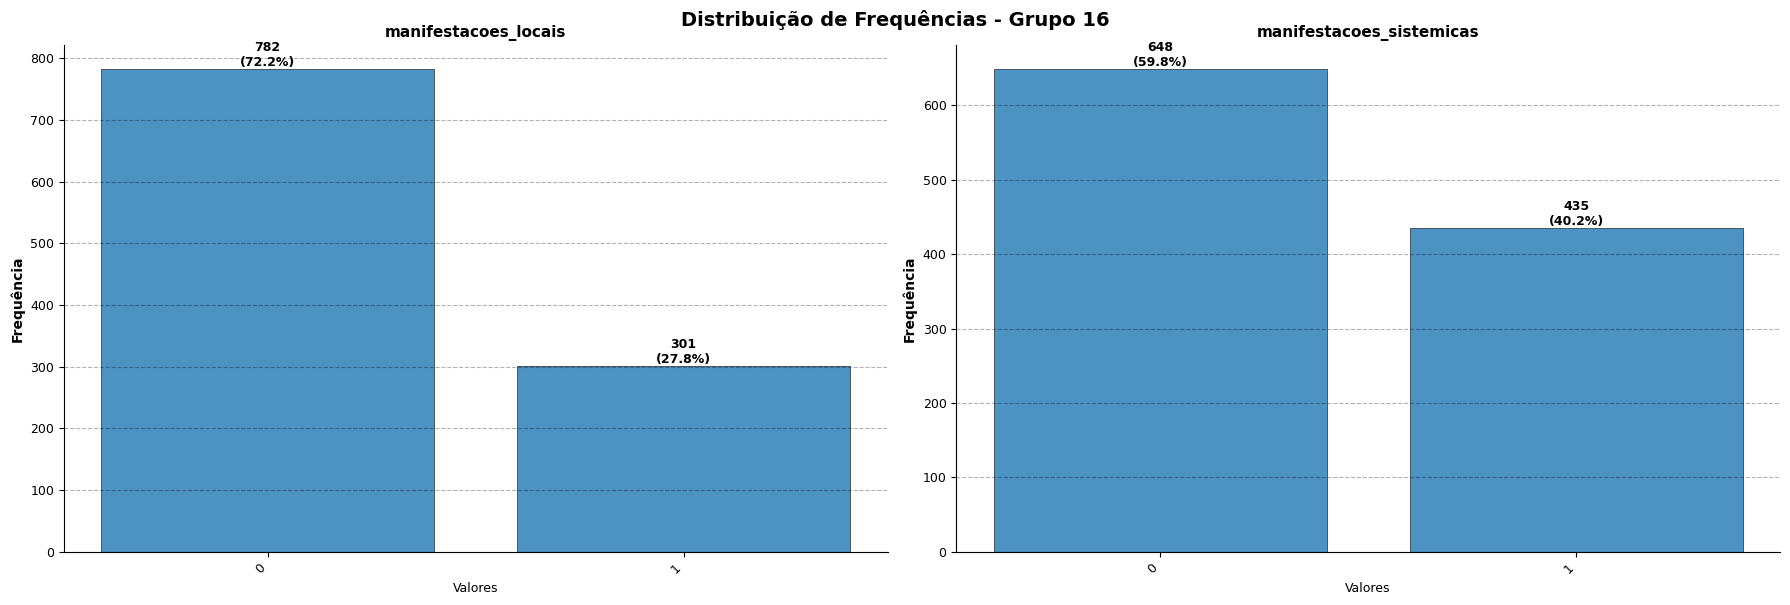


✅ Plotadas 62 variáveis em 16 gráfico(s) com frequência e percentual no mesmo gráfico


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

num_cols = len(colunas_explicativas)
num_grupos = ceil(num_cols / 4)

for grupo in range(num_grupos):
    inicio = grupo * 4
    fim = min(inicio + 4, num_cols)
    cols_grupo = colunas_explicativas[inicio:fim]
    
    num_subplots = len(cols_grupo)
    fig, axes = plt.subplots(1, num_subplots, figsize=(18, 6))
    
    # Se há apenas 1 subplot, axes não é um array
    if num_subplots == 1:
        axes = [axes]
    
    for idx, col in enumerate(cols_grupo):
        ax = axes[idx]
        
        if dados_finais[col].notna().sum() > 0:
            value_counts = dados_finais[col].value_counts().sort_values(ascending=False)
            
            # Limitar a 15 valores para não ficar muito poluído
            if len(value_counts) > 15:
                value_counts = value_counts.head(15)
            
            # Calcular frequências e percentuais
            frequencias = value_counts.values
            percentuais = (value_counts / len(dados_finais)) * 100
            total_dados = len(dados_finais)
            
            # Criar gráfico de barras - azul padrão
            bars = ax.bar(range(len(value_counts)), frequencias, color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.5)
            
            # Adicionar valores nas barras (frequência e percentual)
            for i, bar in enumerate(bars):
                height = bar.get_height()
                freq = frequencias[i]
                pct = percentuais.iloc[i]
                
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(freq)}\n({pct:.1f}%)',
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
            
            # Configurar eixos e títulos
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels([str(v)[:12] for v in value_counts.index], rotation=45, ha='right', fontsize=9, color='black')
            ax.set_ylabel('Frequência', fontsize=10, fontweight='bold', color='black')
            ax.set_xlabel('Valores', fontsize=9, color='black')
            ax.set_title(f'{col}', fontsize=11, fontweight='bold', color='black')
            ax.grid(axis='y', alpha=0.3, linestyle='--', color='black')
            
            # Colorir eixos e labels em preto
            ax.tick_params(colors='black', labelsize=9)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_color('black')
            ax.spines['bottom'].set_color('black')
            
        else:
            ax.text(0.5, 0.5, f'{col}\n(Sem dados)', ha='center', va='center', fontsize=11, color='black')
            ax.axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Distribuição de Frequências - Grupo {grupo + 1}', 
                fontsize=14, fontweight='bold', y=1.00, color='black')
    plt.show()

print(f"\n✅ Plotadas {num_cols} variáveis em {num_grupos} gráfico(s) com frequência e percentual no mesmo gráfico")


Gerando gráficos para: dt_not_ano vs cls_fin_ajustada


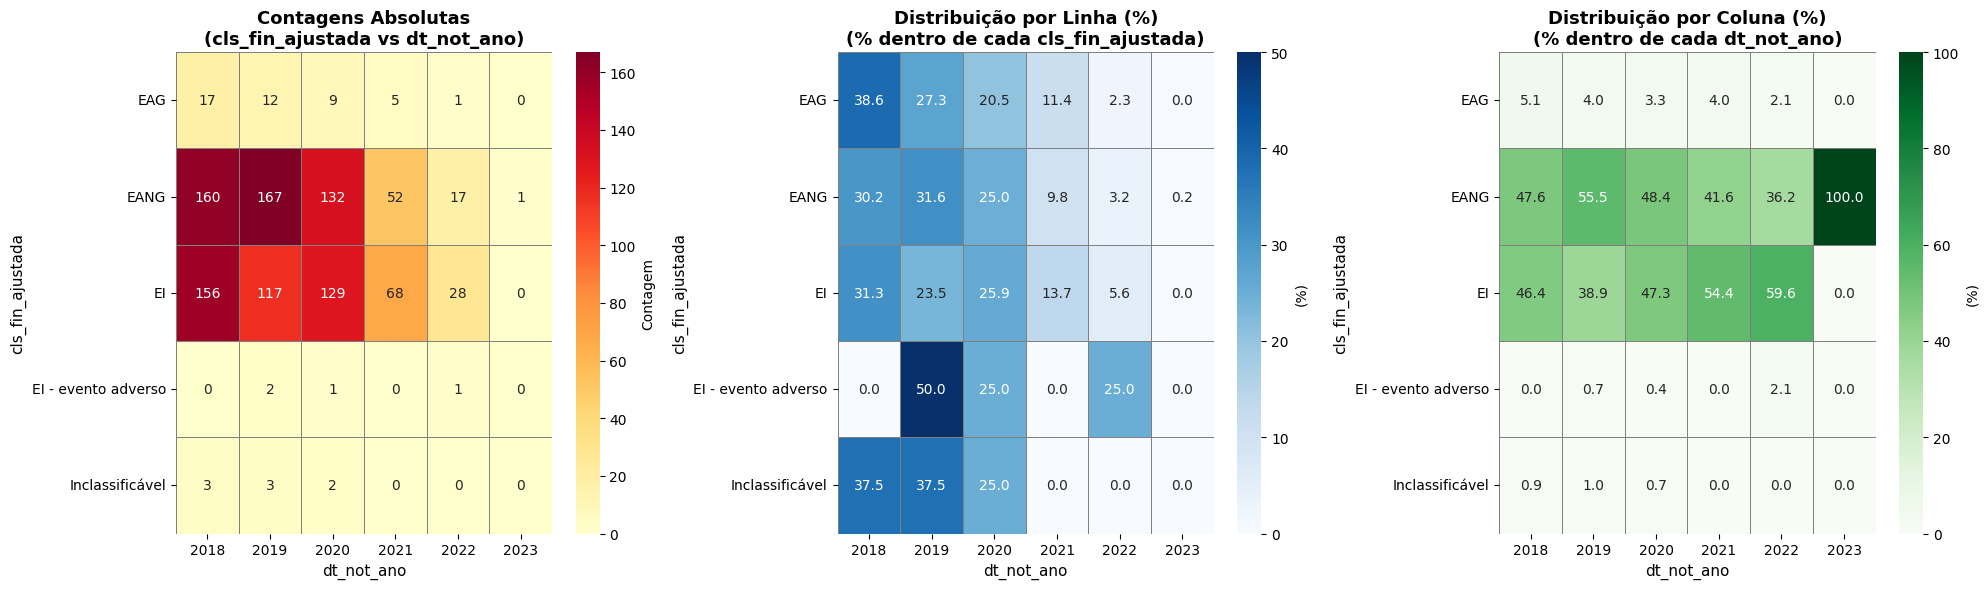


Gerando gráficos para: regiao vs cls_fin_ajustada


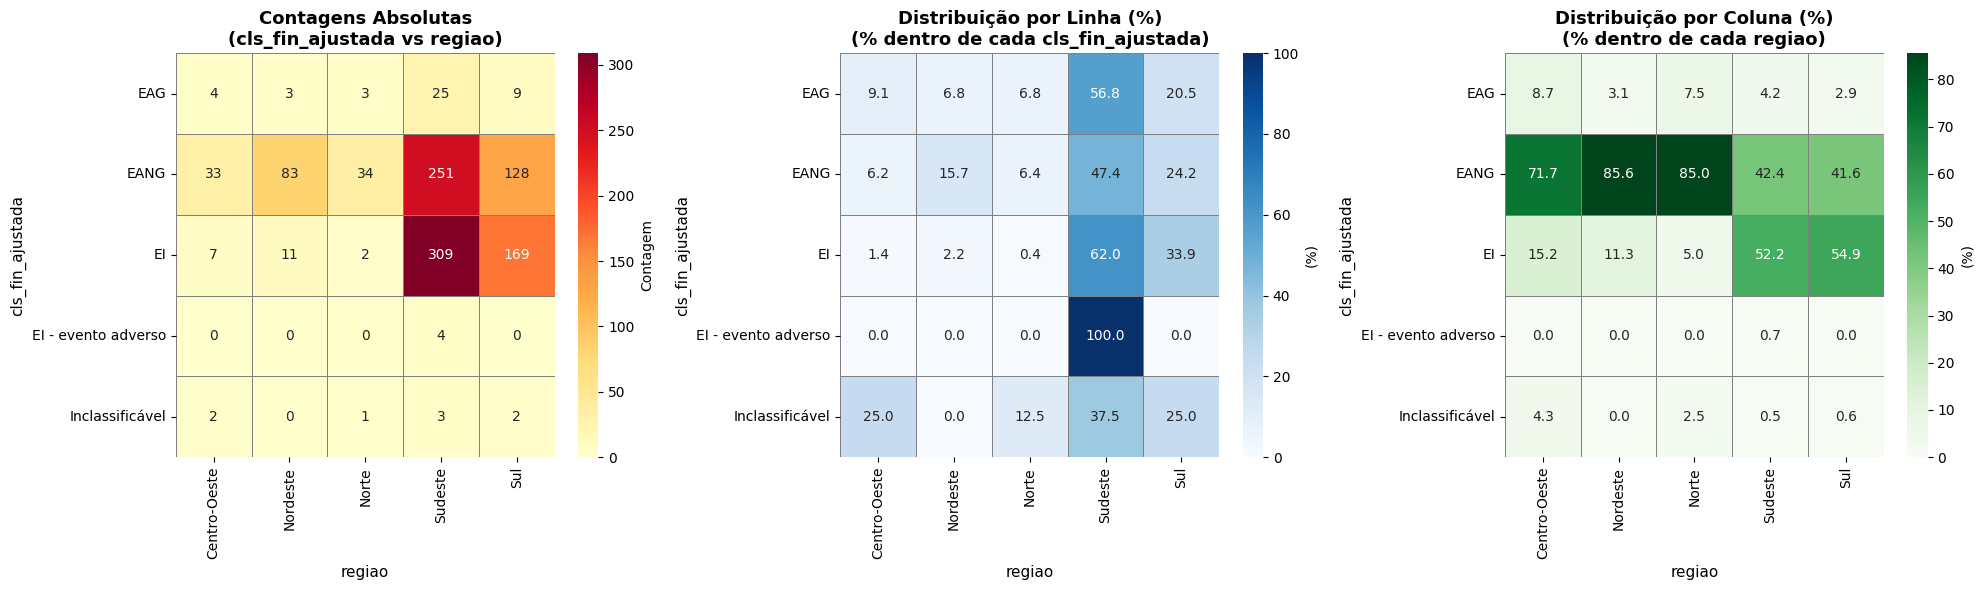


Gerando gráficos para: pais_nasc vs cls_fin_ajustada


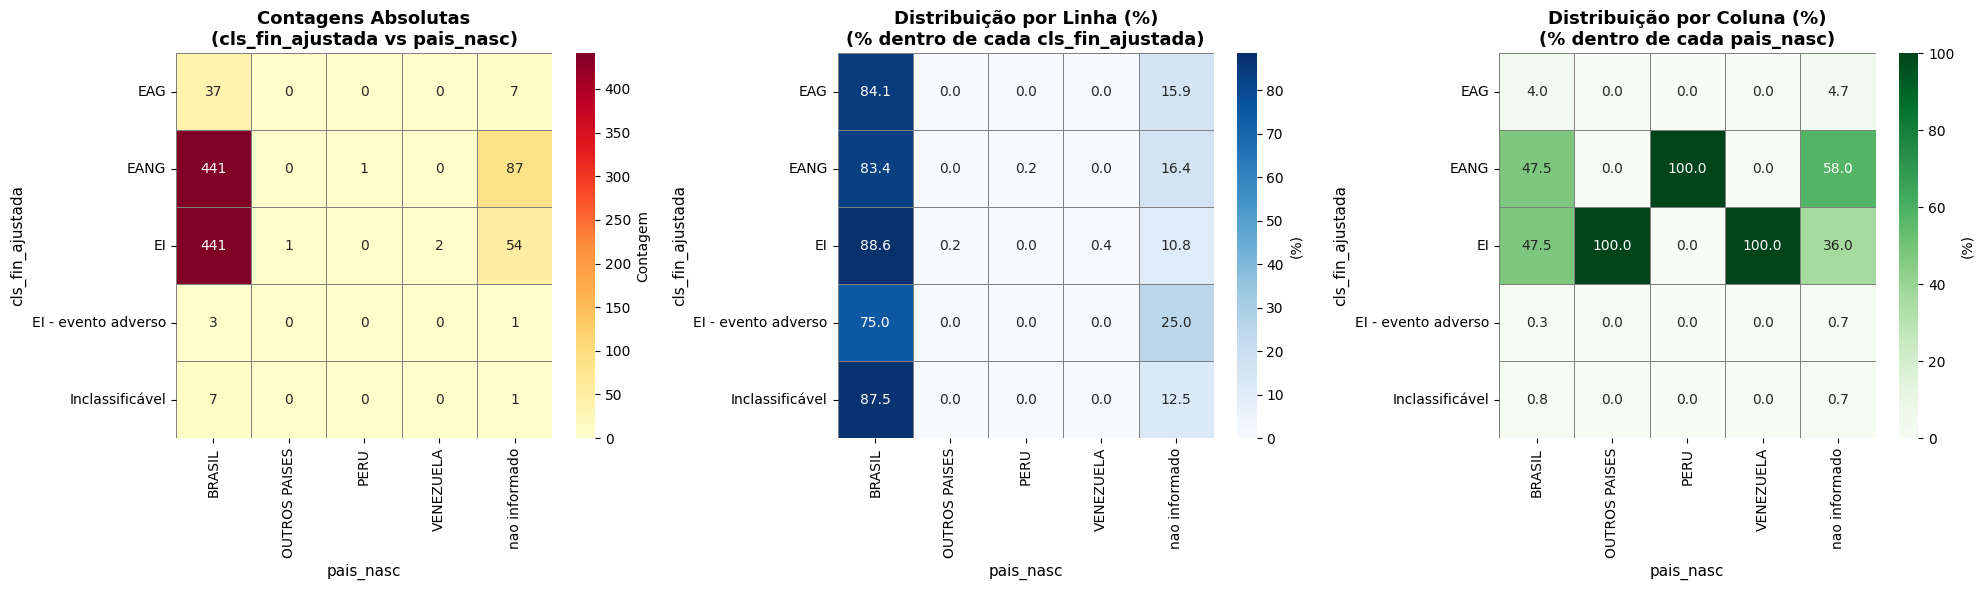


Gerando gráficos para: sexo vs cls_fin_ajustada


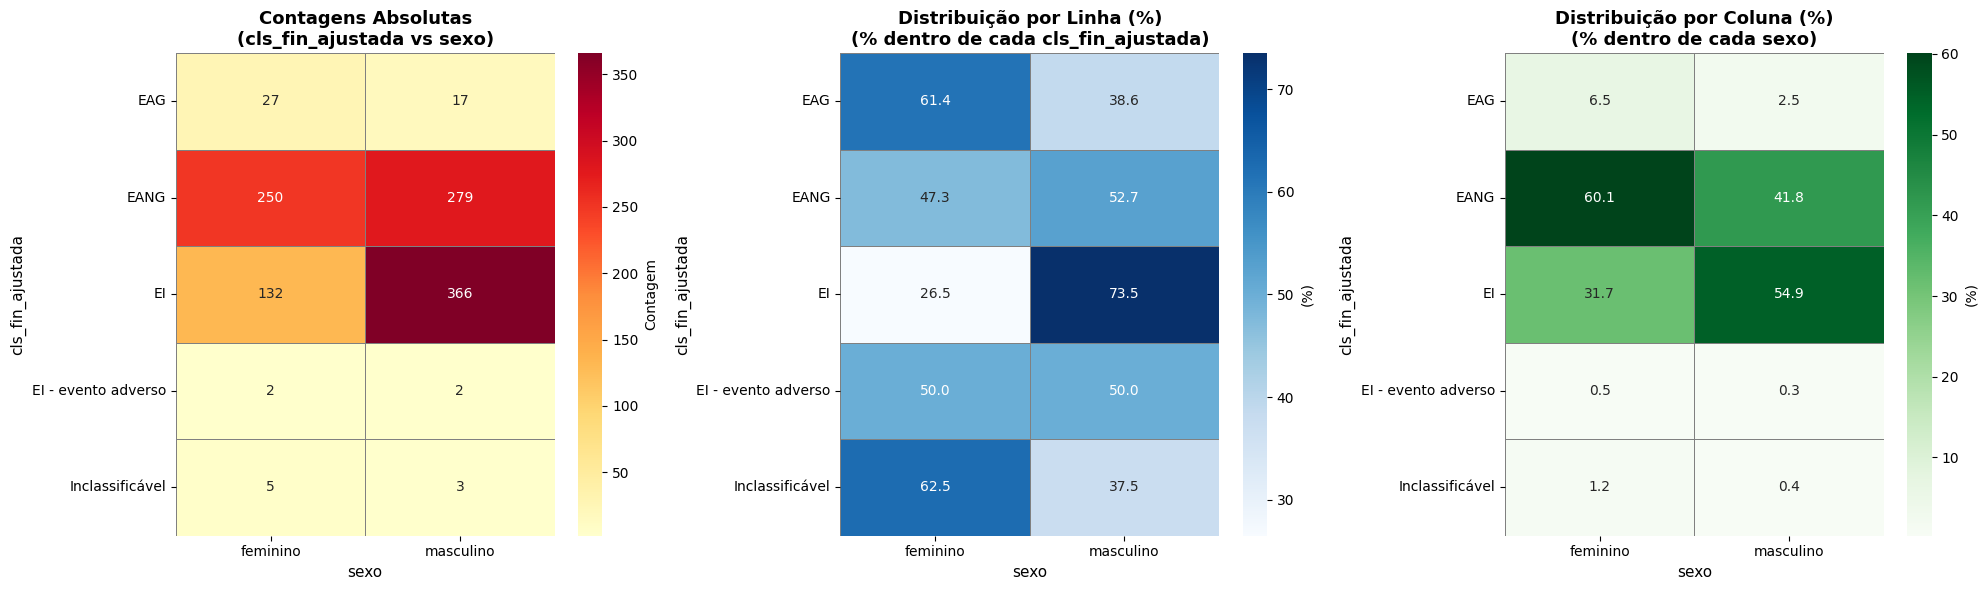


Gerando gráficos para: cor vs cls_fin_ajustada


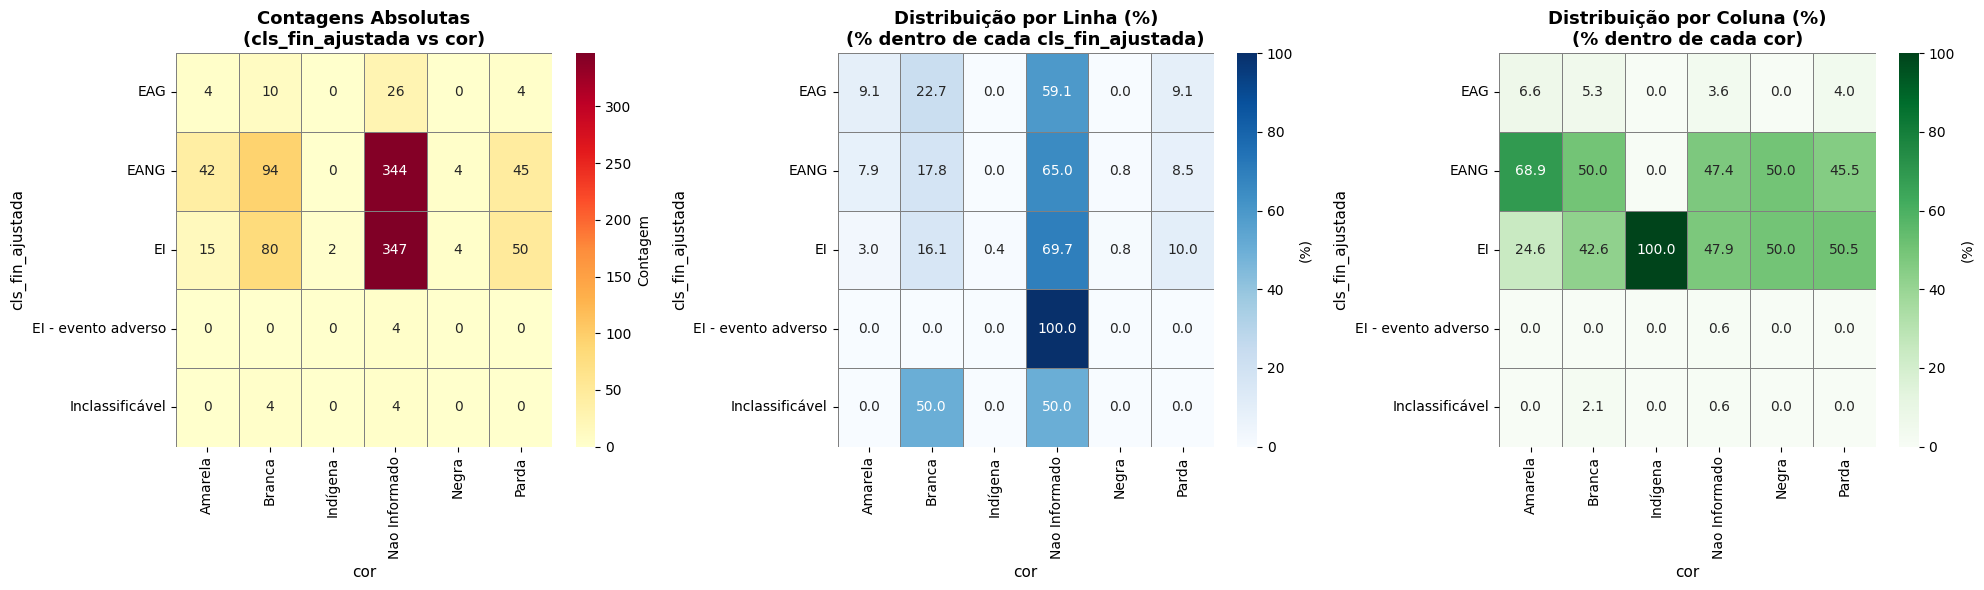


Gerando gráficos para: gestante vs cls_fin_ajustada


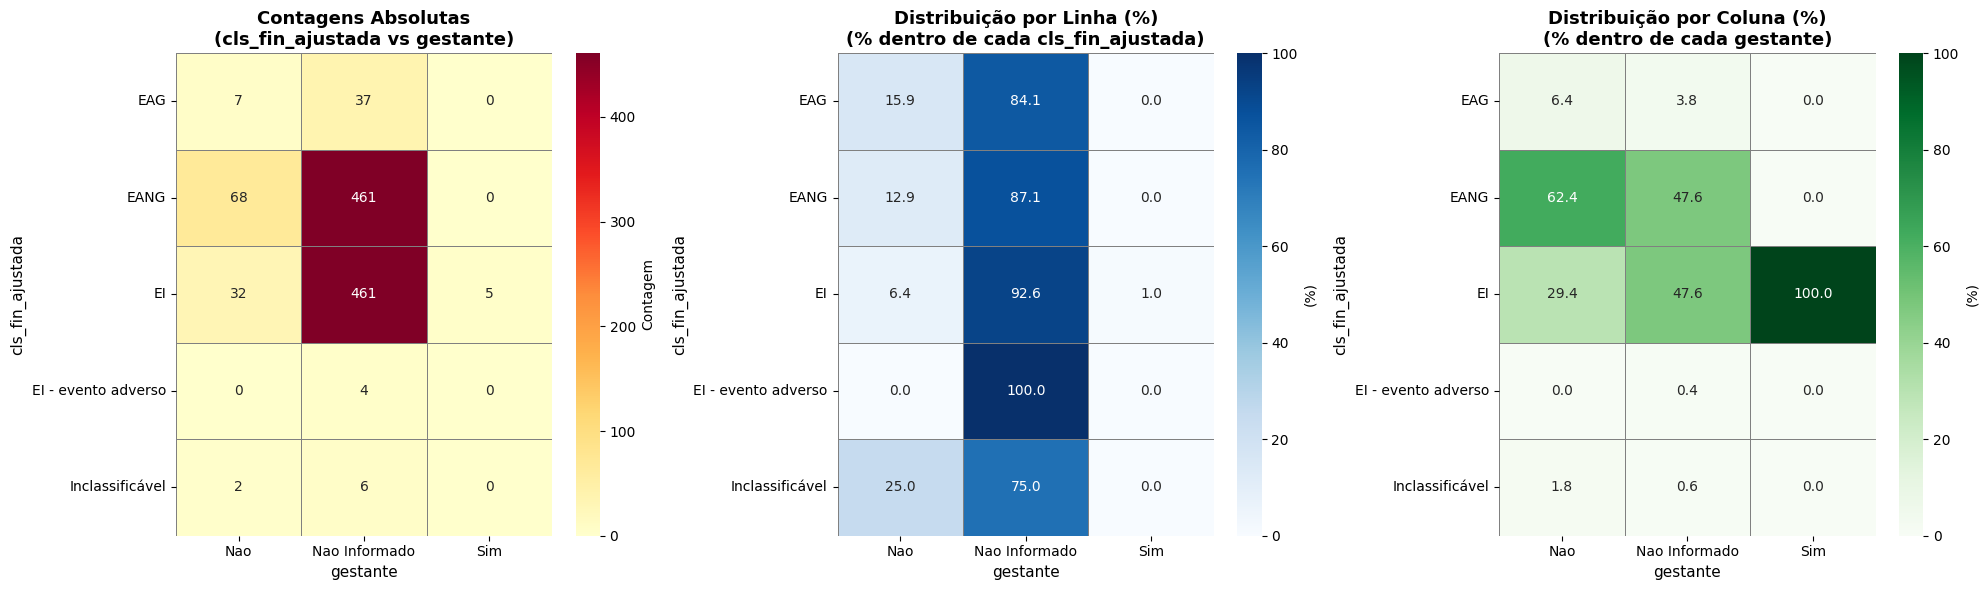


Gerando gráficos para: cod_prod_ajustada vs cls_fin_ajustada


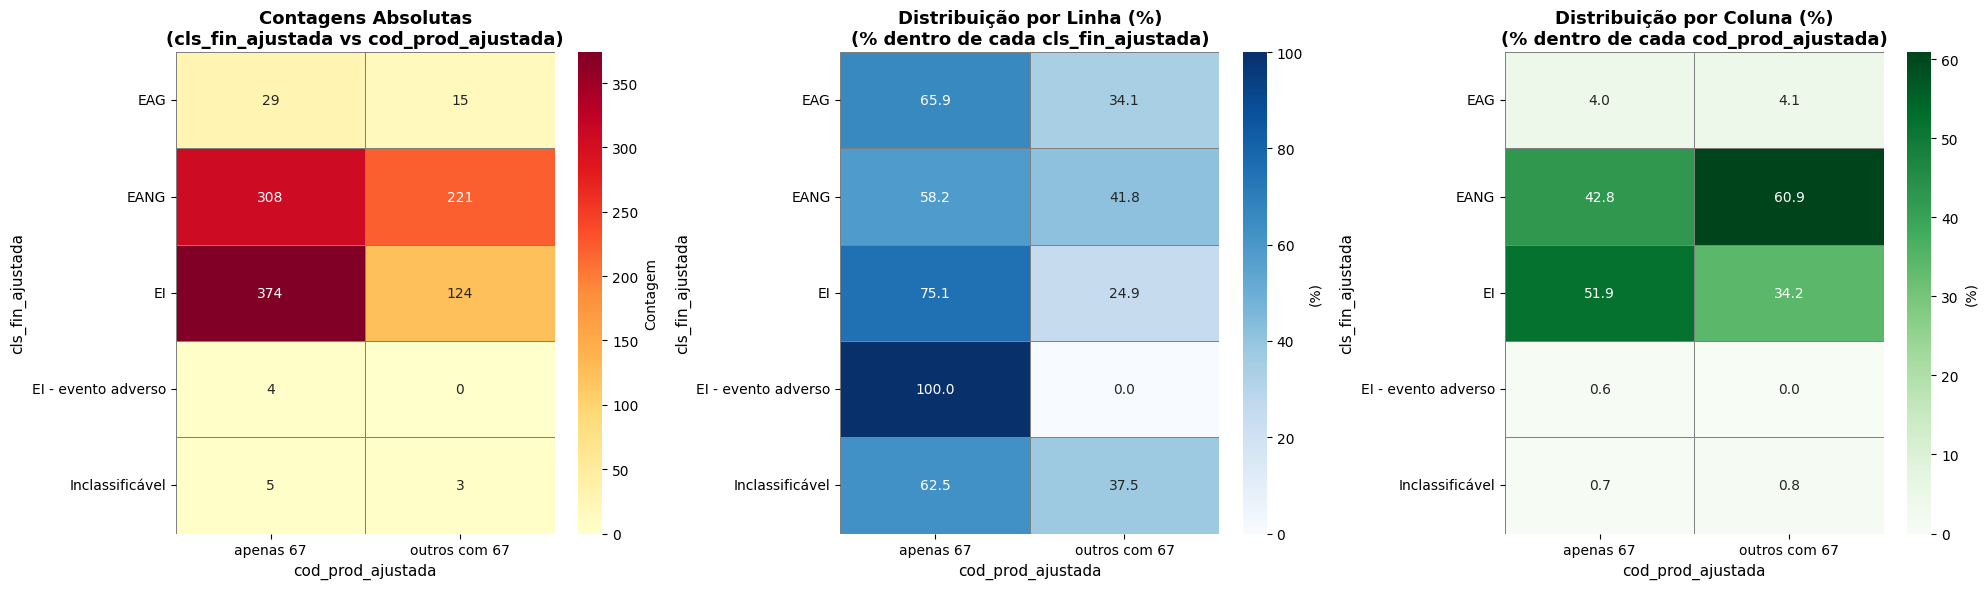


Gerando gráficos para: dt_apl_ano vs cls_fin_ajustada


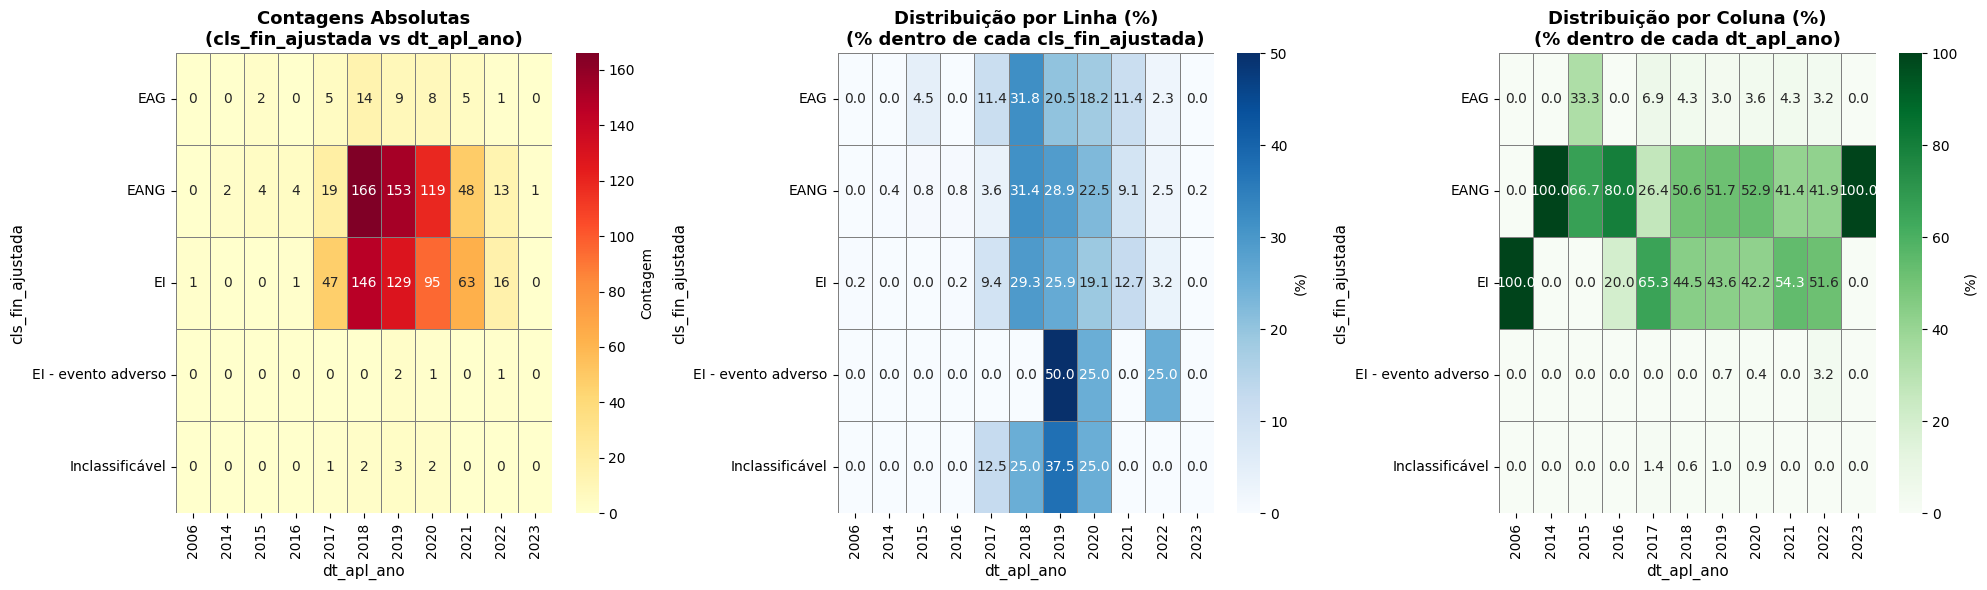


Gerando gráficos para: dose_ajustada vs cls_fin_ajustada


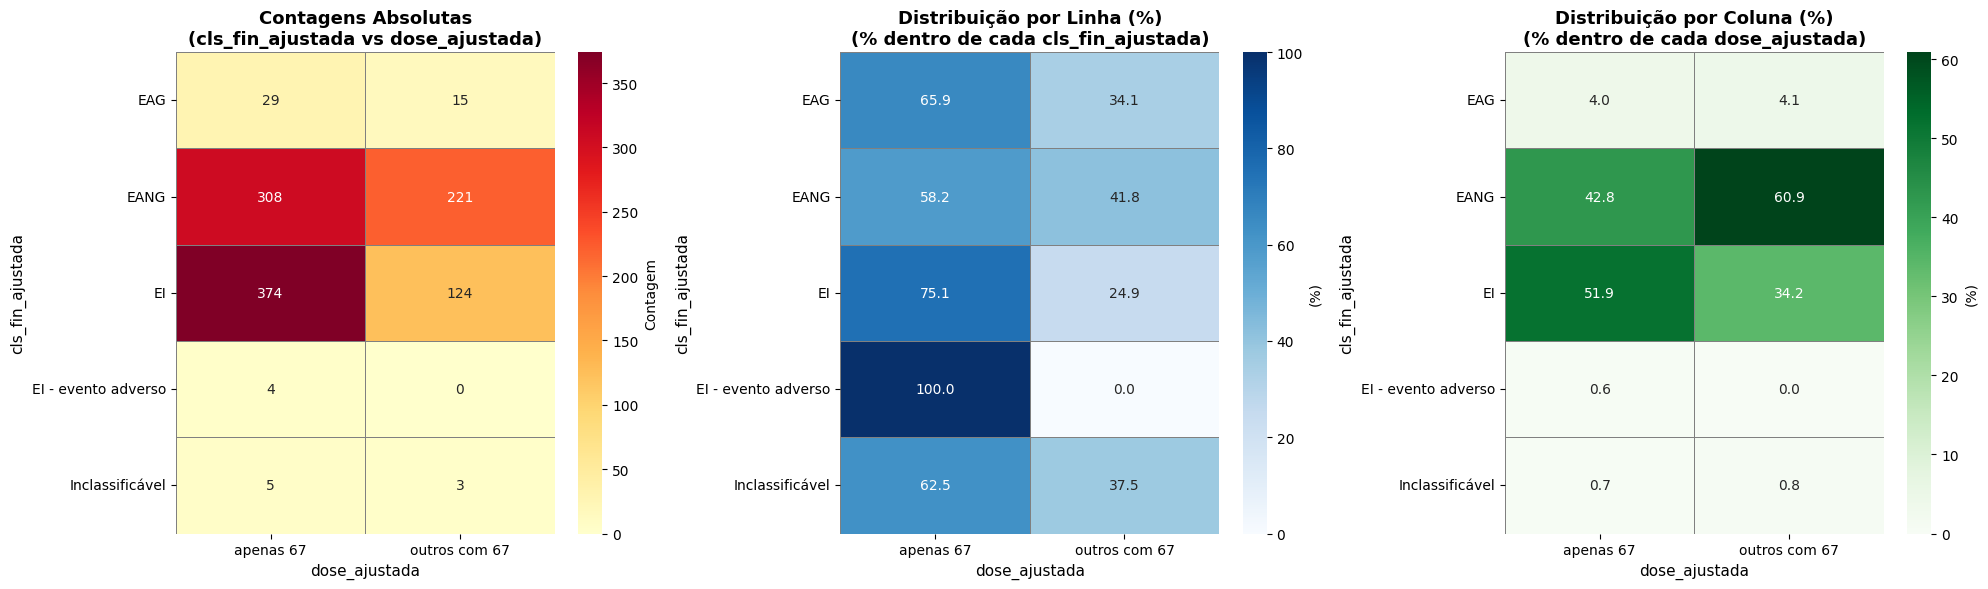


Gerando gráficos para: via_adm_ajustada vs cls_fin_ajustada


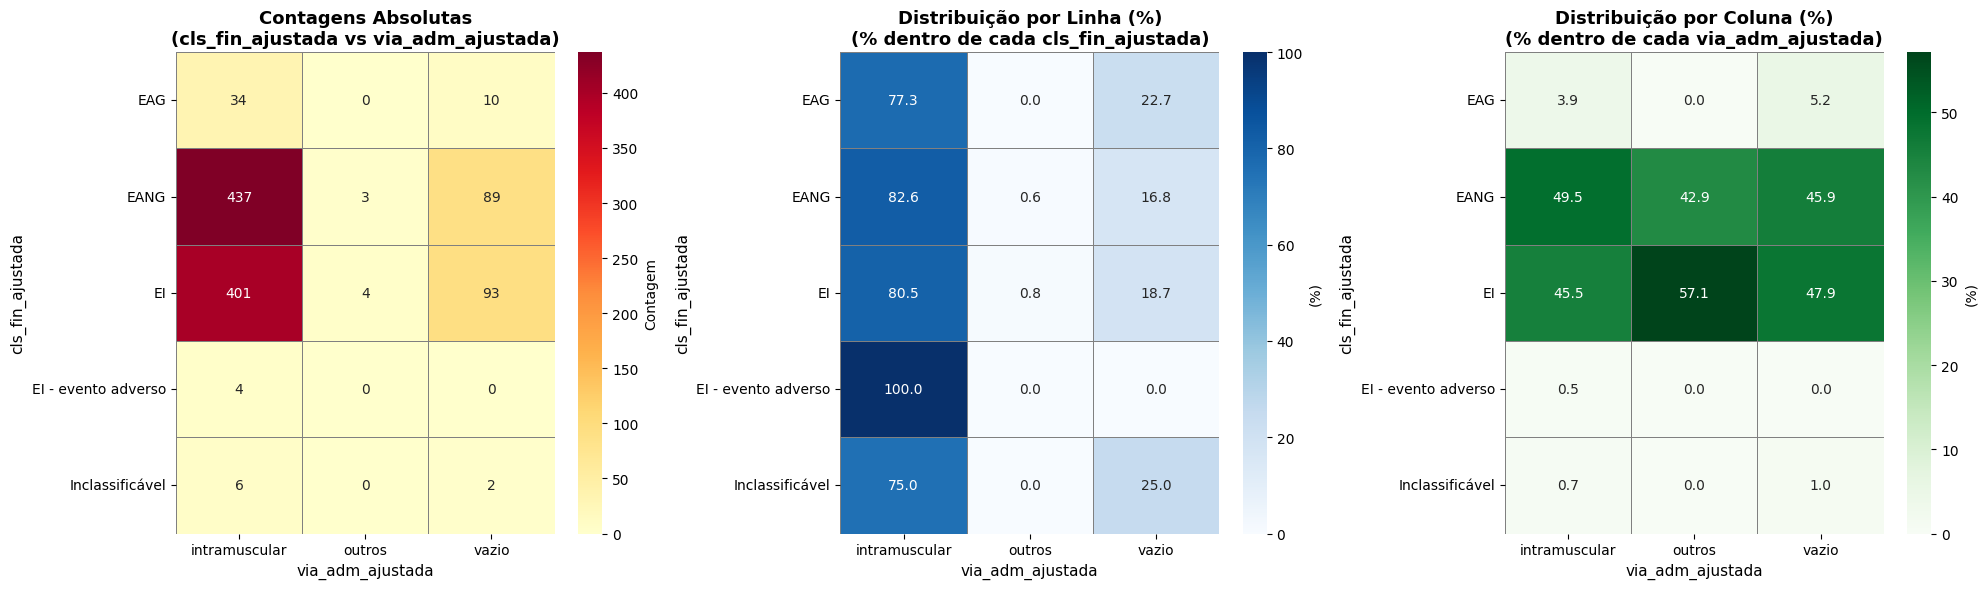


Gerando gráficos para: local_aplic_ajustada vs cls_fin_ajustada


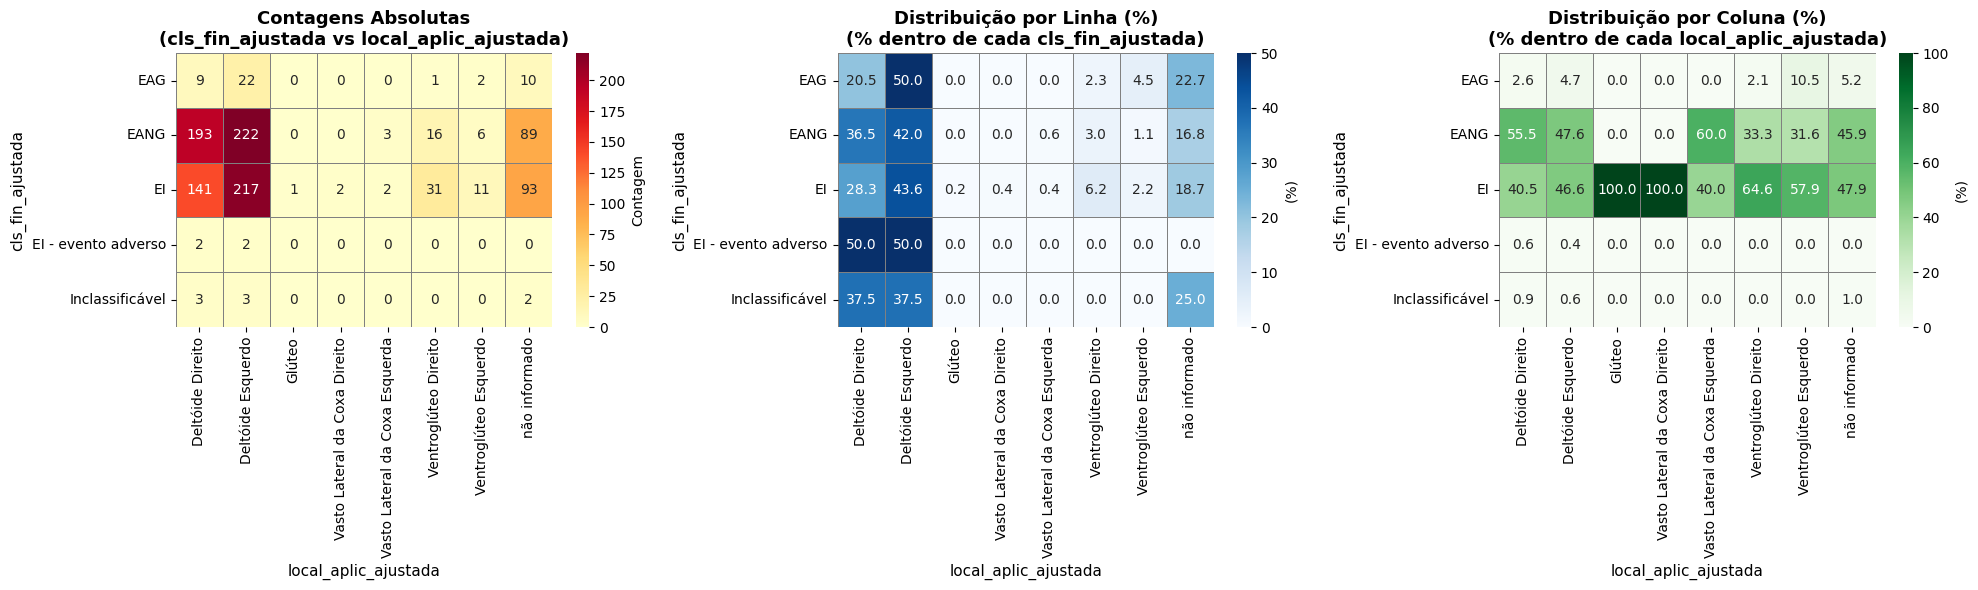


Gerando gráficos para: tp_med vs cls_fin_ajustada


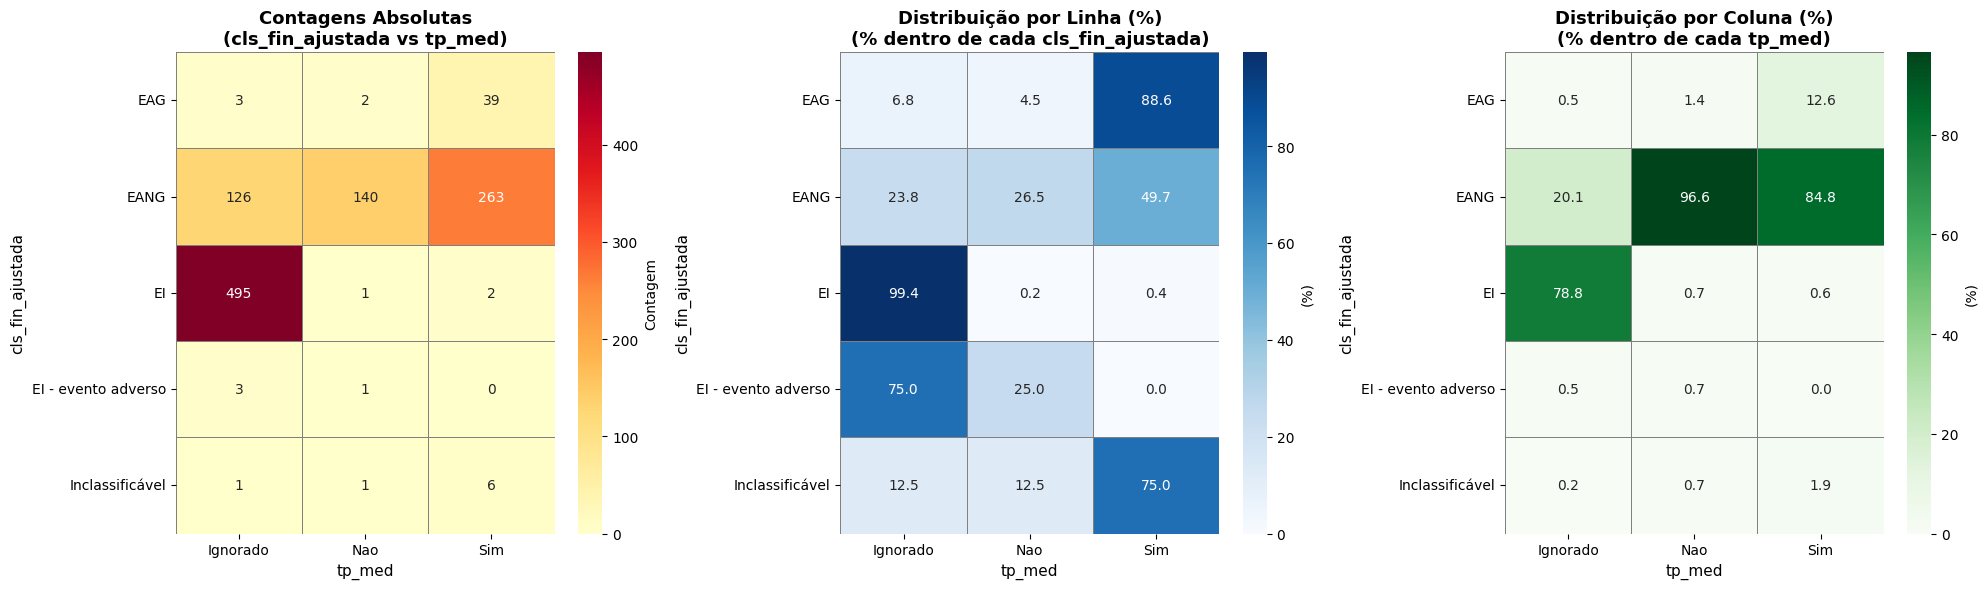


Gerando gráficos para: cls_ei_ajustada vs cls_fin_ajustada


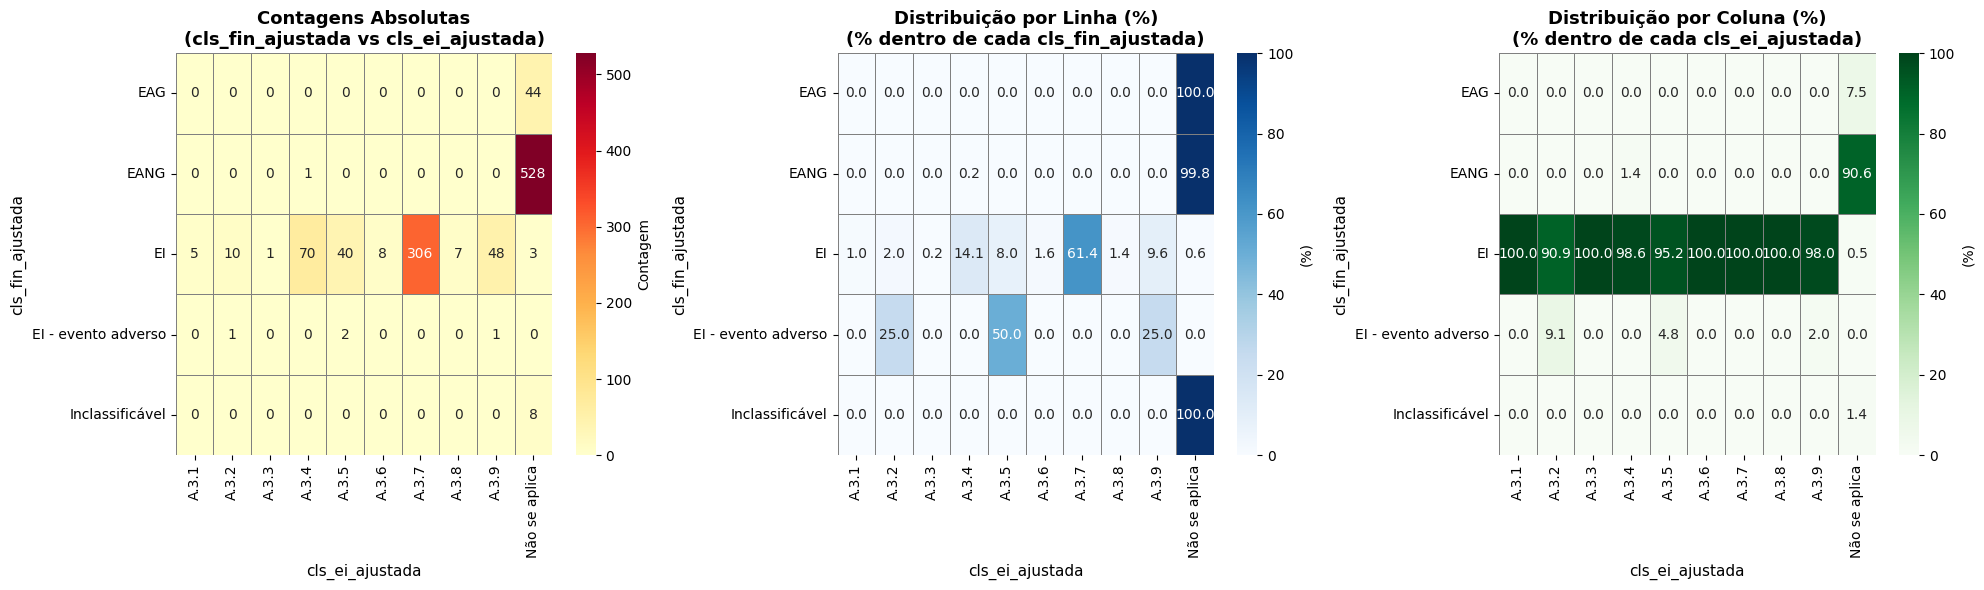


Gerando gráficos para: tp_atd_ajustada vs cls_fin_ajustada


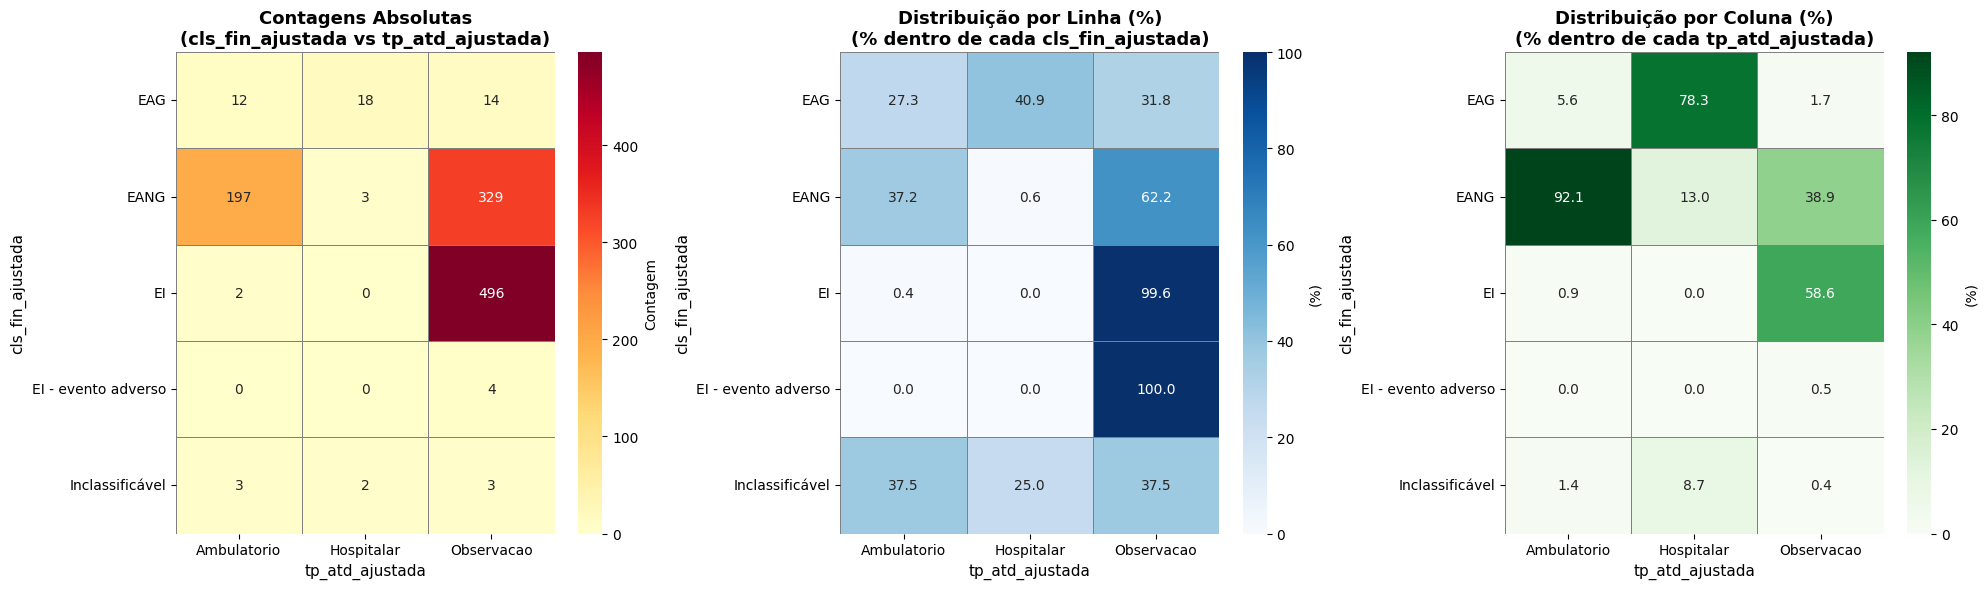


Gerando gráficos para: cls_eien vs cls_fin_ajustada


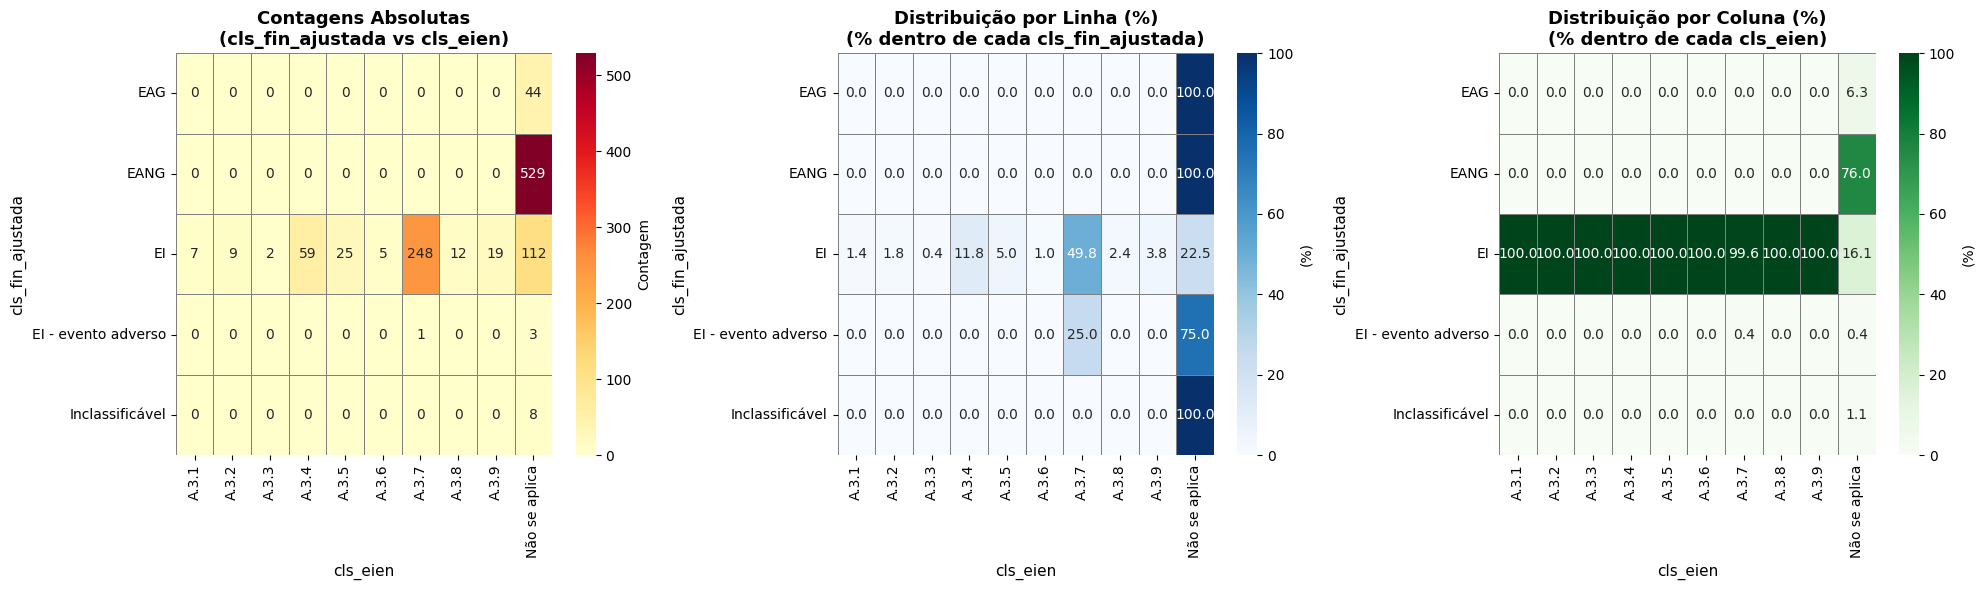


Gerando gráficos para: idade_anos vs cls_fin_ajustada


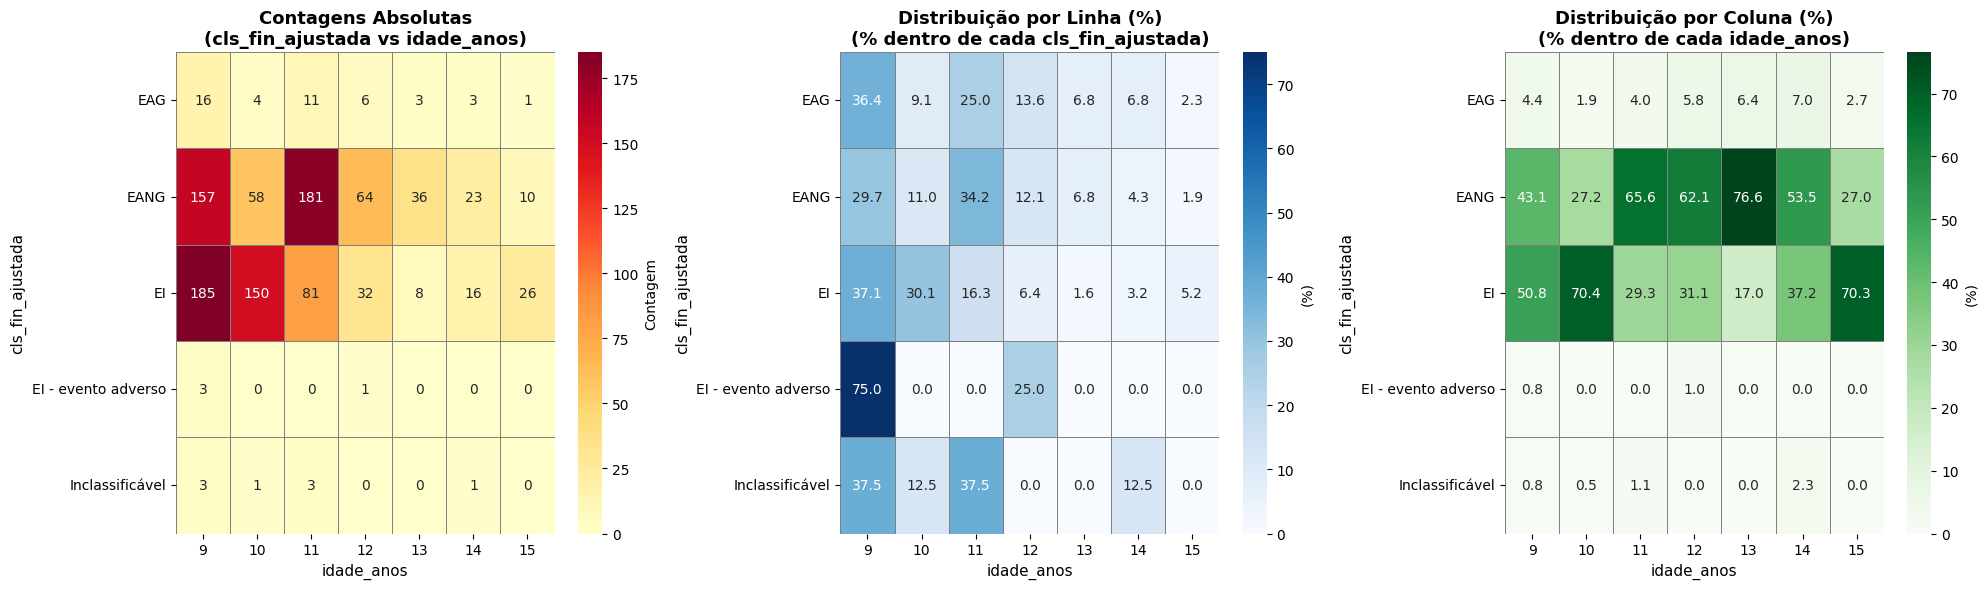


Gerando gráficos para: evol_num vs cls_fin_ajustada


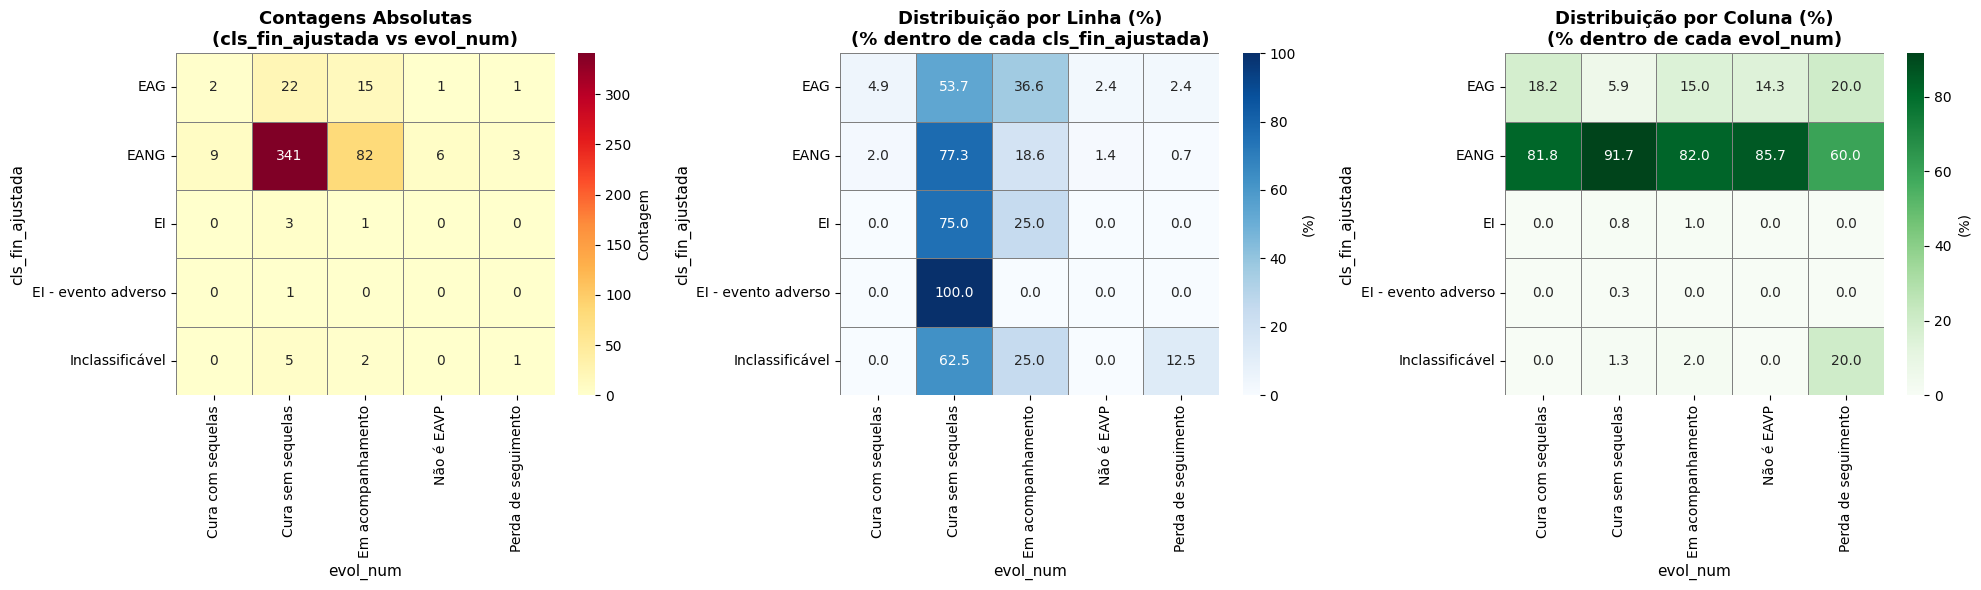


Gerando gráficos para: dor_abdominal vs cls_fin_ajustada


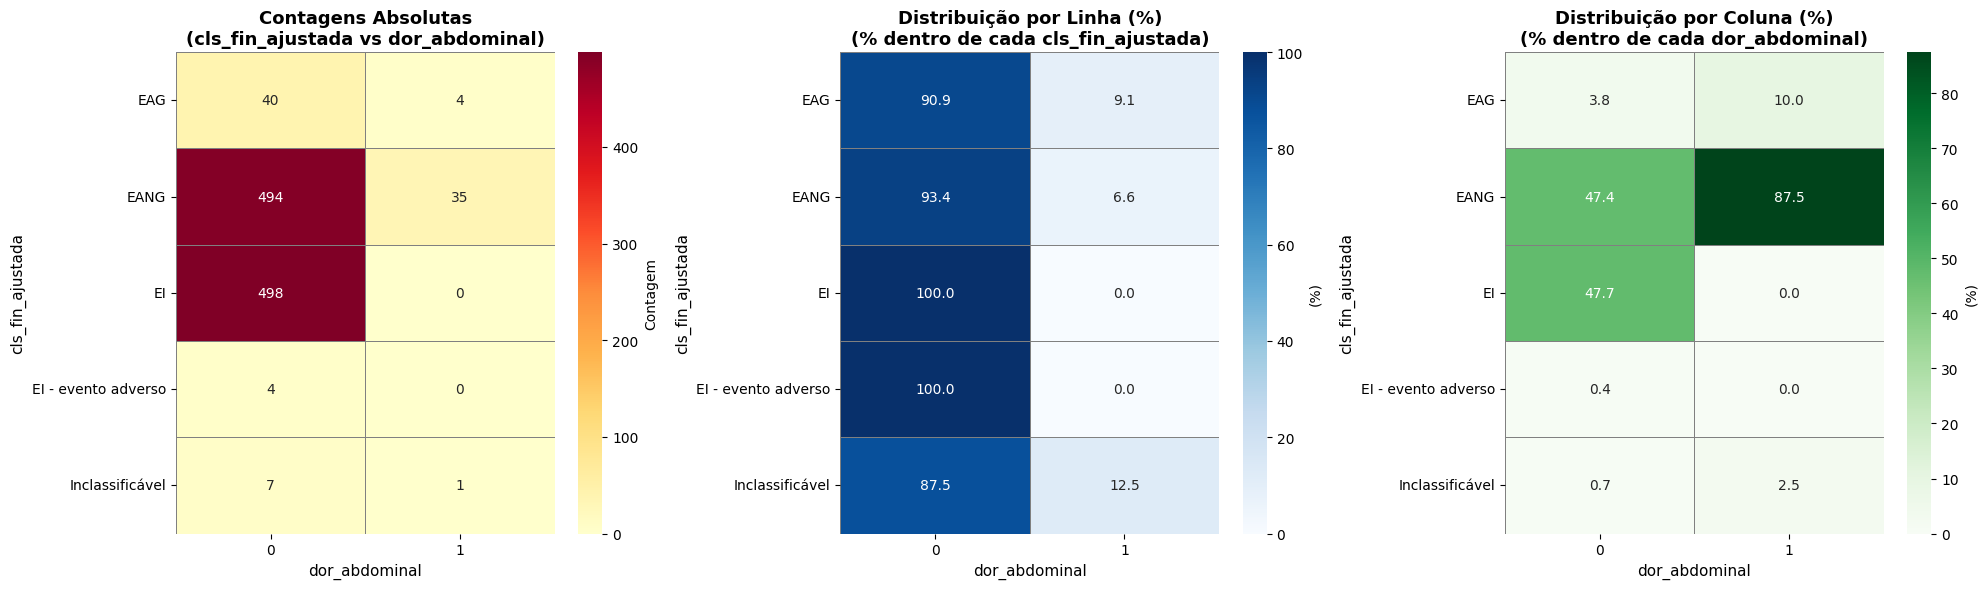


Gerando gráficos para: dor_no_corpo vs cls_fin_ajustada


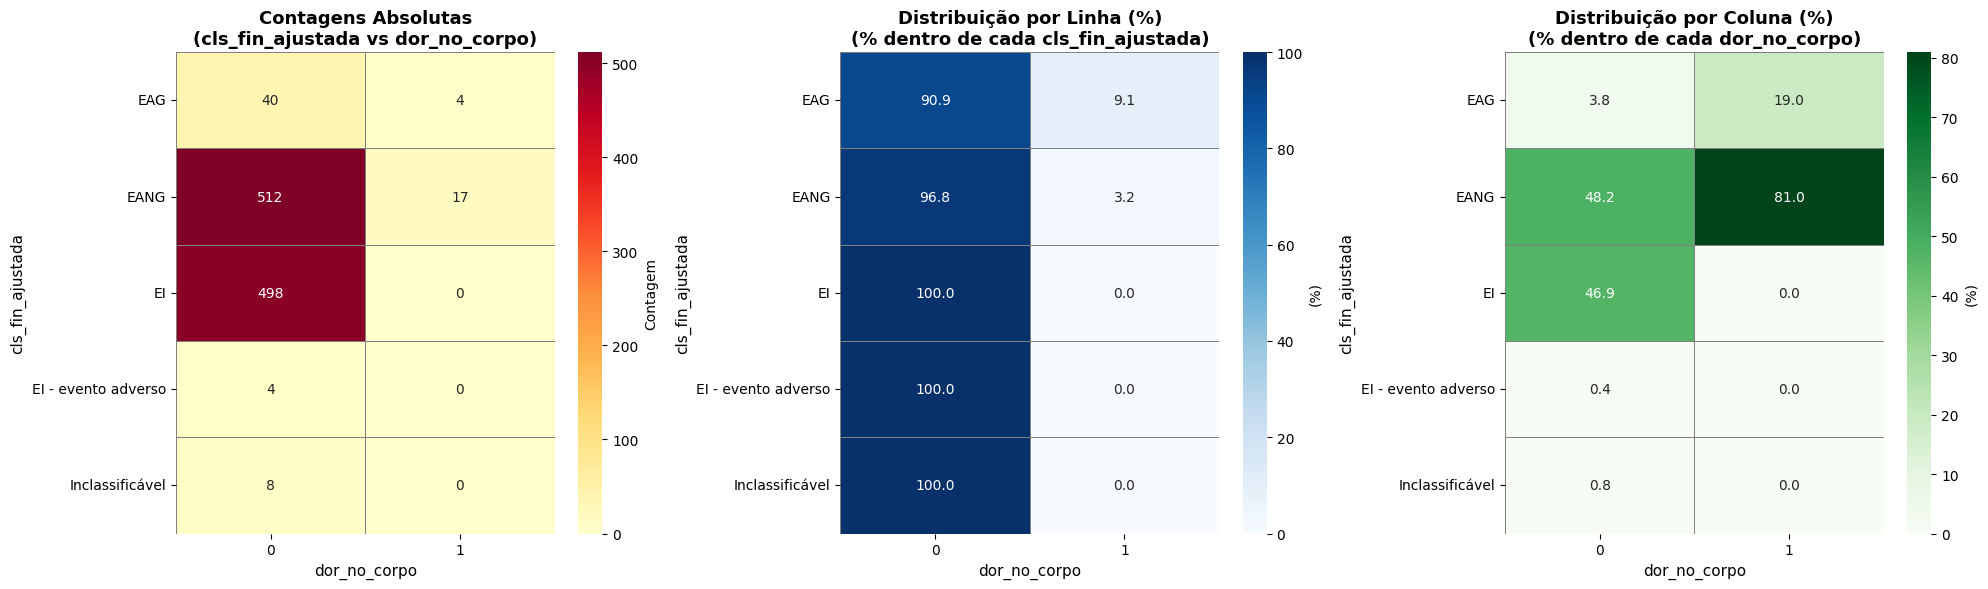


Gerando gráficos para: artralgia vs cls_fin_ajustada


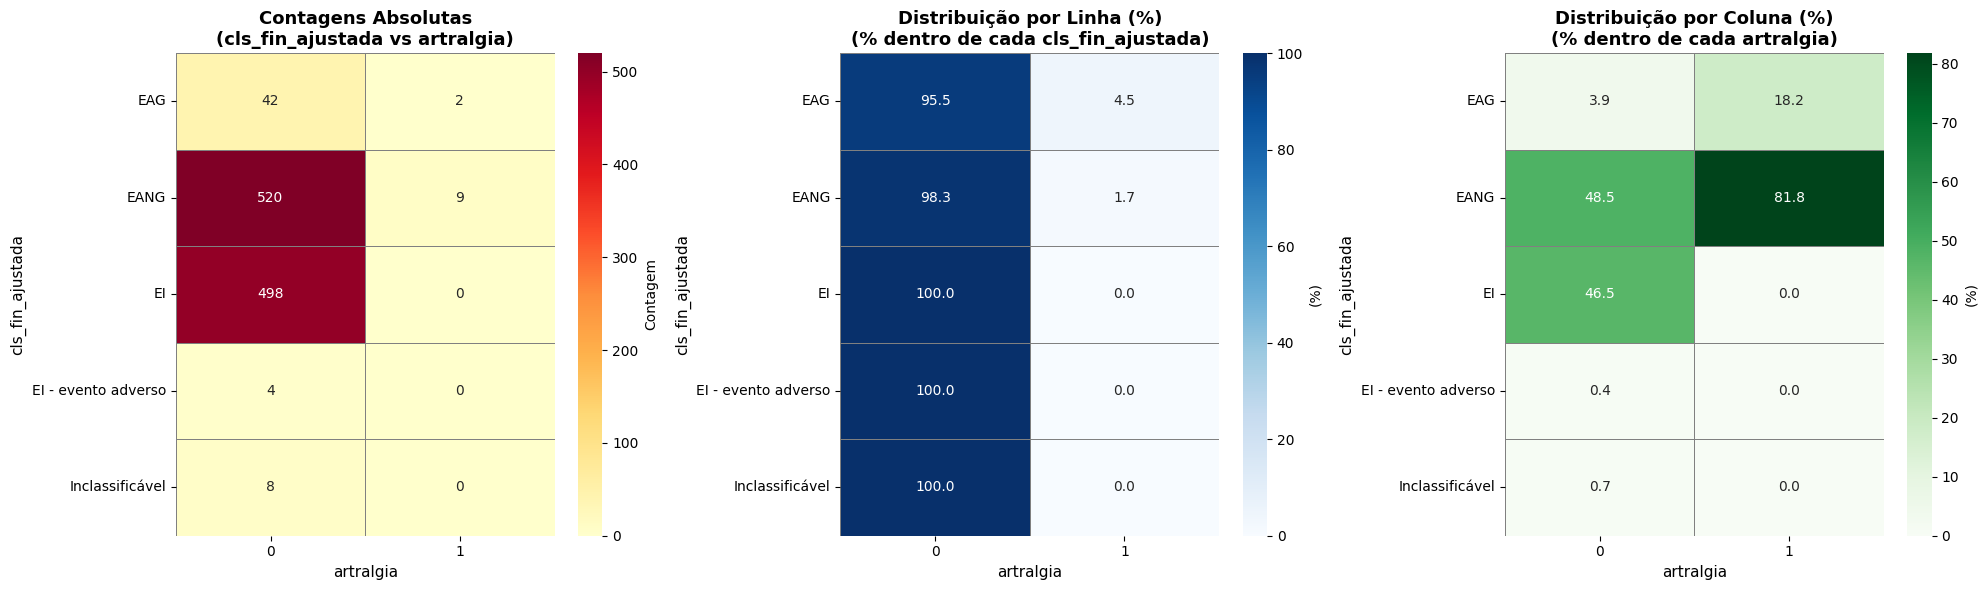


Gerando gráficos para: cefaleia vs cls_fin_ajustada


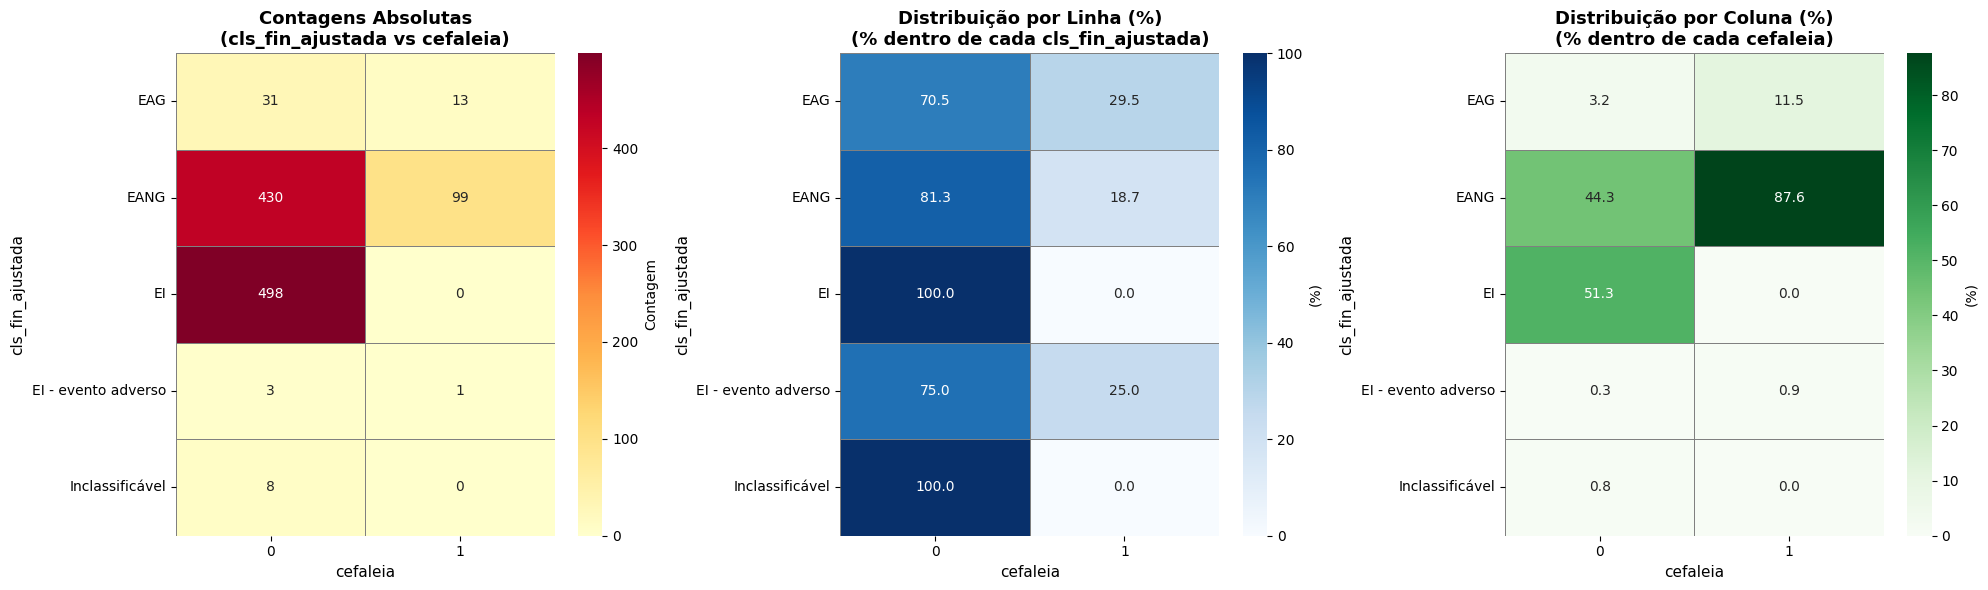


Gerando gráficos para: dor vs cls_fin_ajustada


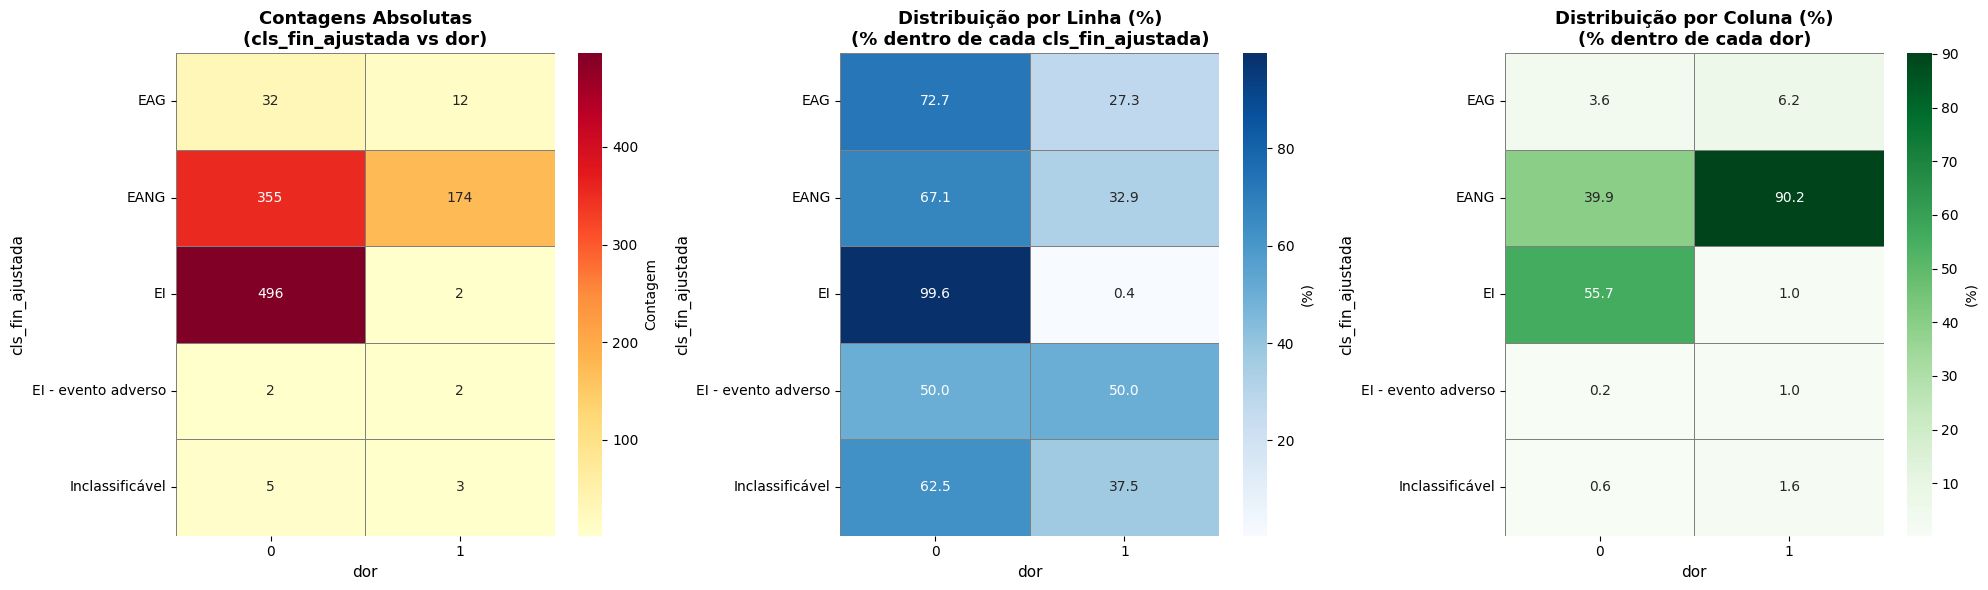


Gerando gráficos para: exantema_local vs cls_fin_ajustada


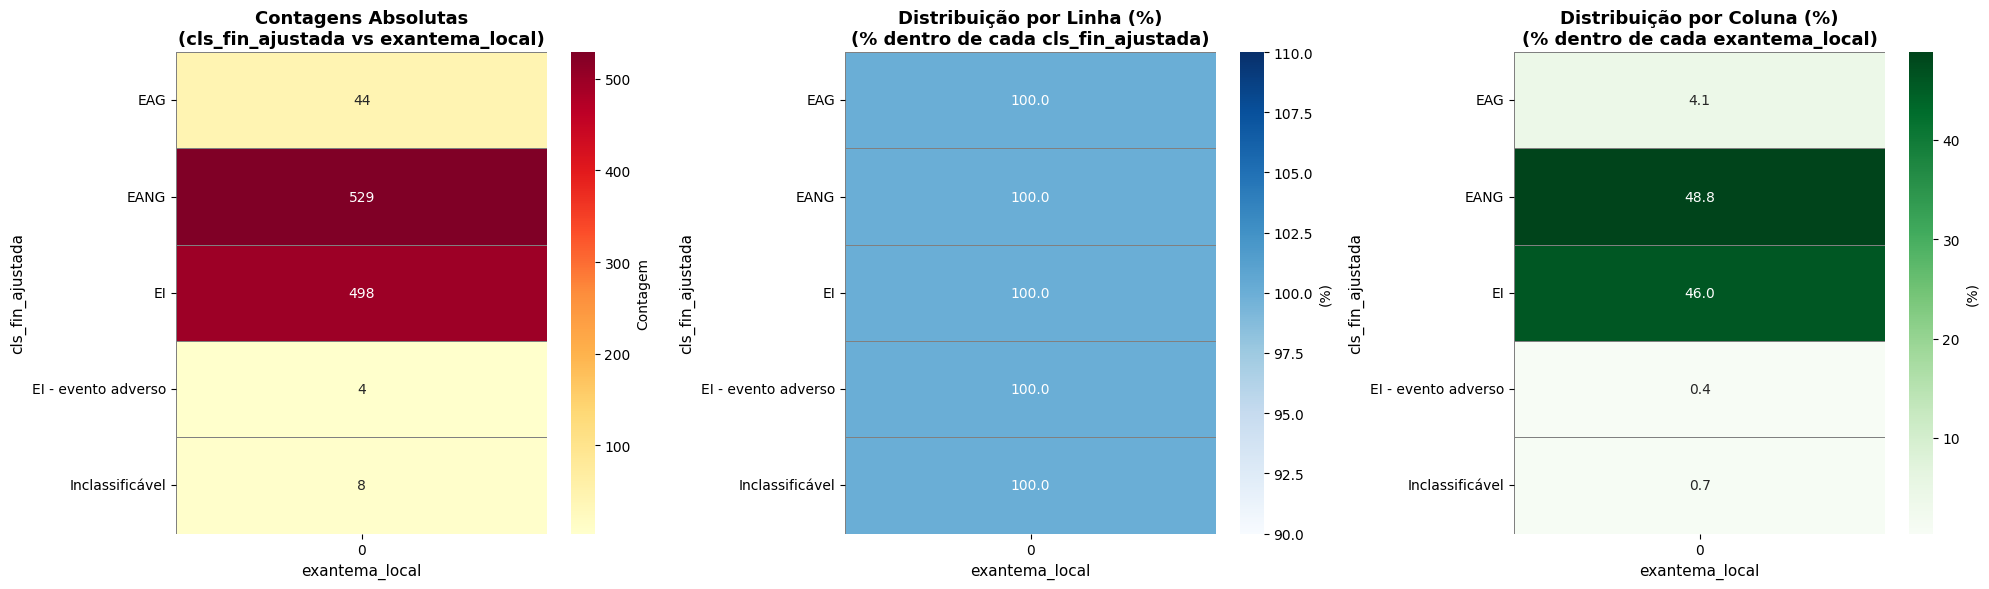


Gerando gráficos para: exantema vs cls_fin_ajustada


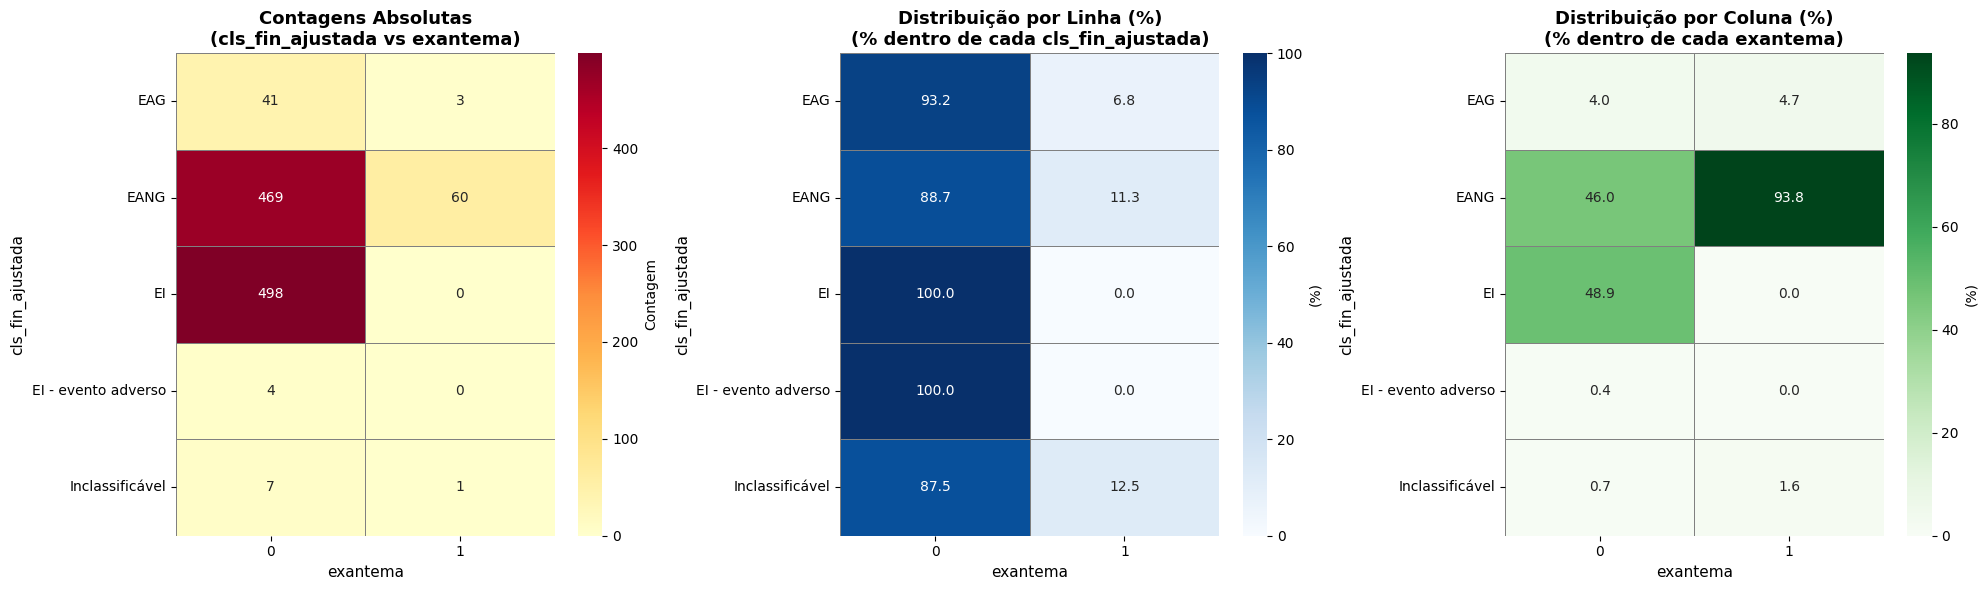


Gerando gráficos para: edema vs cls_fin_ajustada


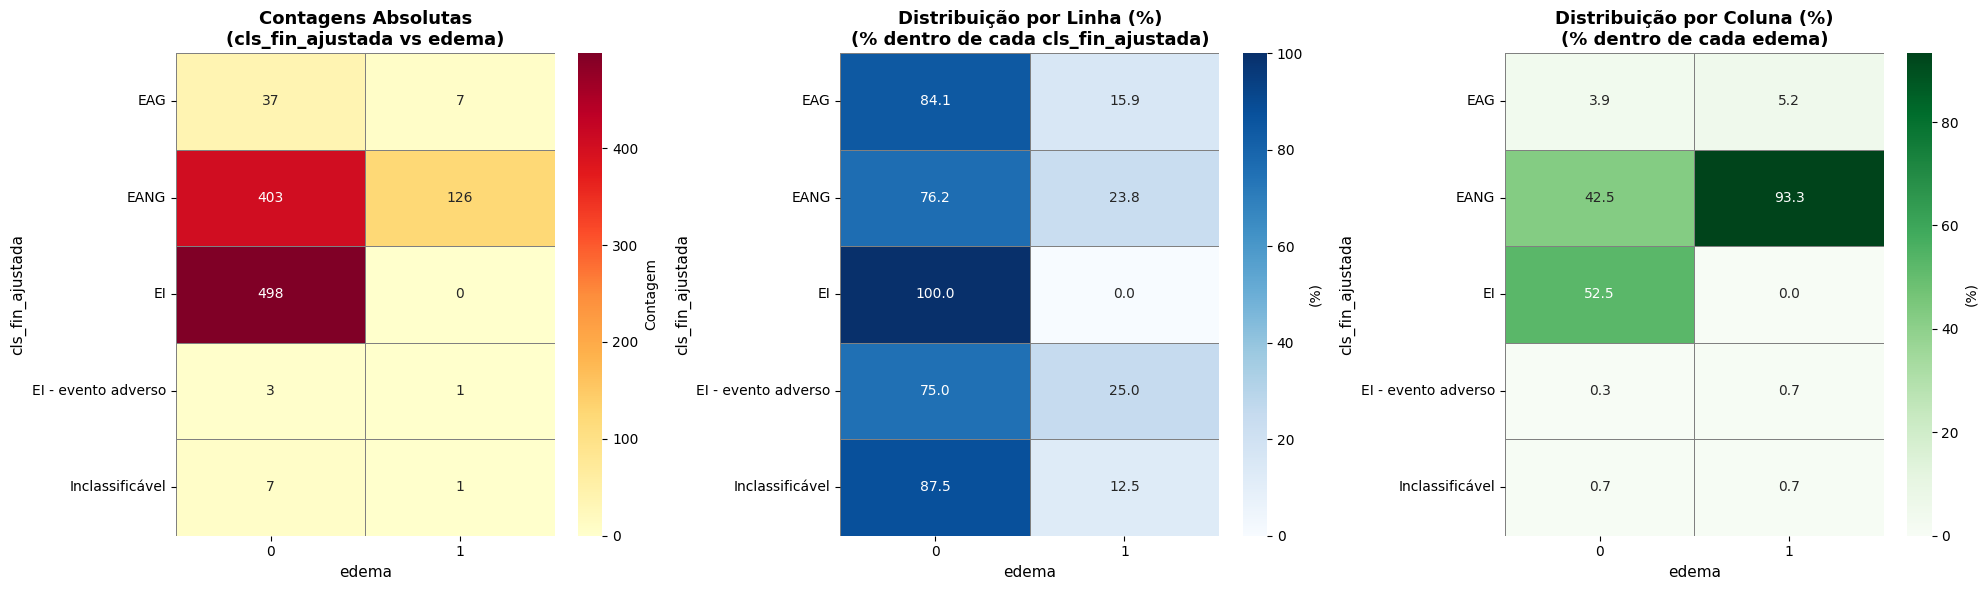


Gerando gráficos para: eritema vs cls_fin_ajustada


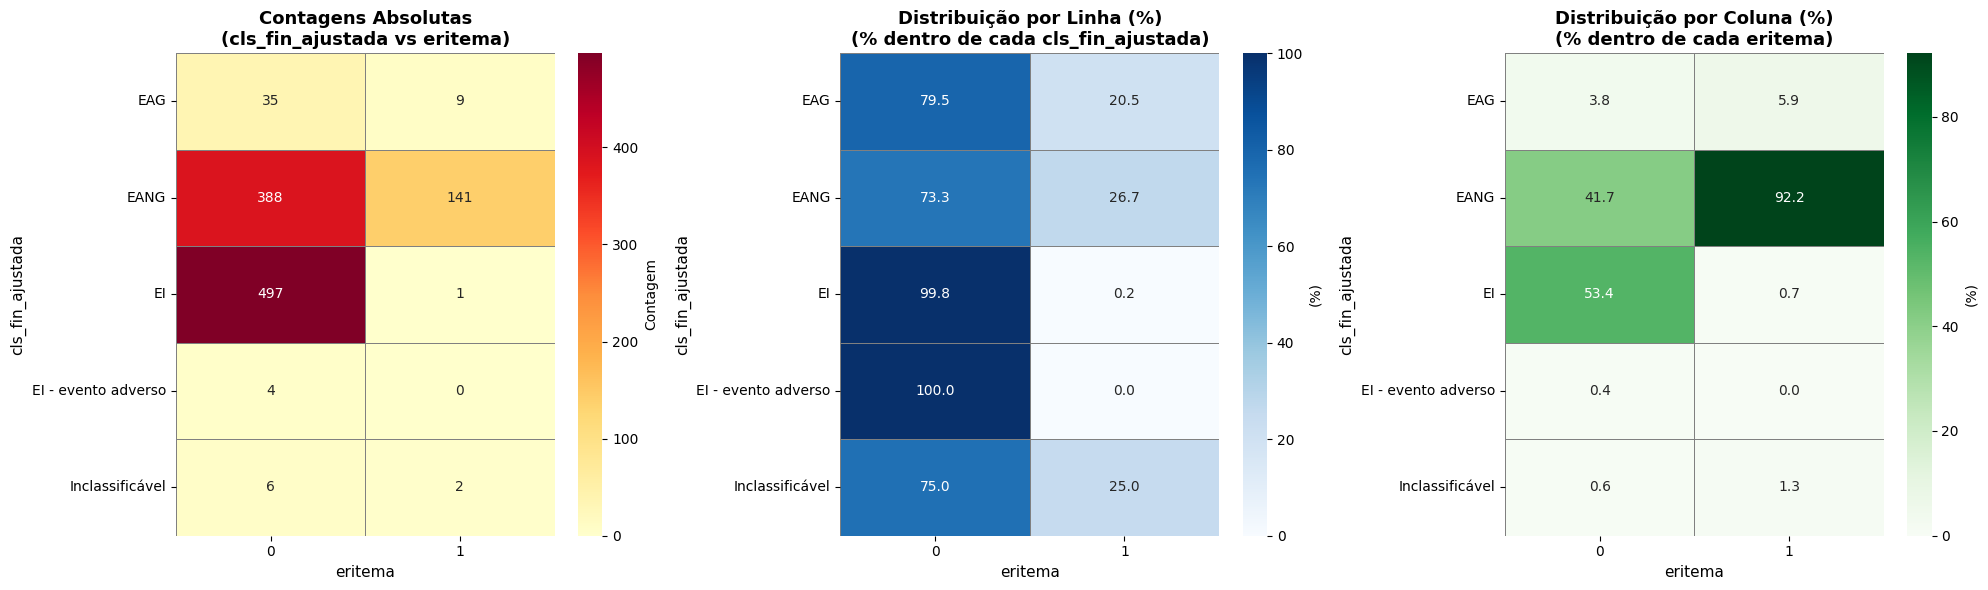


Gerando gráficos para: calor vs cls_fin_ajustada


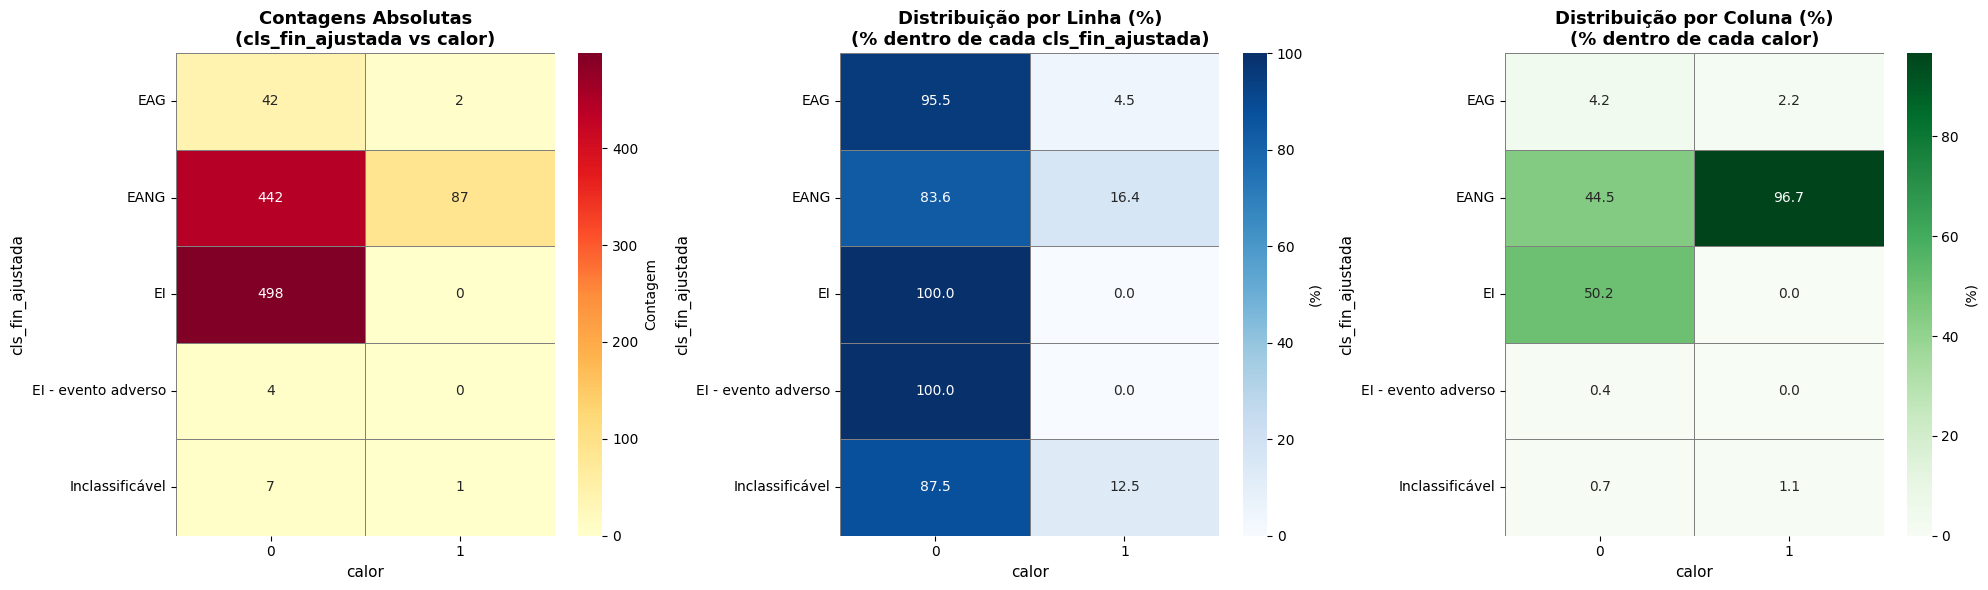


Gerando gráficos para: enduracao vs cls_fin_ajustada


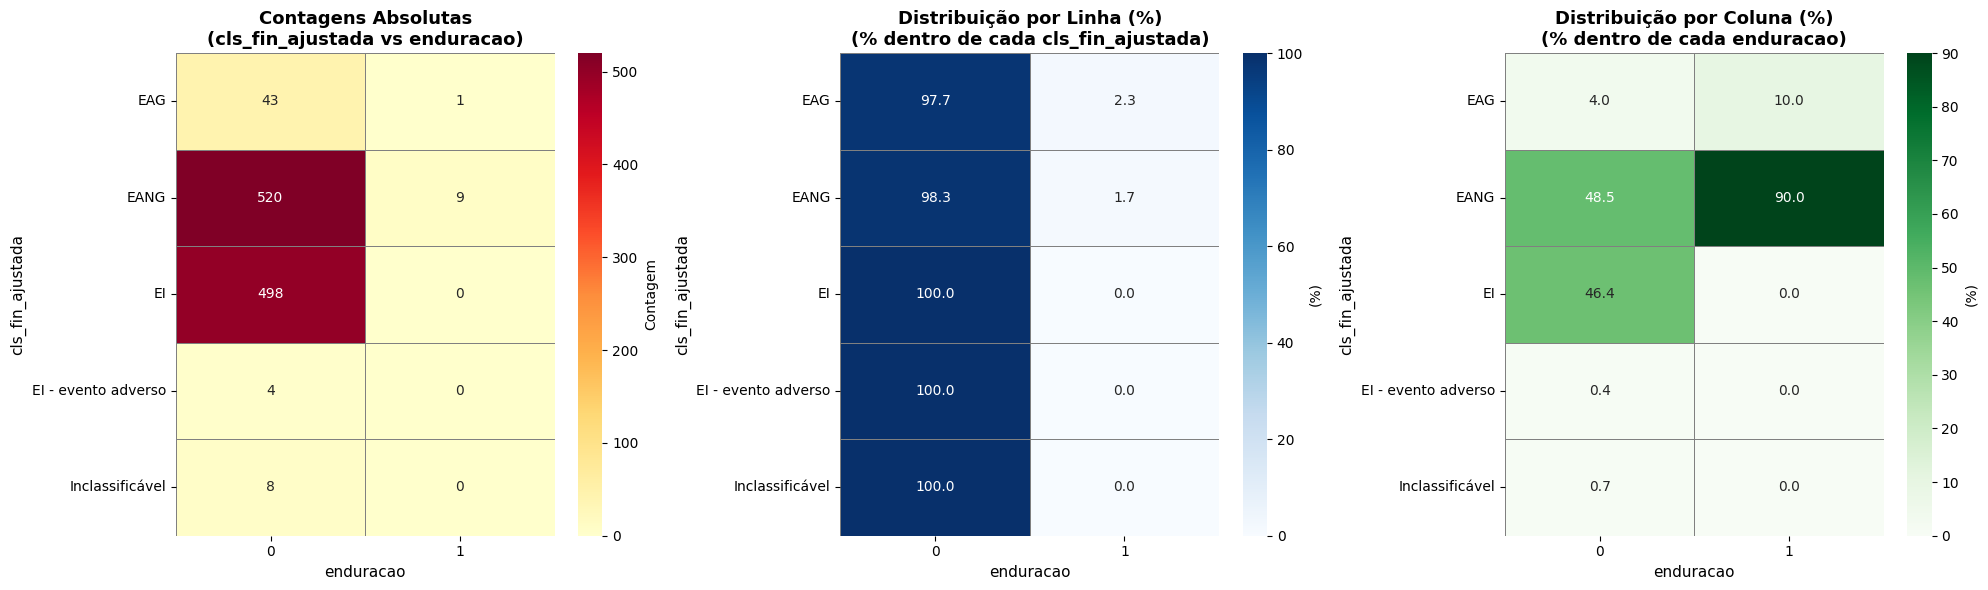


Gerando gráficos para: abscesso_quente vs cls_fin_ajustada


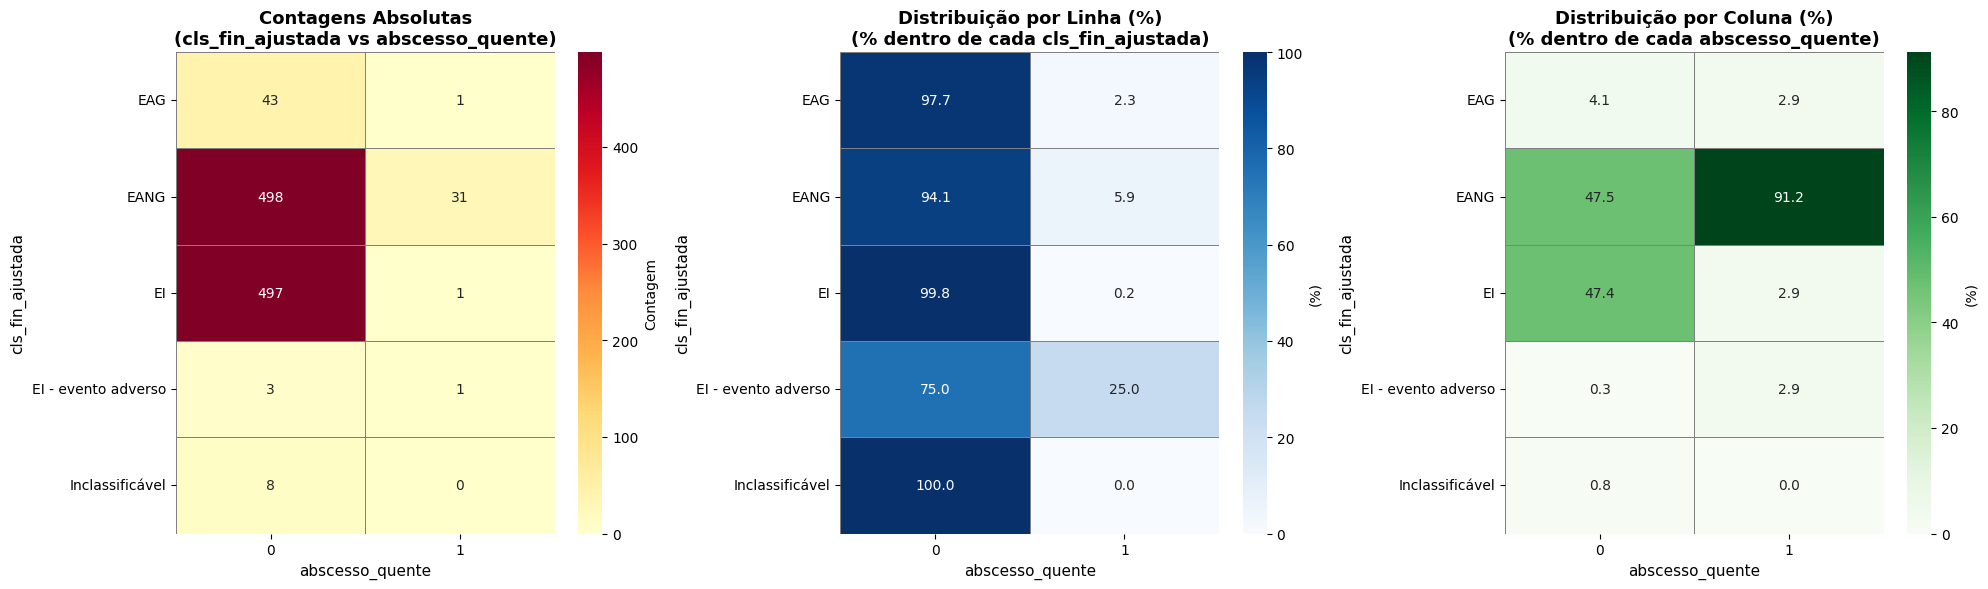


Gerando gráficos para: lesao vs cls_fin_ajustada


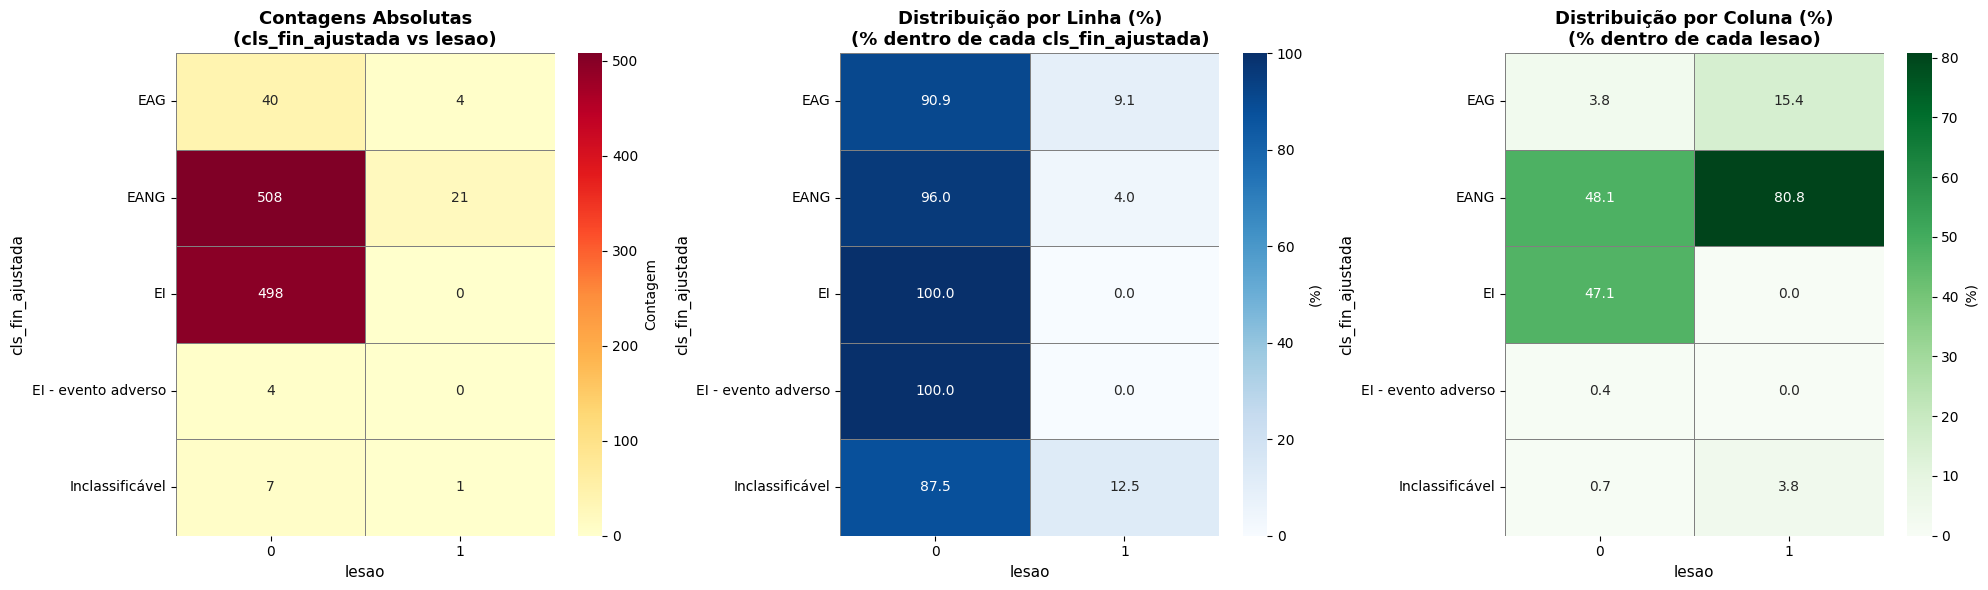


Gerando gráficos para: linfonodomegalia vs cls_fin_ajustada


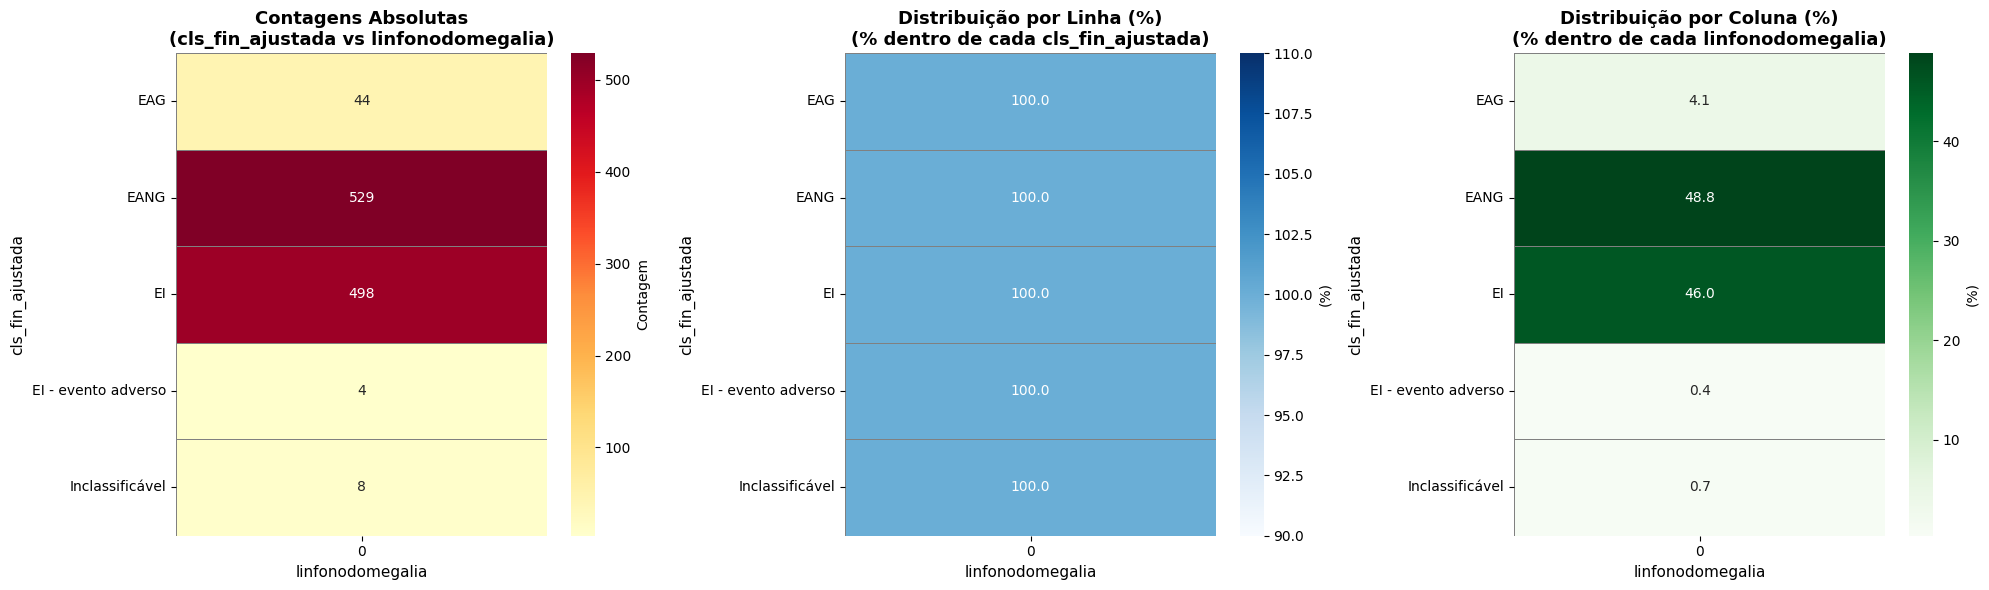


Gerando gráficos para: prurido vs cls_fin_ajustada


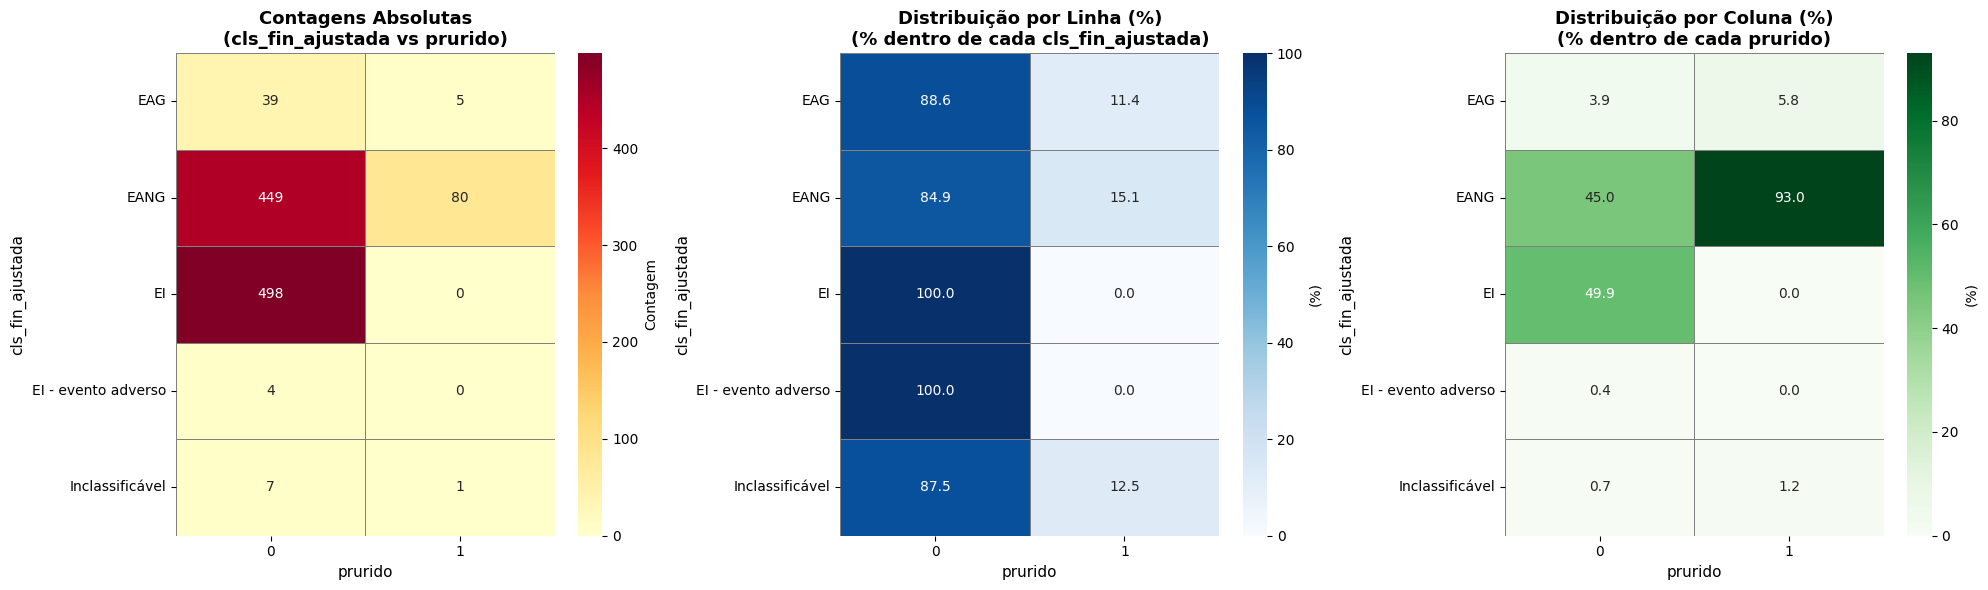


Gerando gráficos para: febre vs cls_fin_ajustada


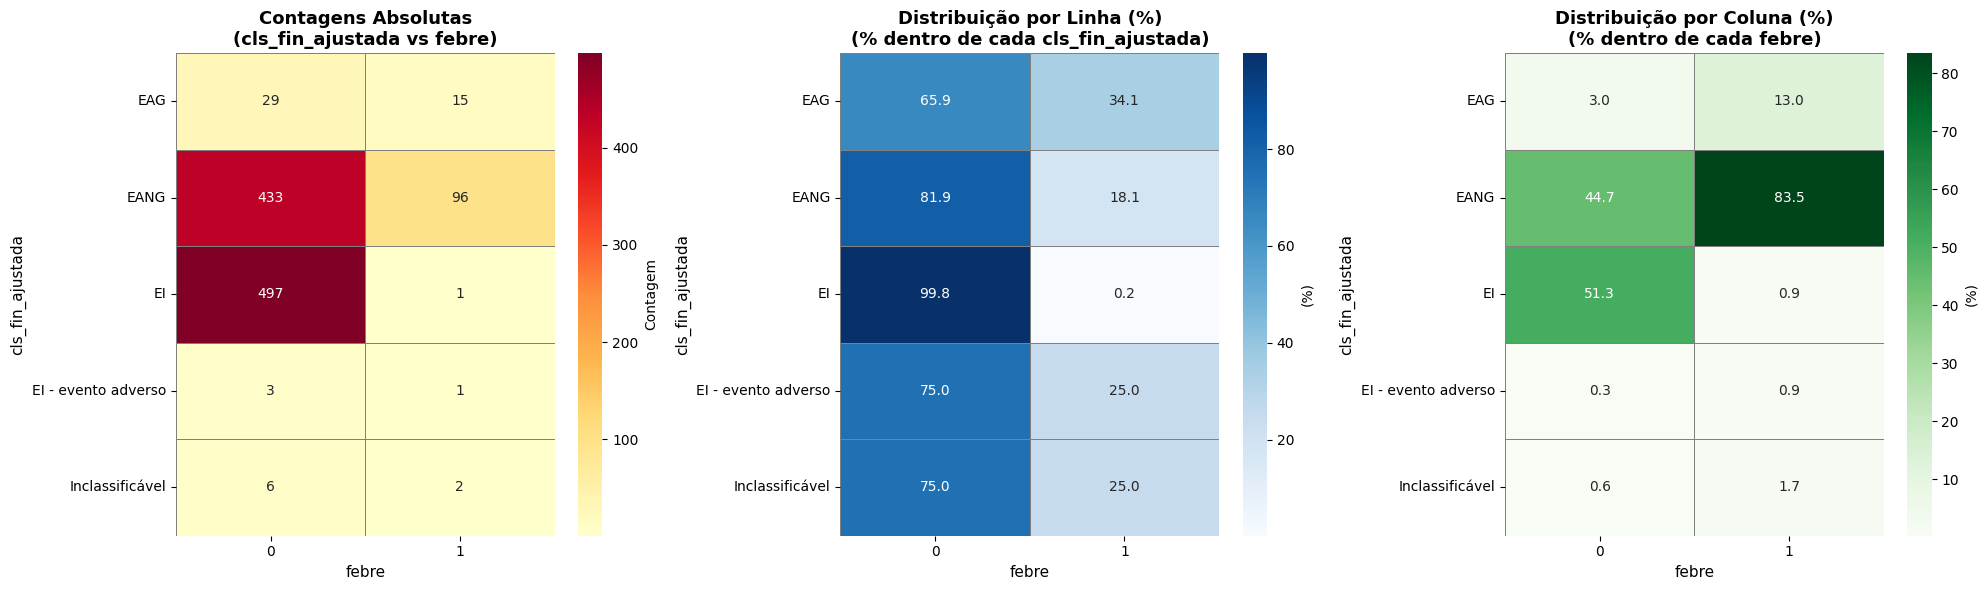


Gerando gráficos para: nausea vs cls_fin_ajustada


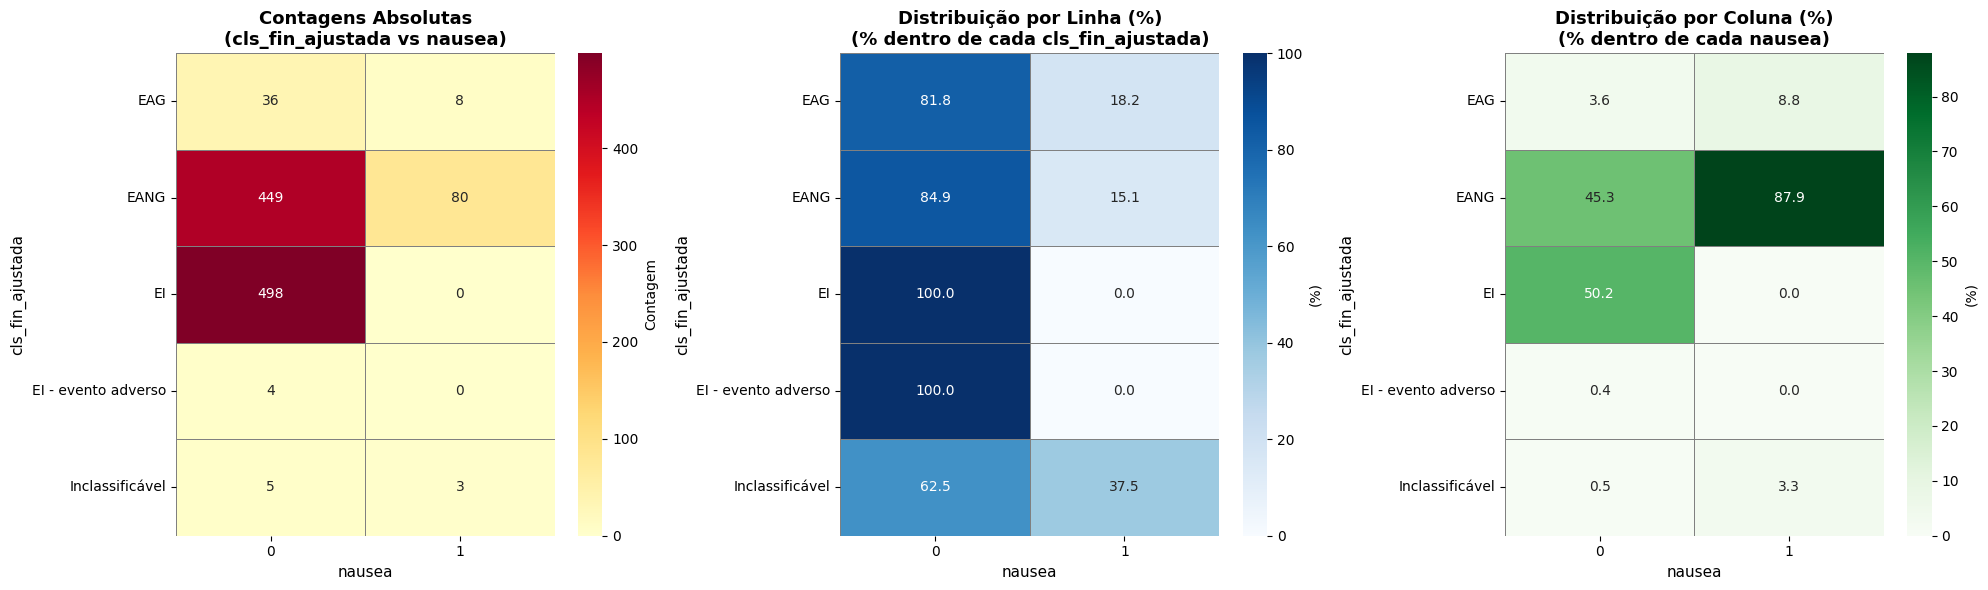


Gerando gráficos para: emese vs cls_fin_ajustada


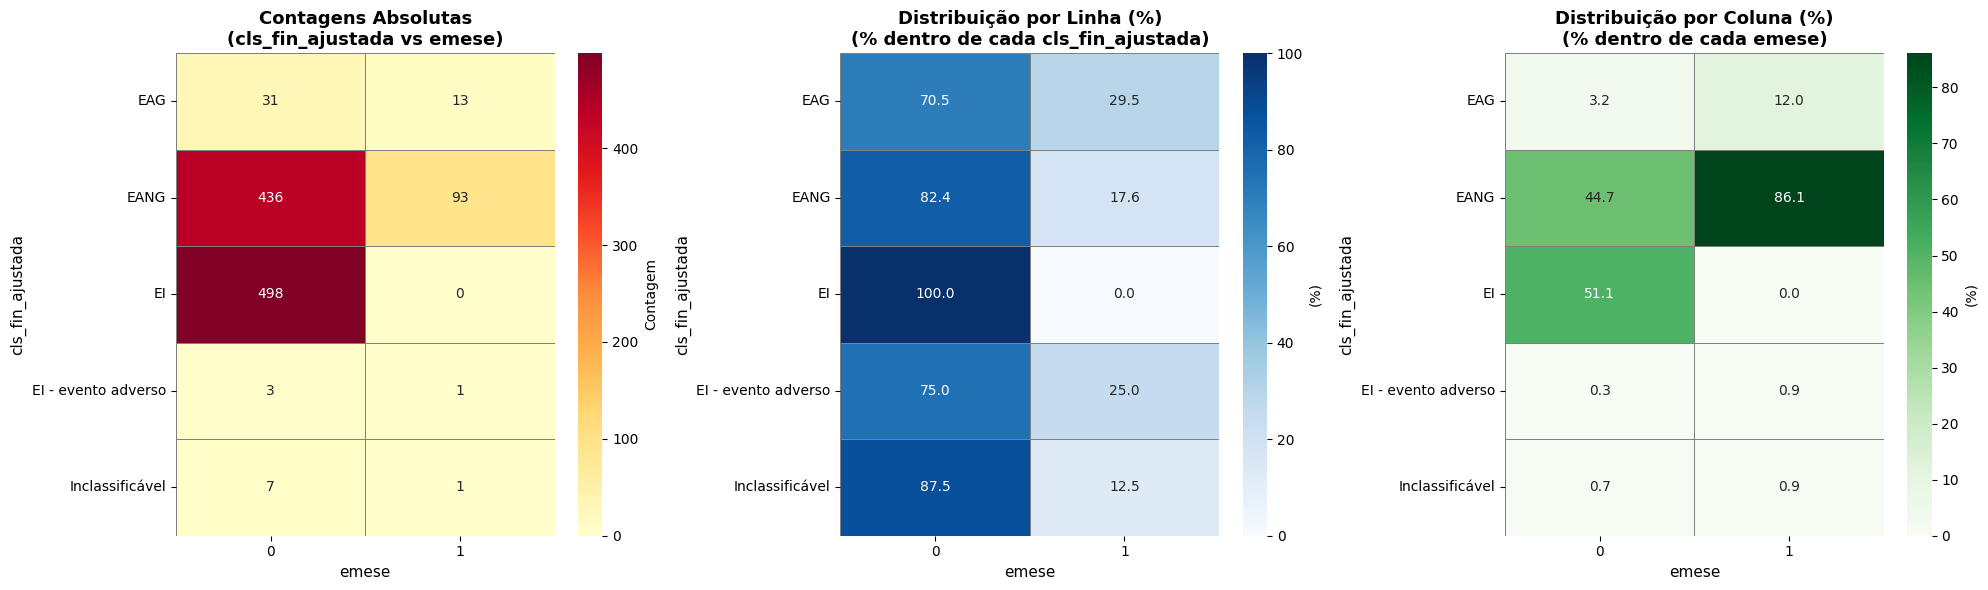


Gerando gráficos para: diarreia vs cls_fin_ajustada


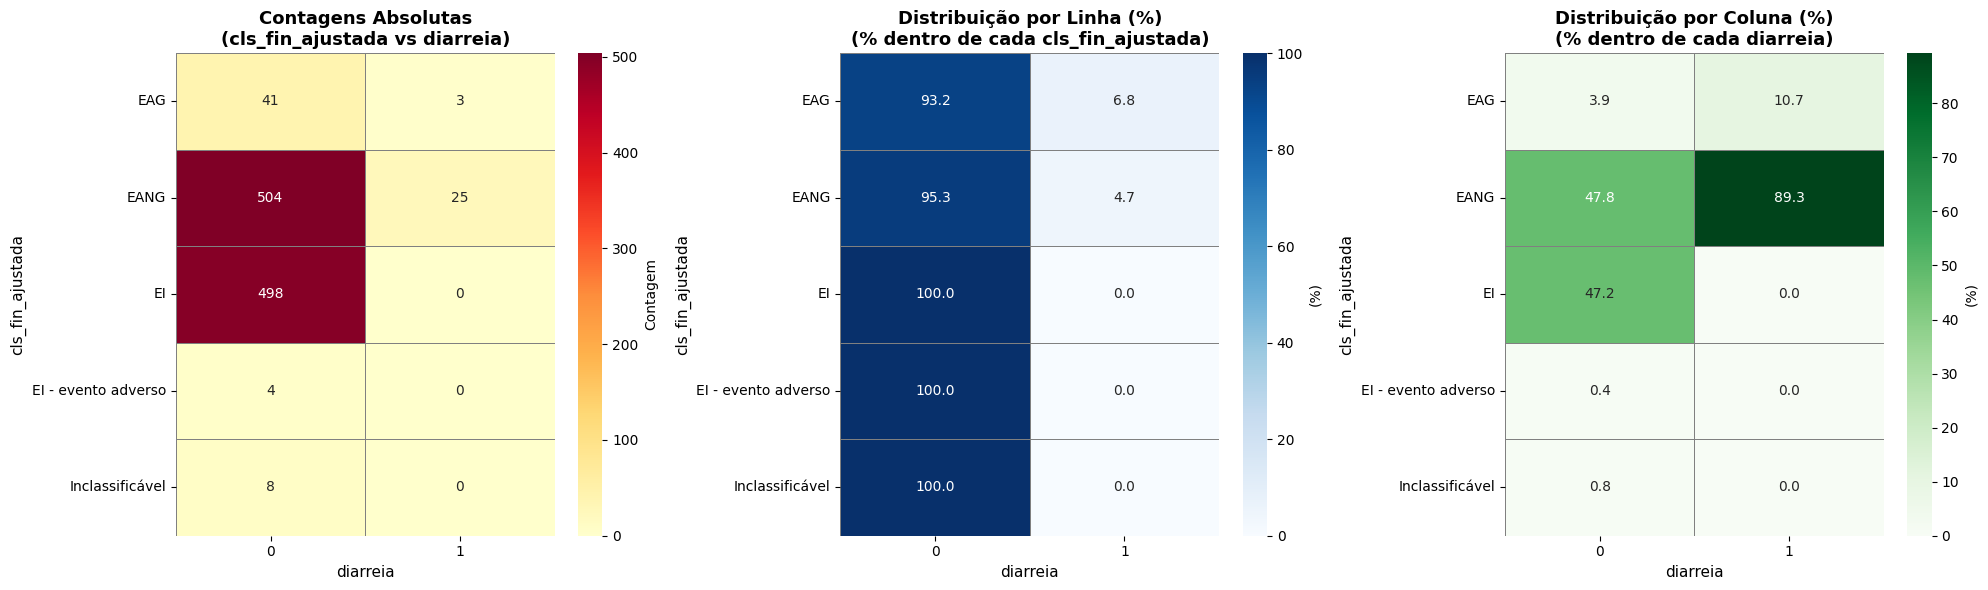


Gerando gráficos para: tontura vs cls_fin_ajustada


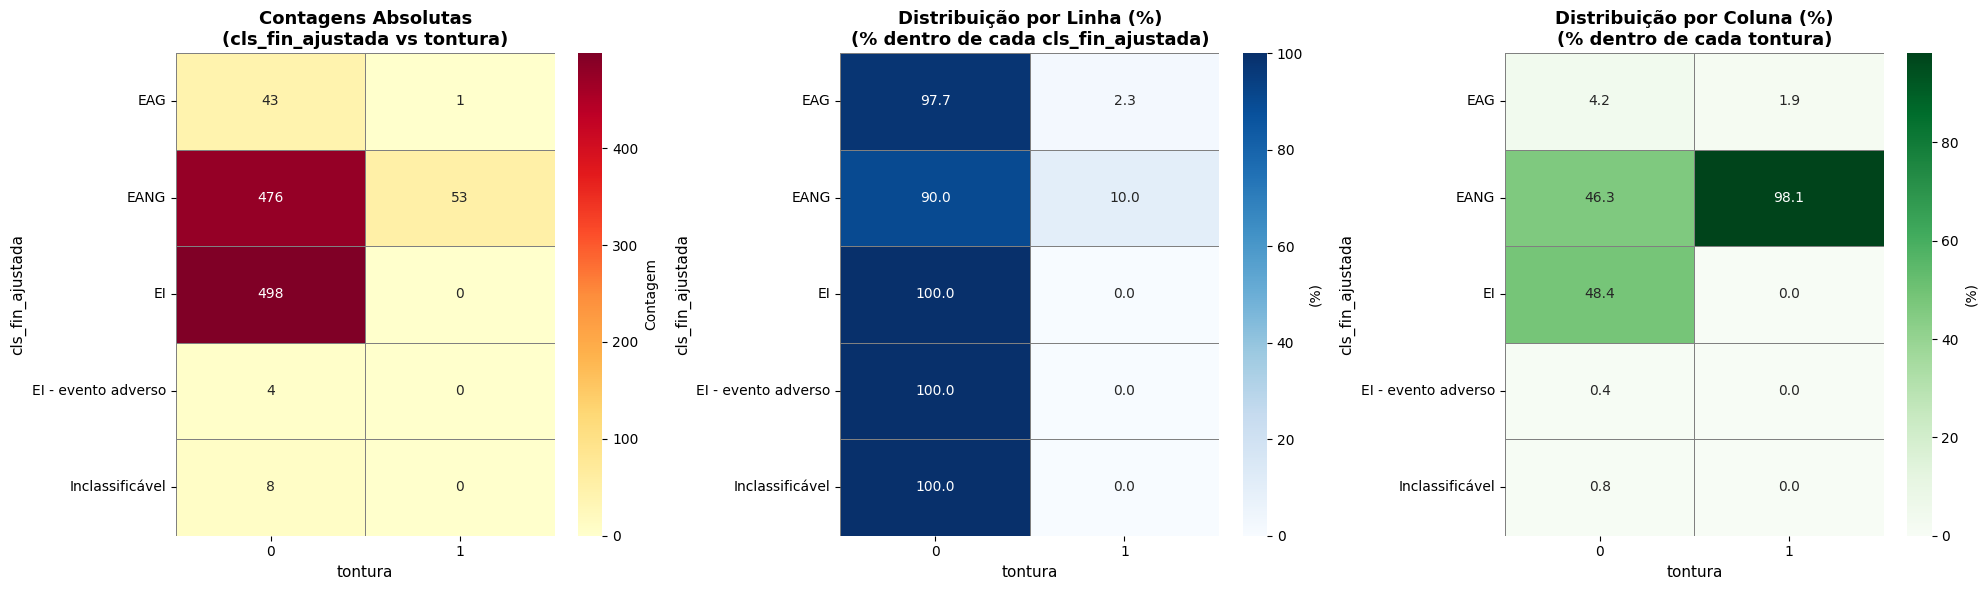


Gerando gráficos para: sincope vs cls_fin_ajustada


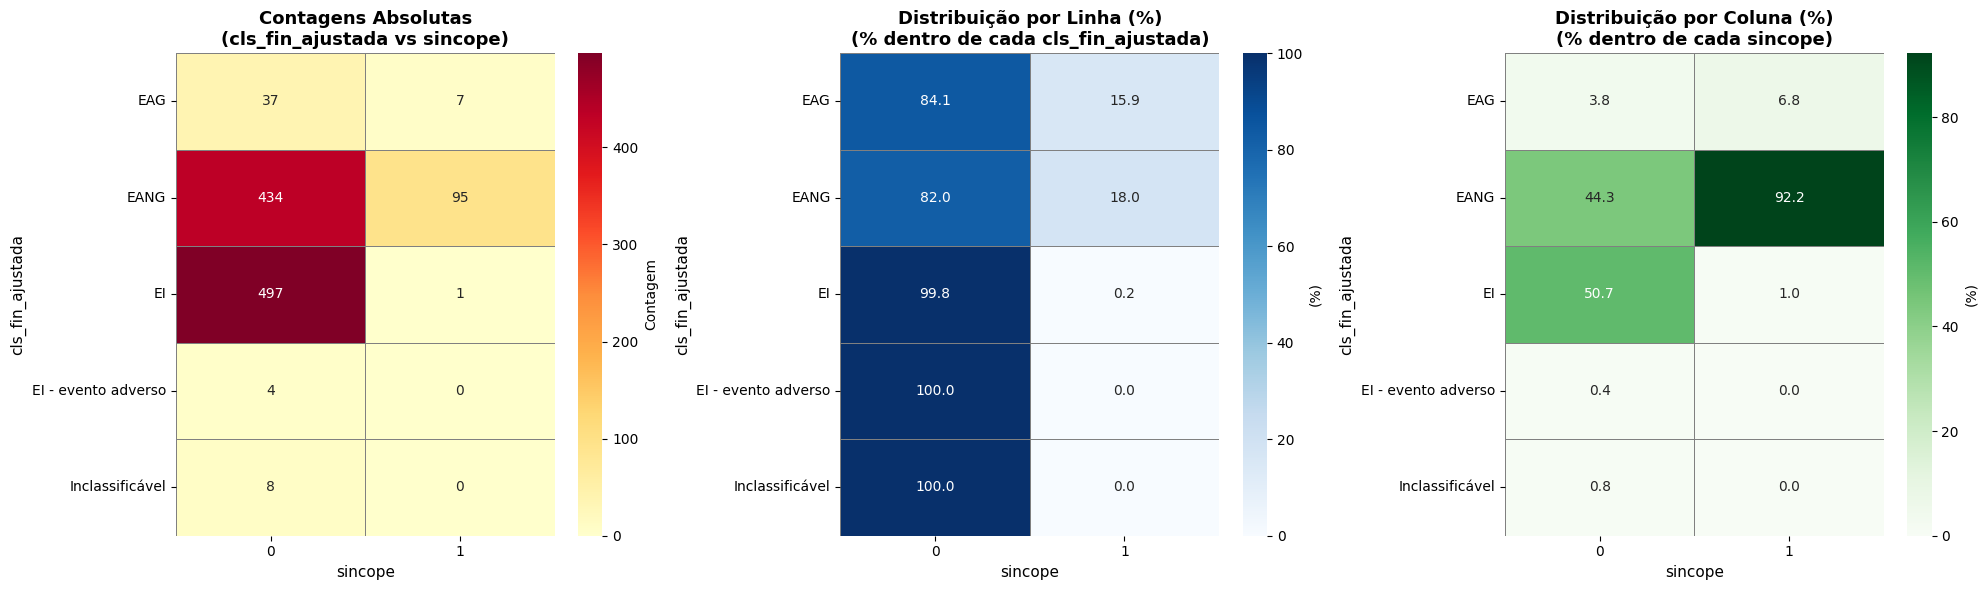


Gerando gráficos para: parestesia vs cls_fin_ajustada


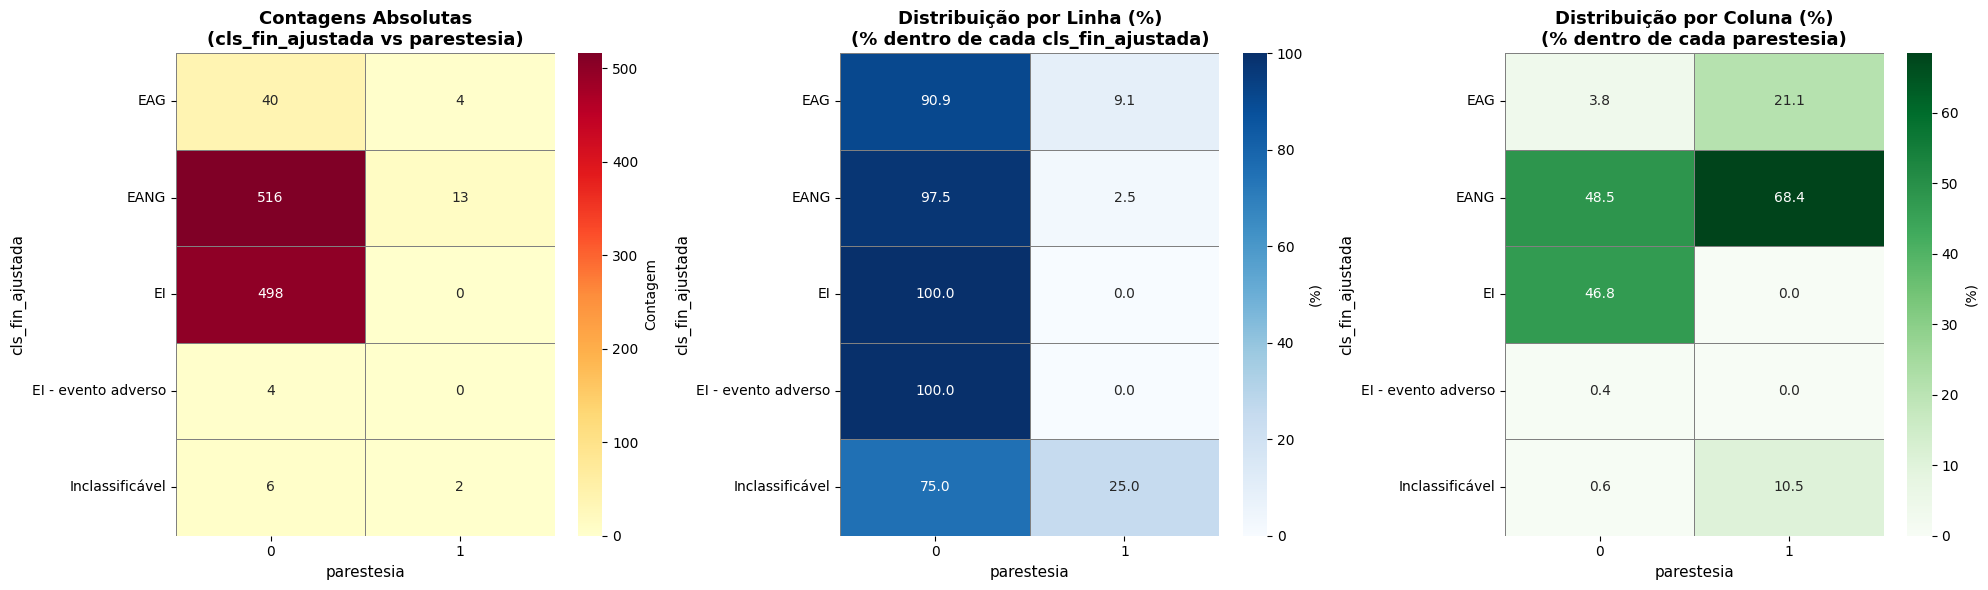


Gerando gráficos para: convulsao vs cls_fin_ajustada


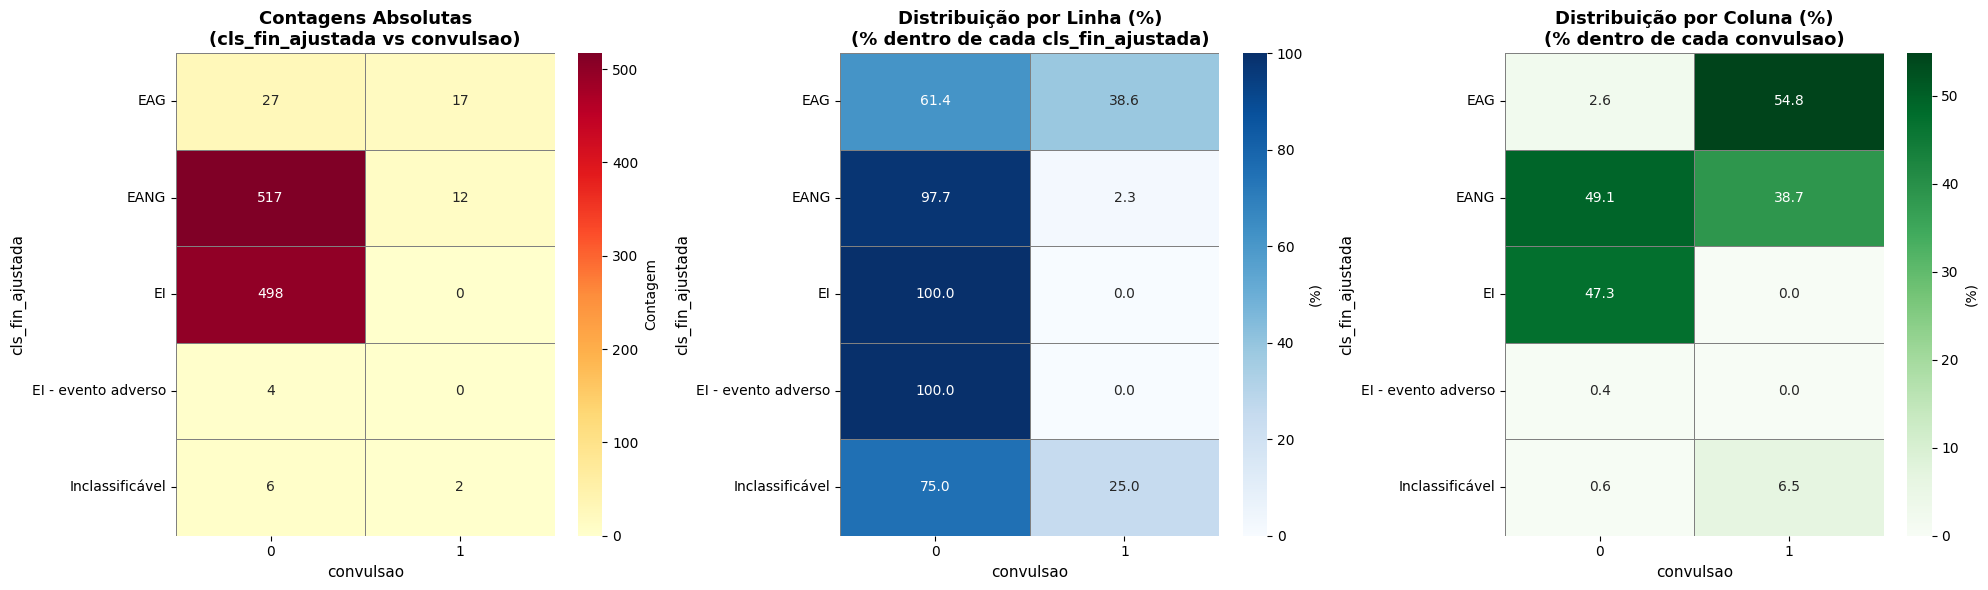


Gerando gráficos para: confusao_mental vs cls_fin_ajustada


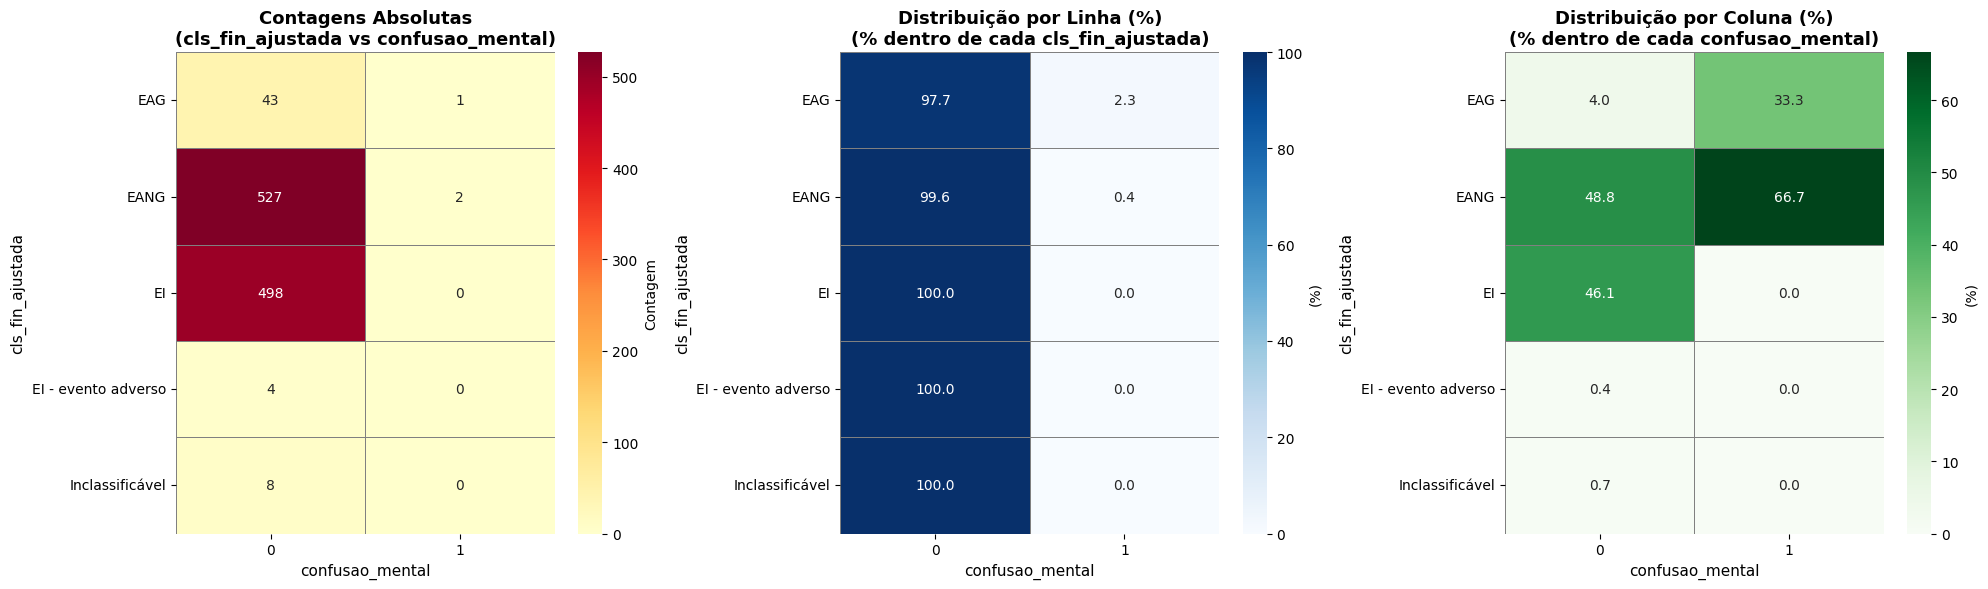


Gerando gráficos para: fraqueza vs cls_fin_ajustada


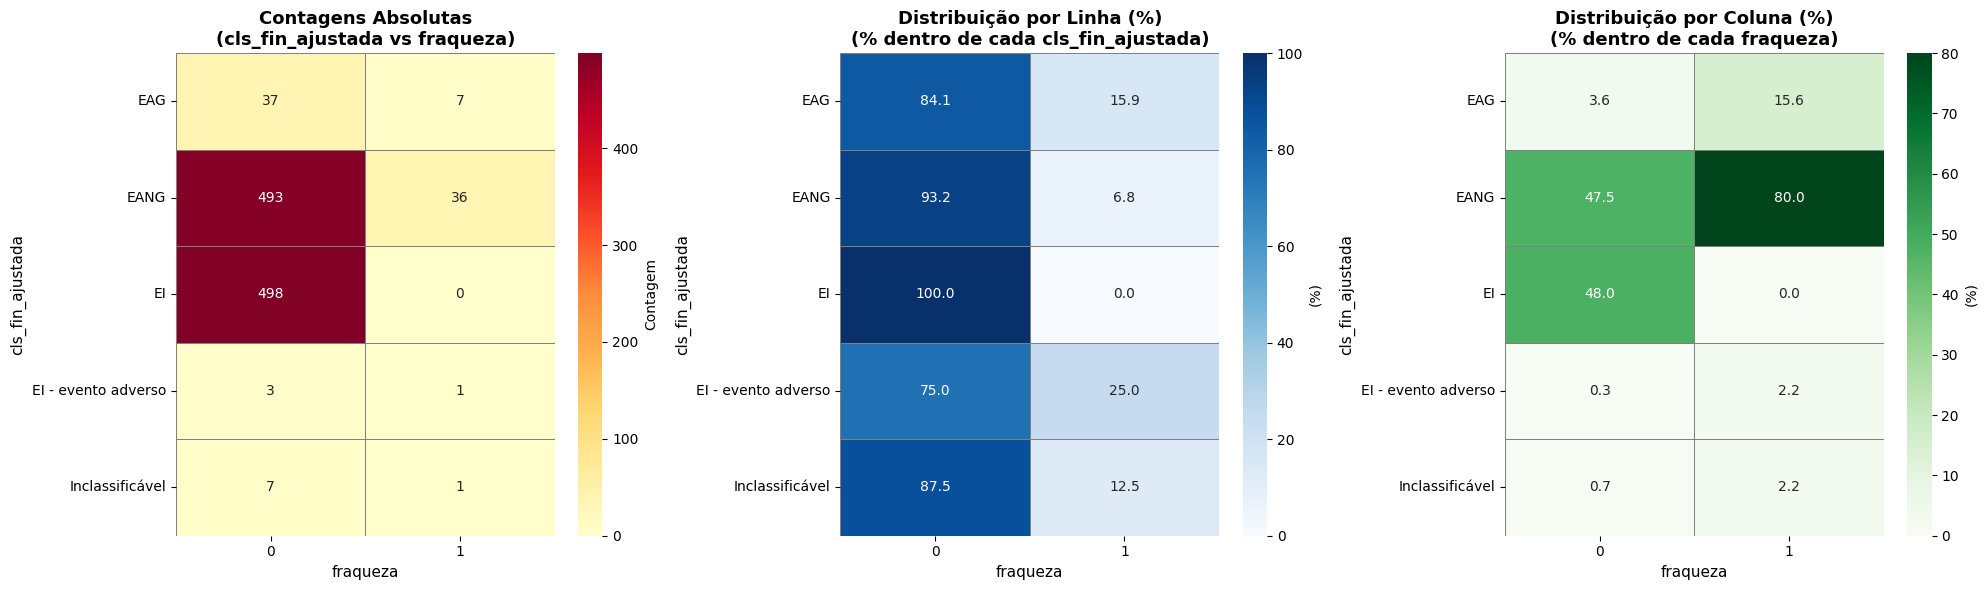


Gerando gráficos para: hipotensao vs cls_fin_ajustada


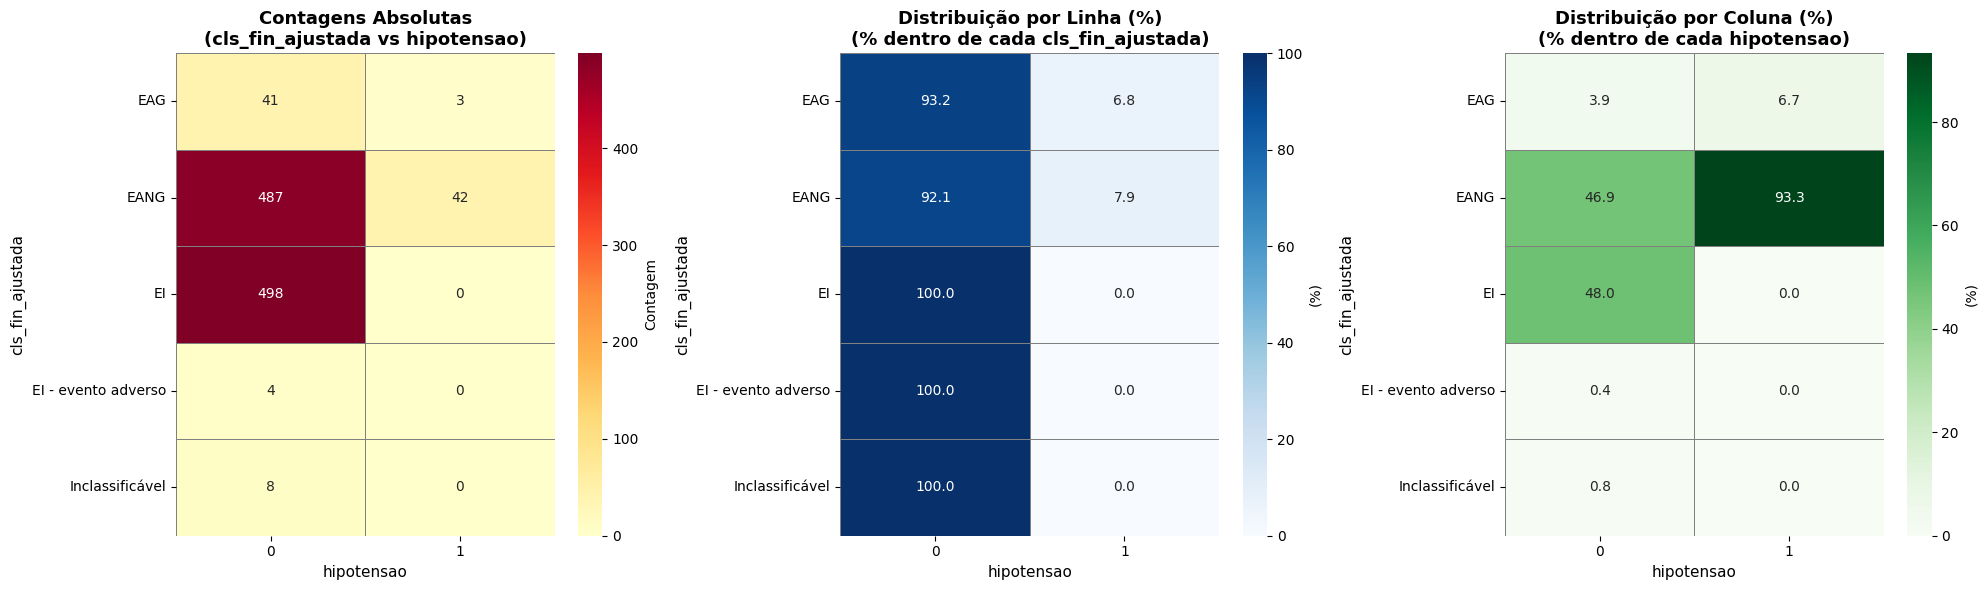


Gerando gráficos para: taquicardia vs cls_fin_ajustada


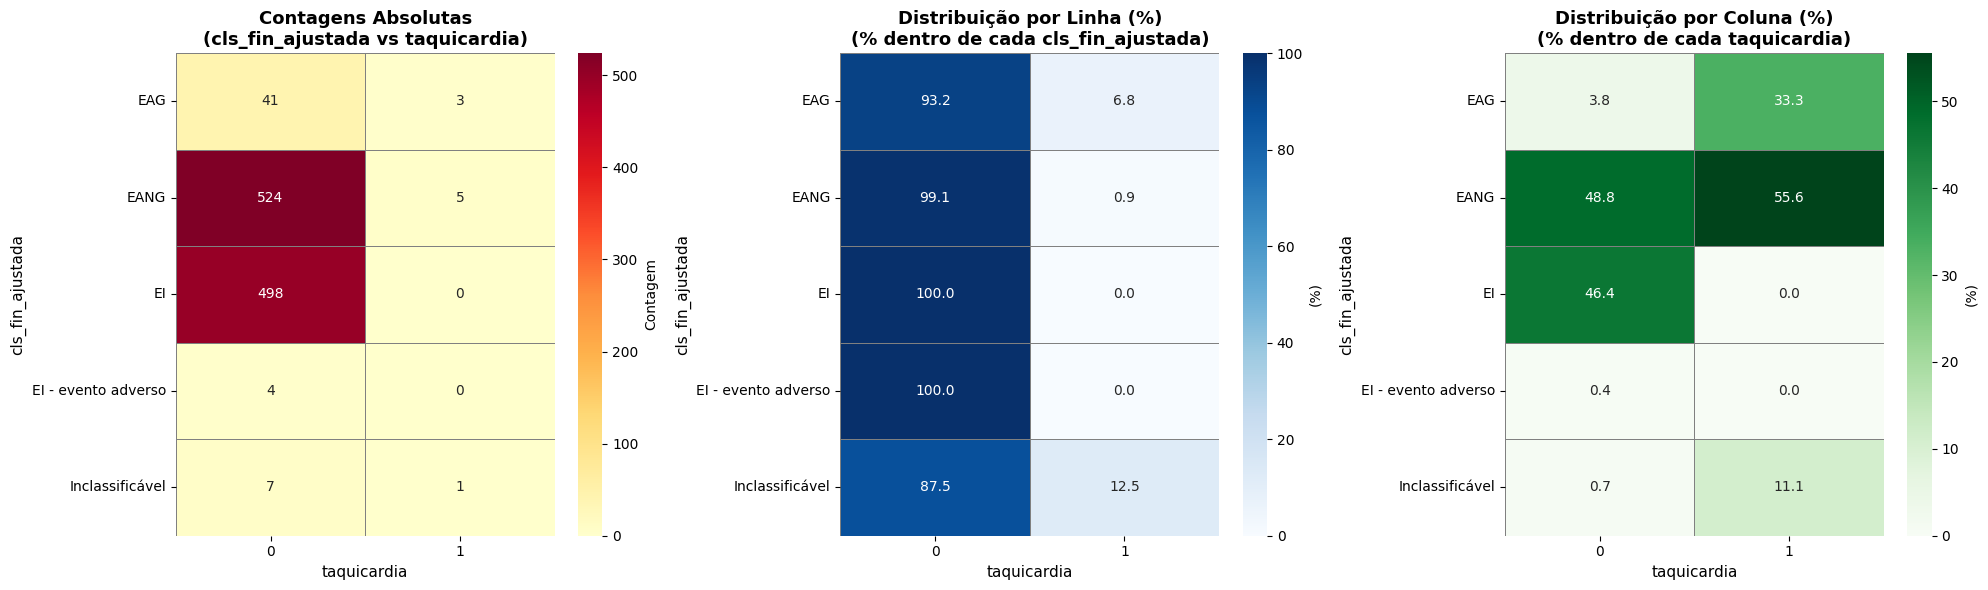


Gerando gráficos para: bradicardia vs cls_fin_ajustada


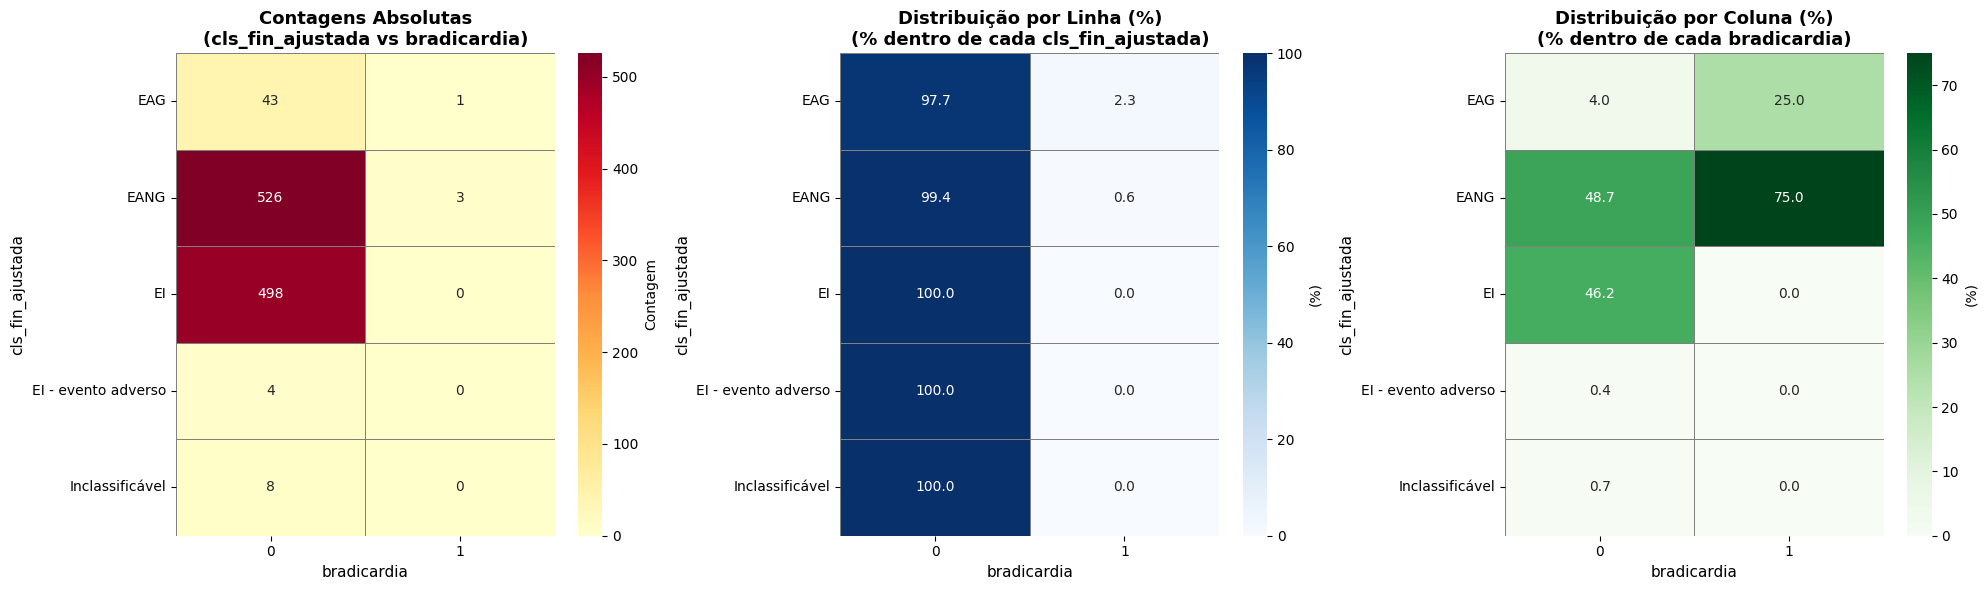


Gerando gráficos para: extremidades_frias vs cls_fin_ajustada


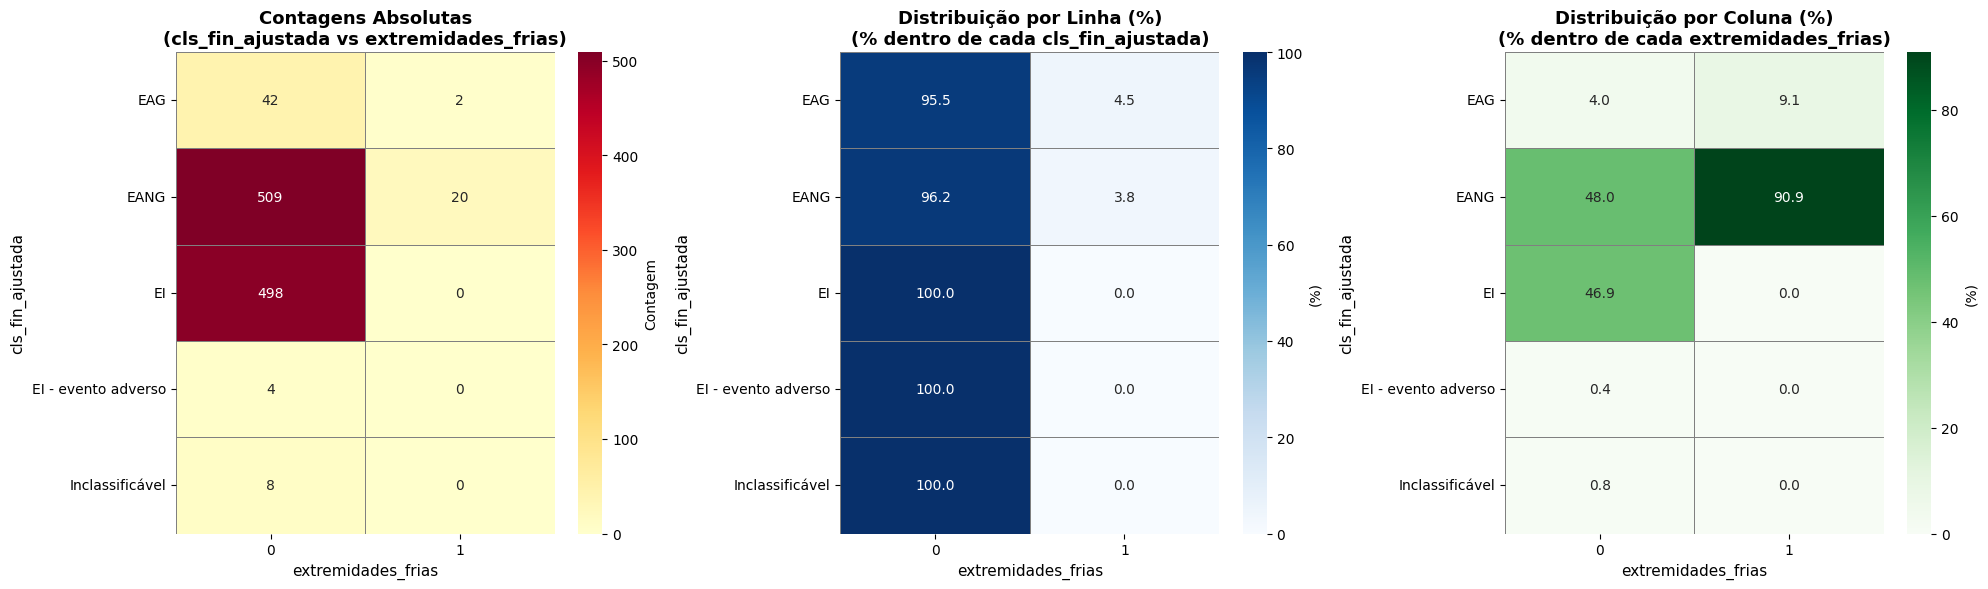


Gerando gráficos para: palidez vs cls_fin_ajustada


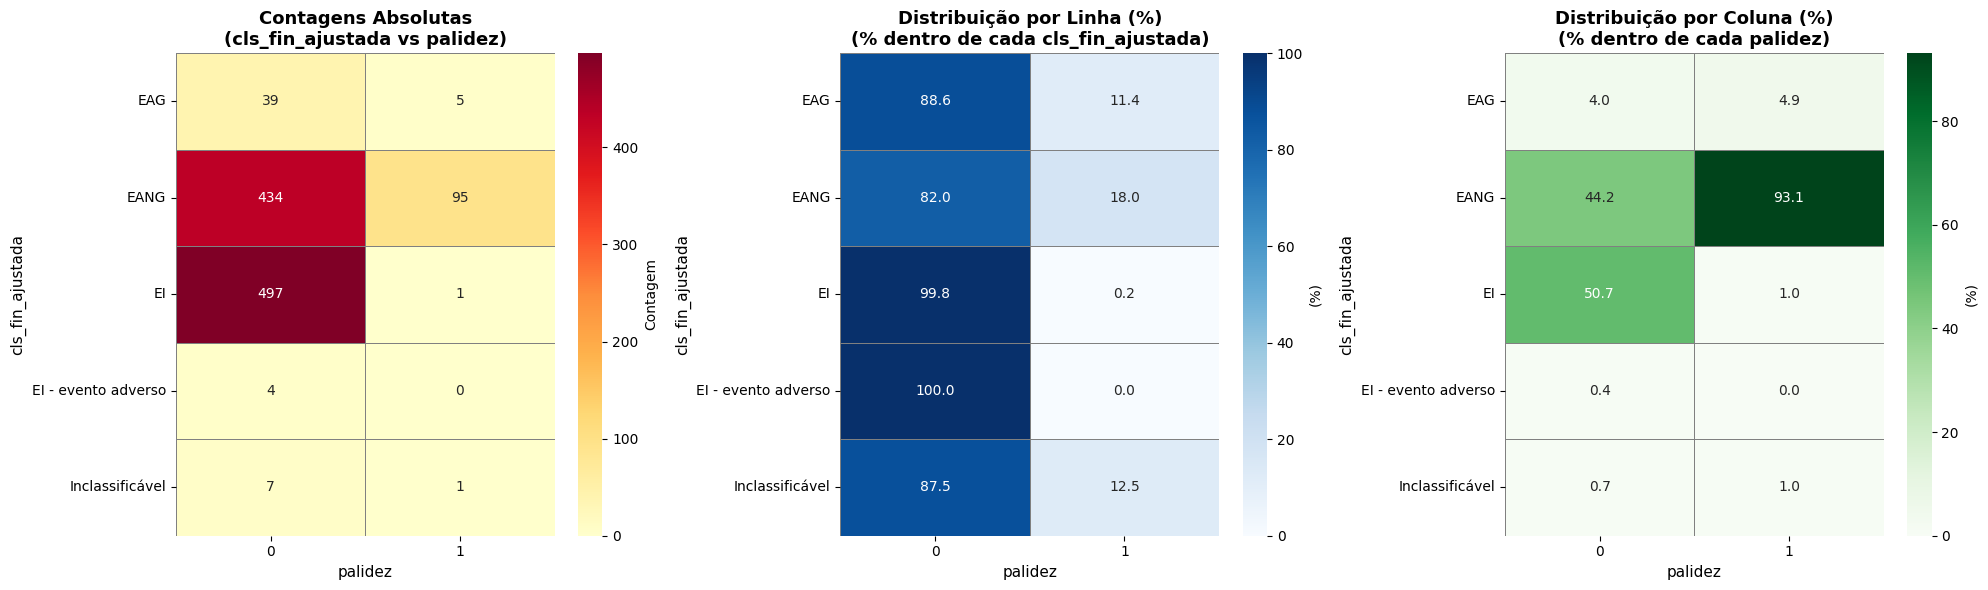


Gerando gráficos para: sudorese vs cls_fin_ajustada


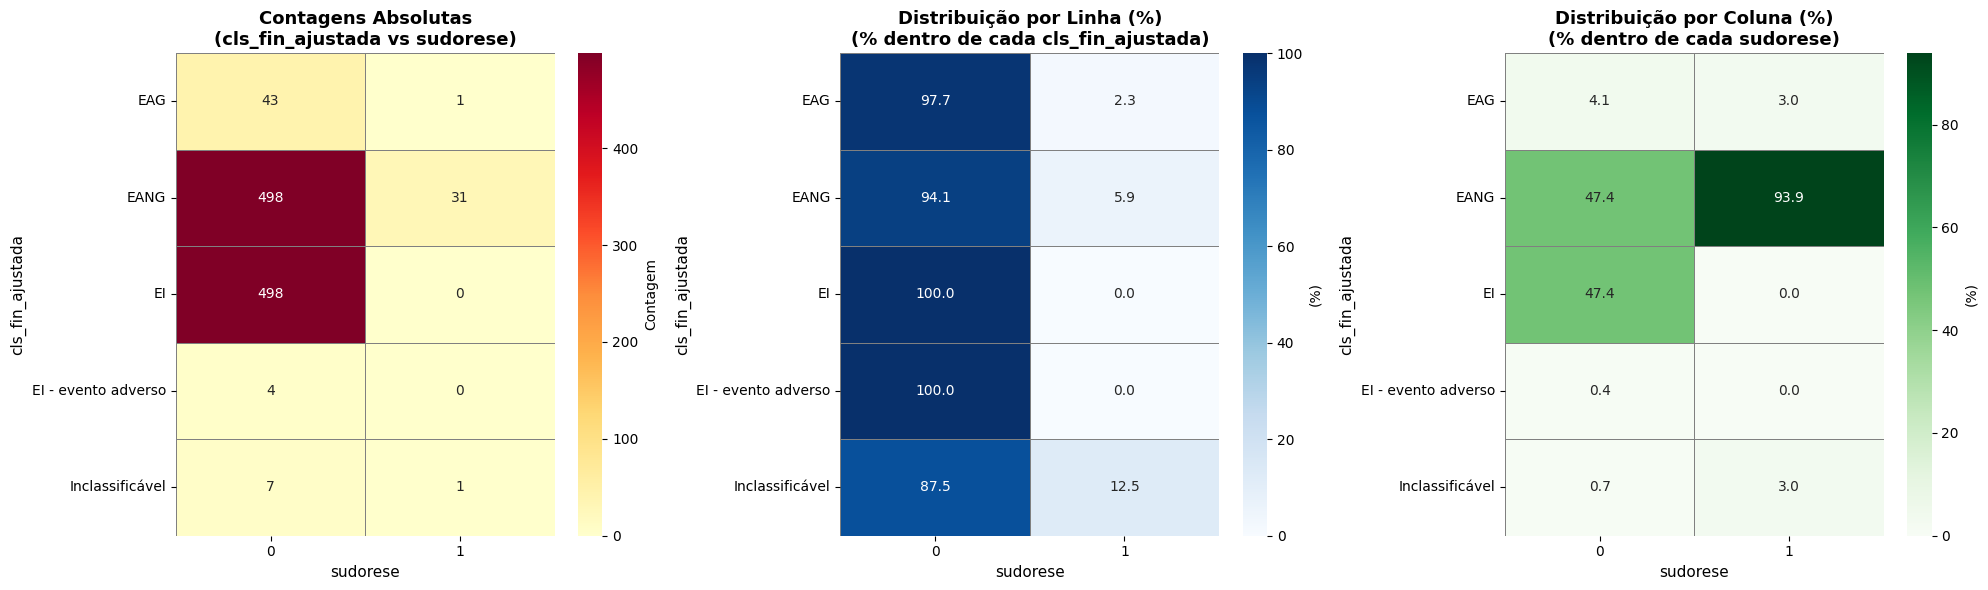


Gerando gráficos para: urticaria vs cls_fin_ajustada


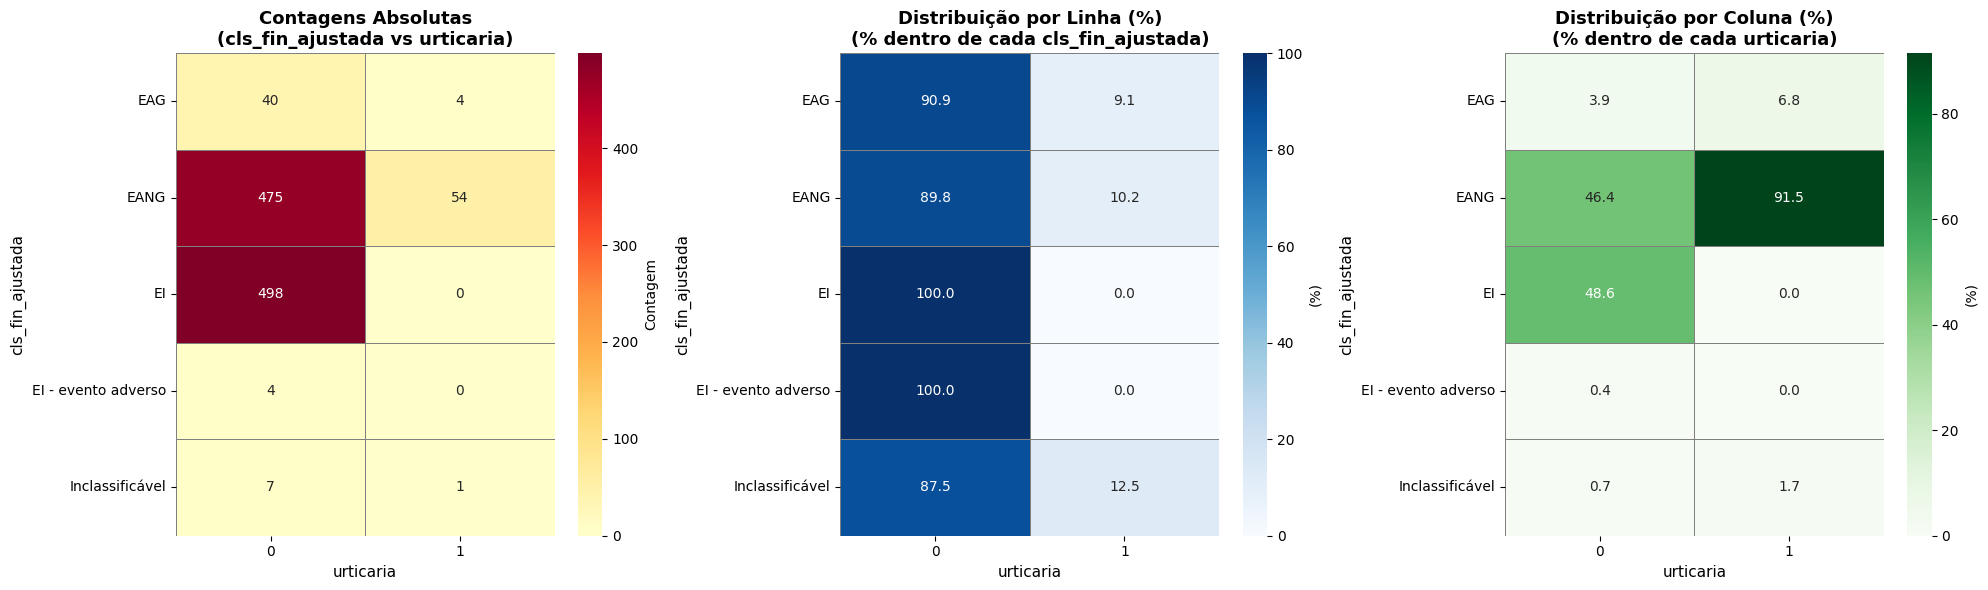


Gerando gráficos para: broncoespasmo vs cls_fin_ajustada


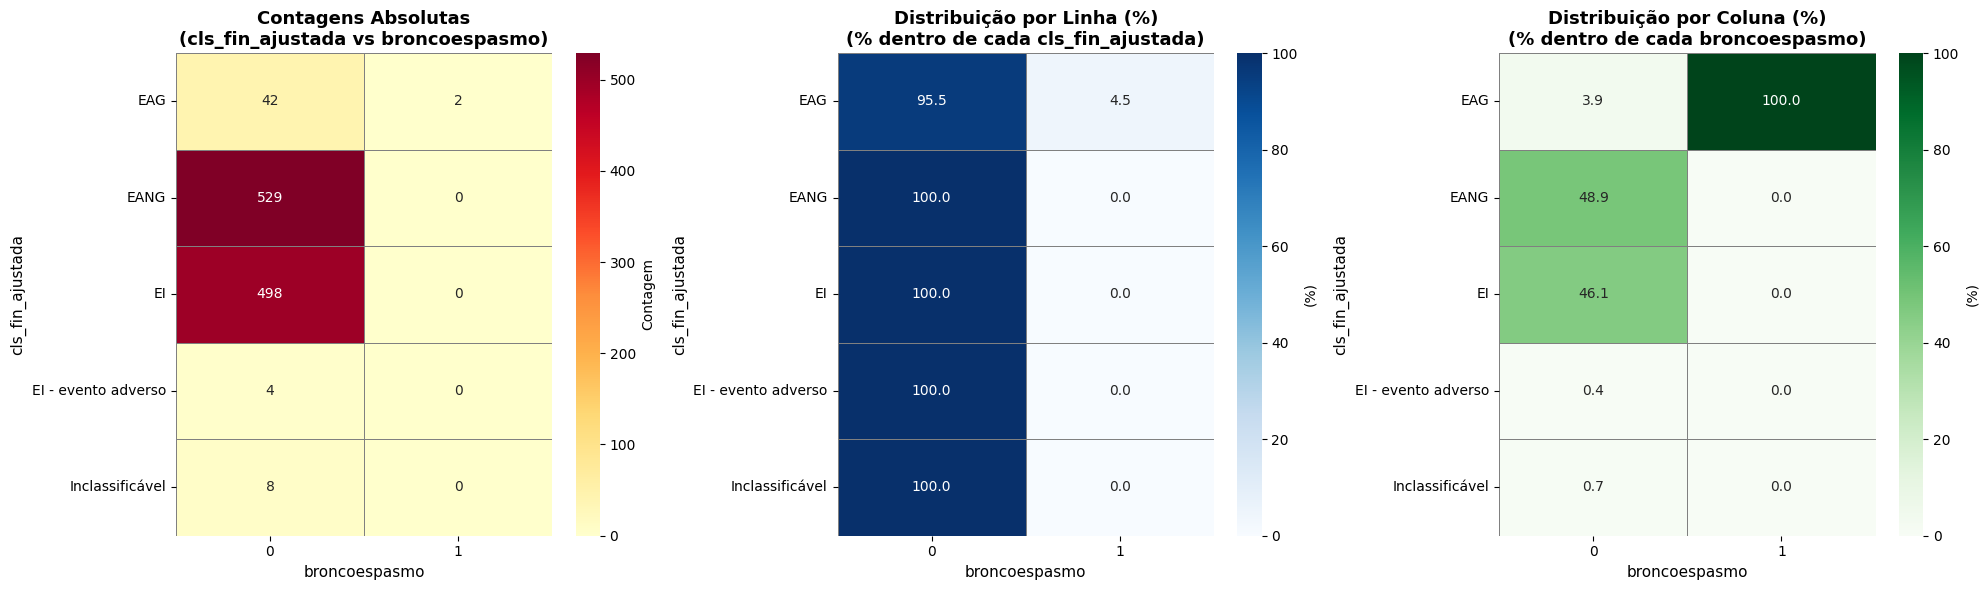


Gerando gráficos para: dispneia vs cls_fin_ajustada


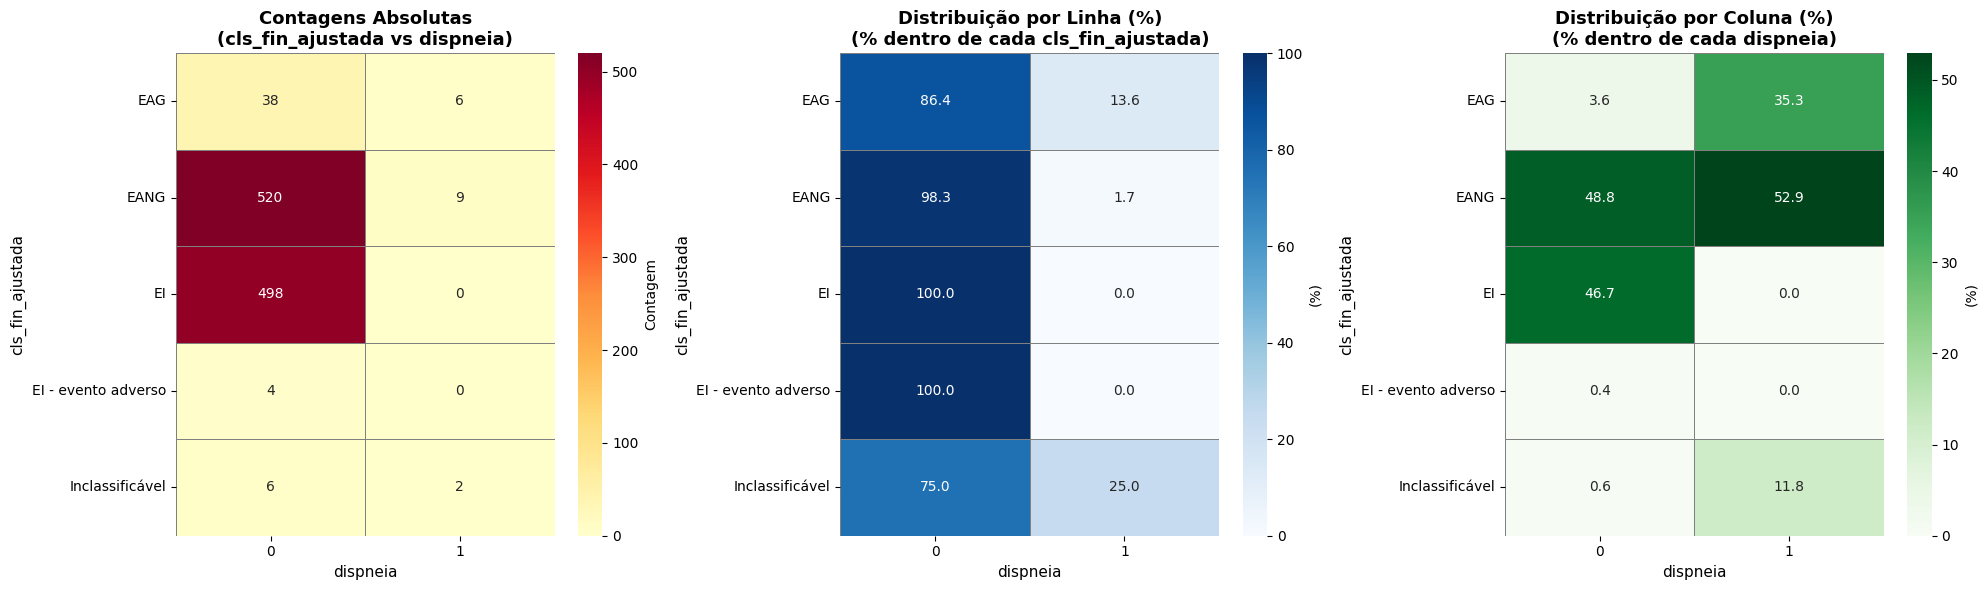


Gerando gráficos para: angioedema vs cls_fin_ajustada


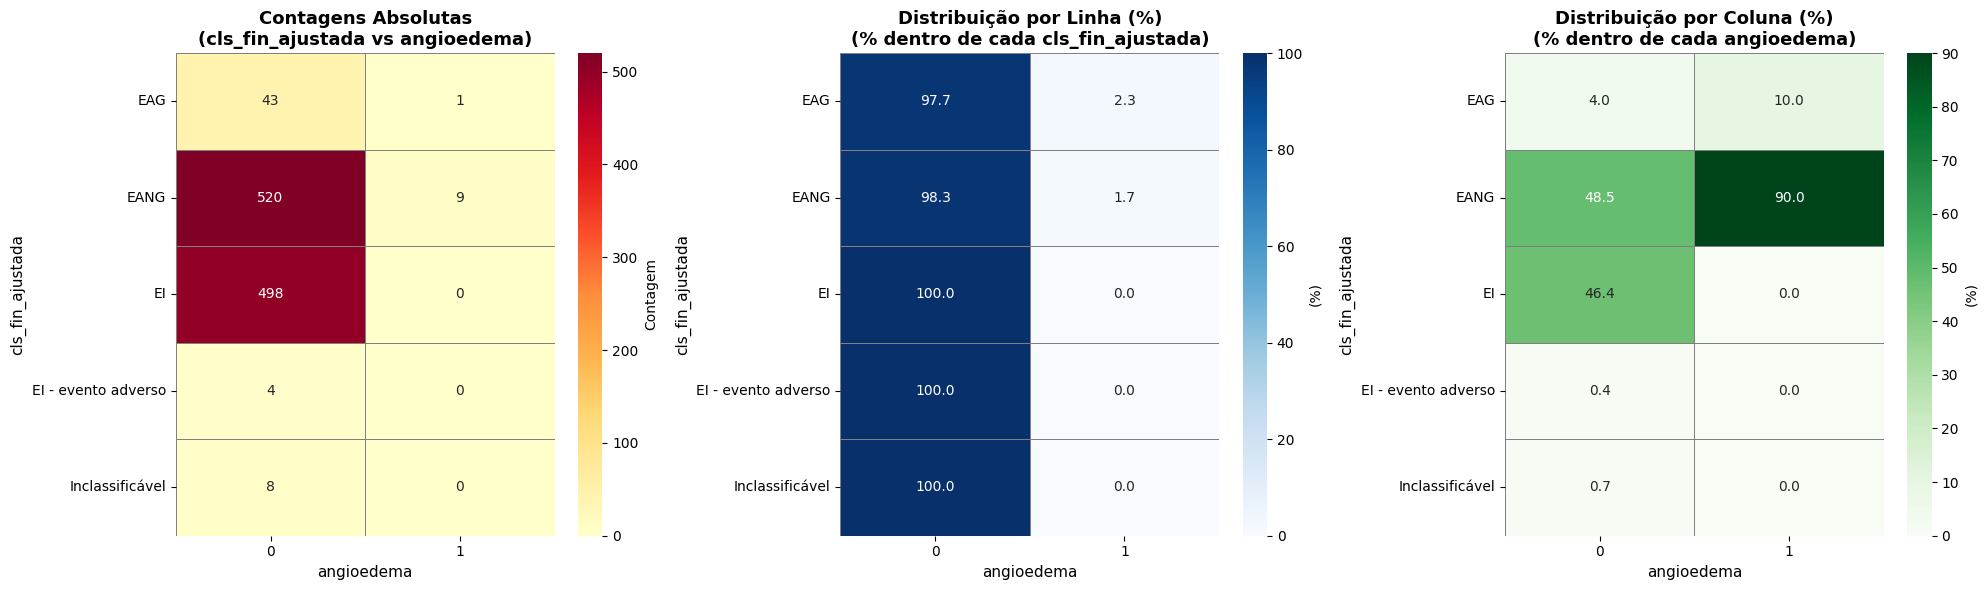


Gerando gráficos para: tremor vs cls_fin_ajustada


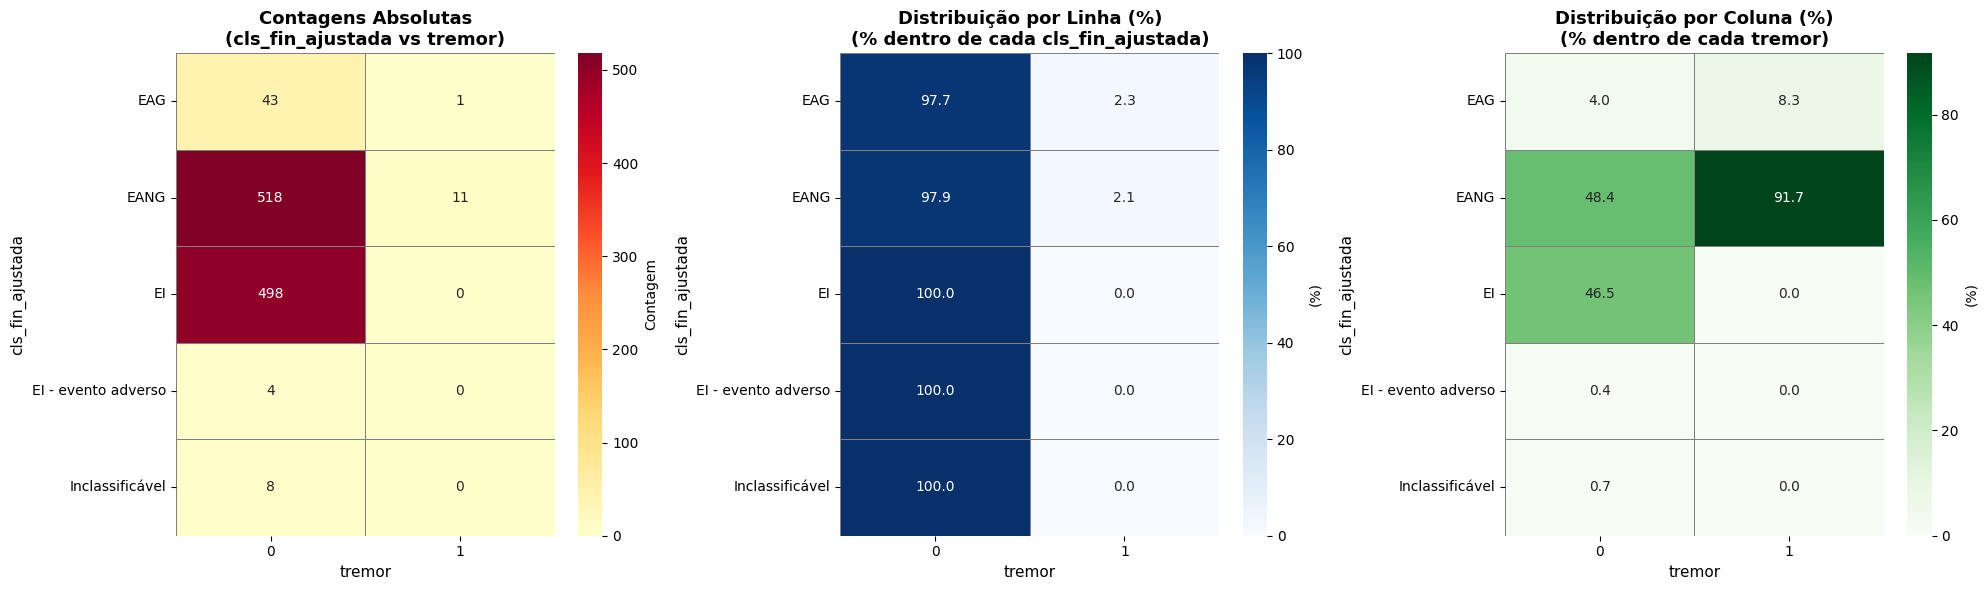


Gerando gráficos para: fotofobia vs cls_fin_ajustada


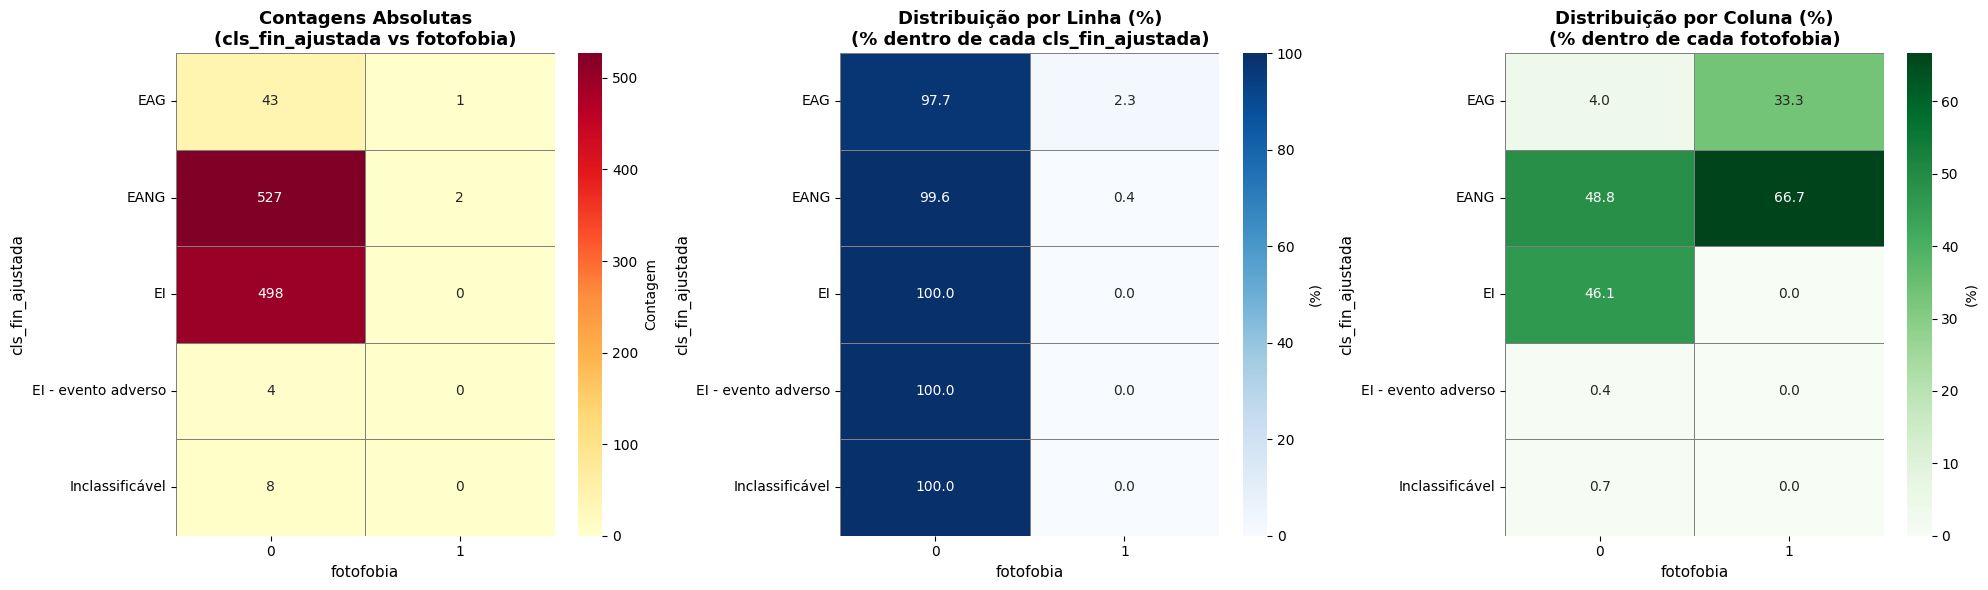


Gerando gráficos para: visao_turva vs cls_fin_ajustada


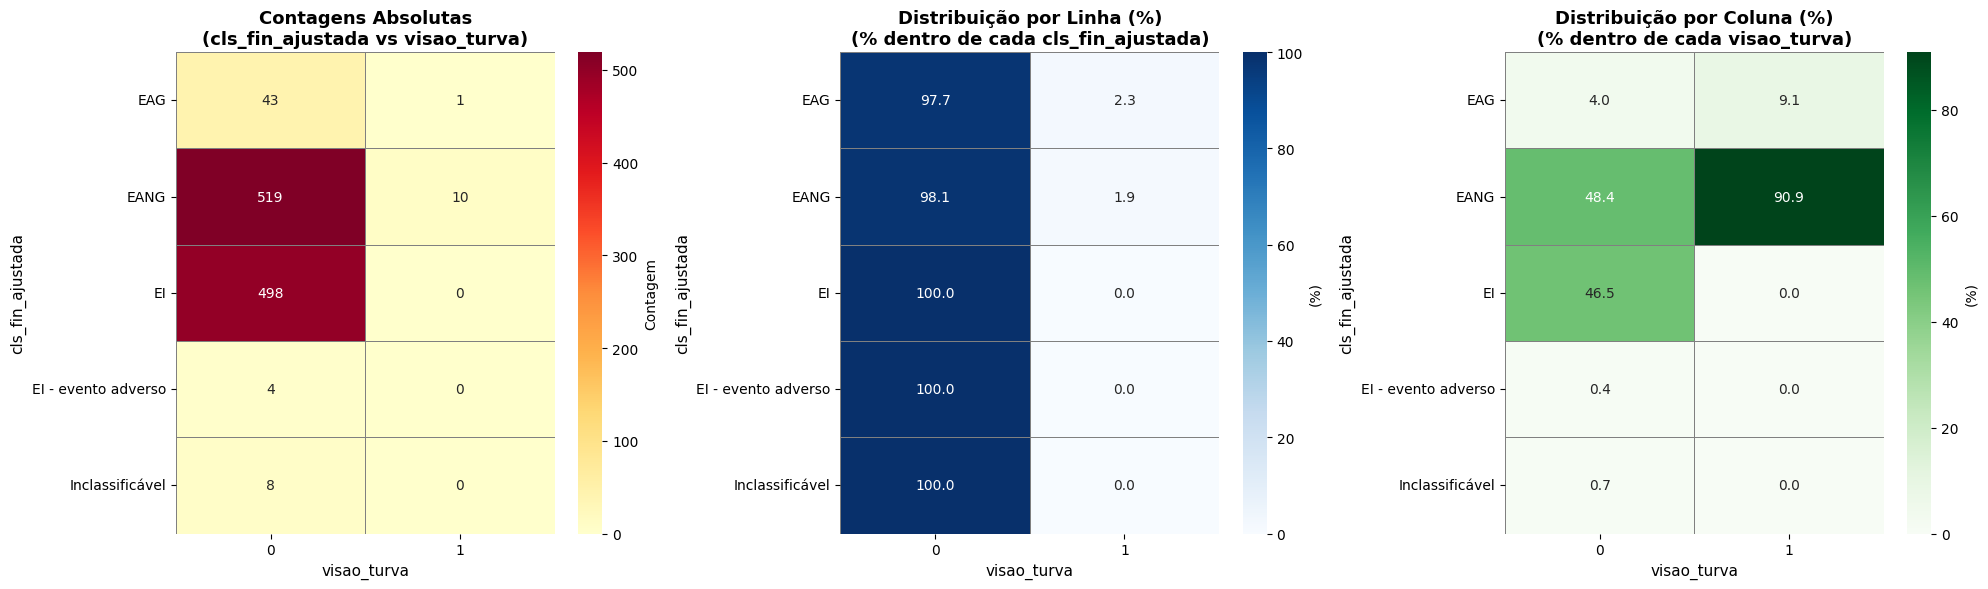


Gerando gráficos para: guillain_barre vs cls_fin_ajustada


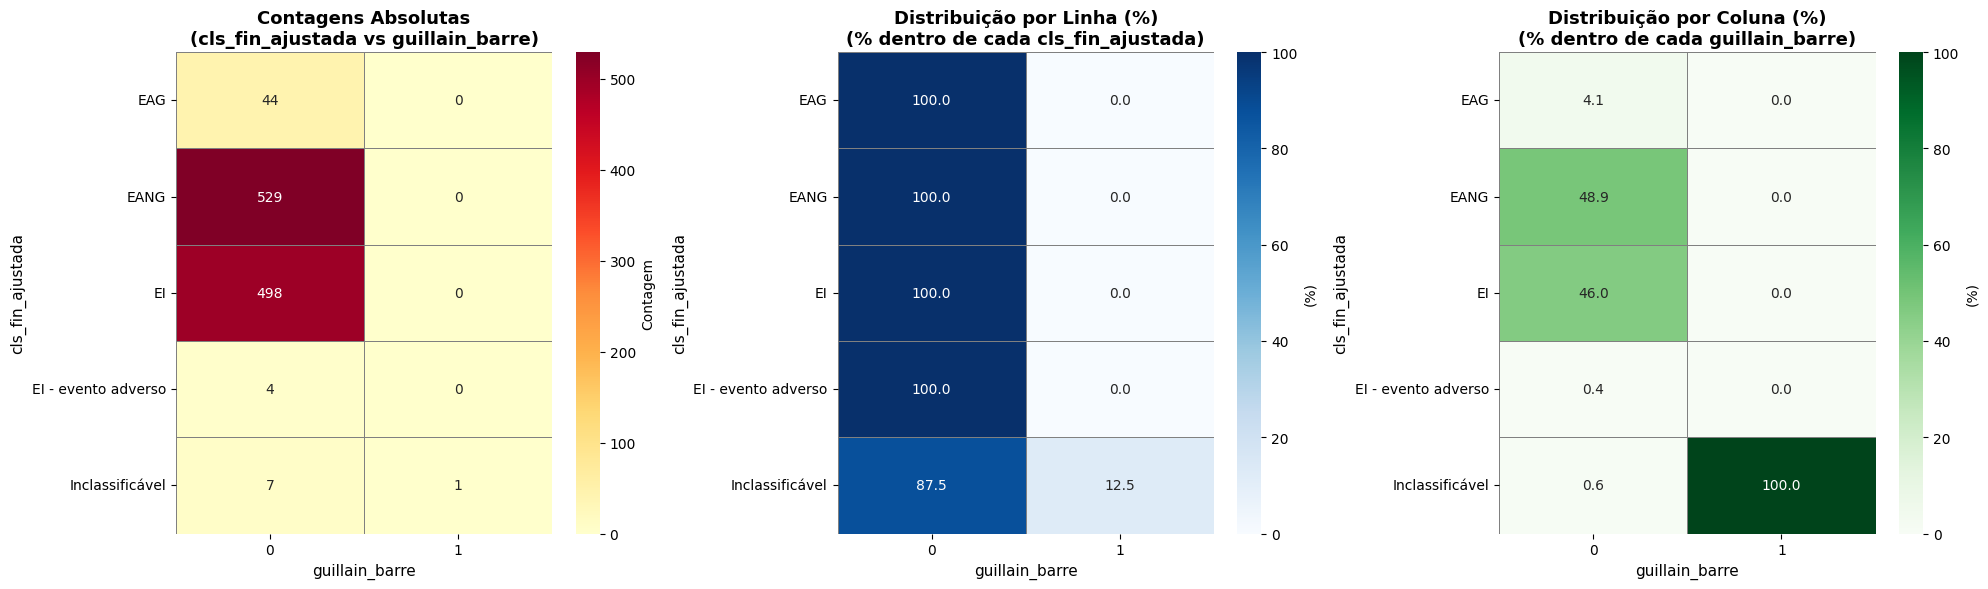


Gerando gráficos para: encefalite vs cls_fin_ajustada


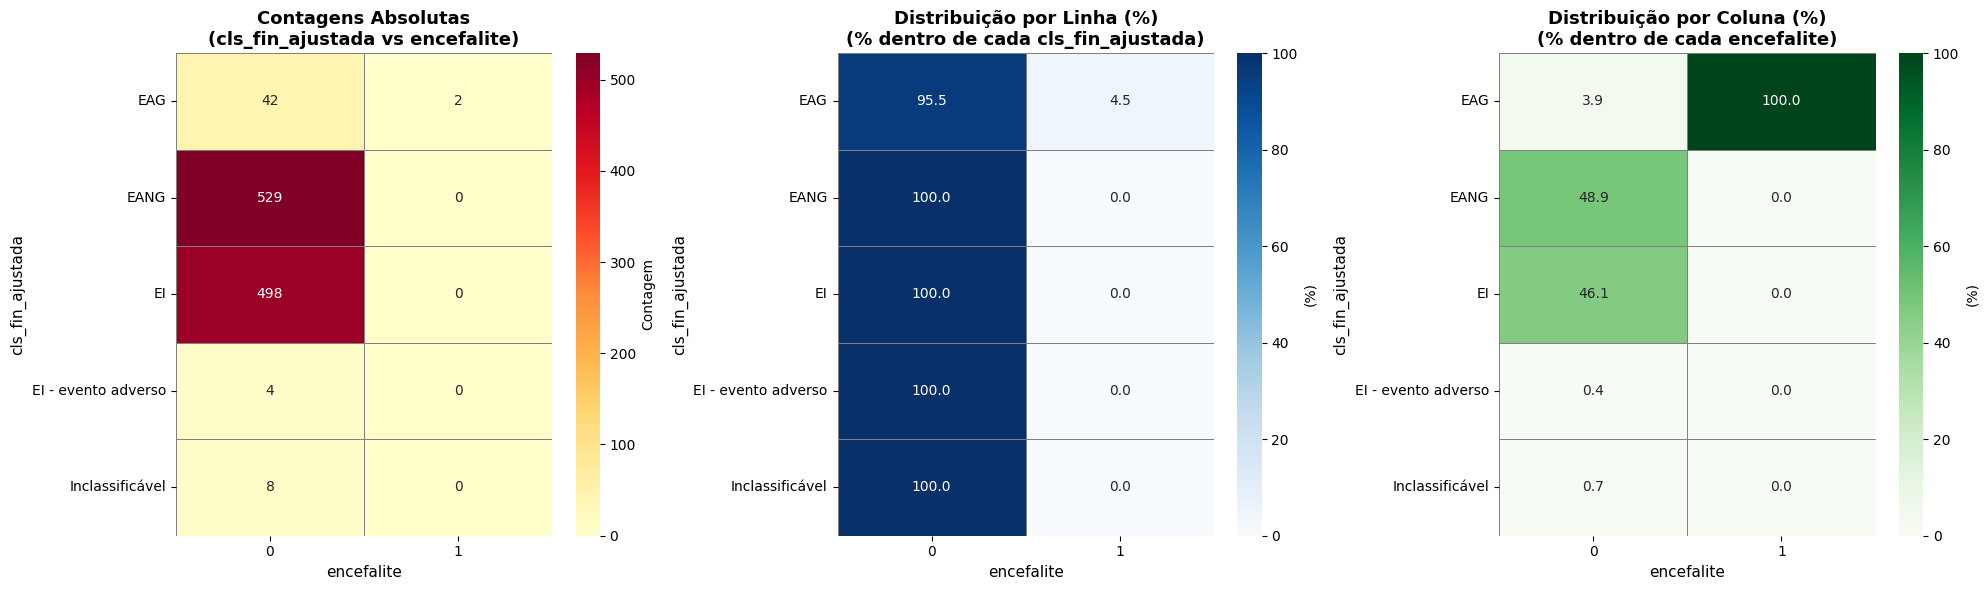


Gerando gráficos para: epilepsia vs cls_fin_ajustada


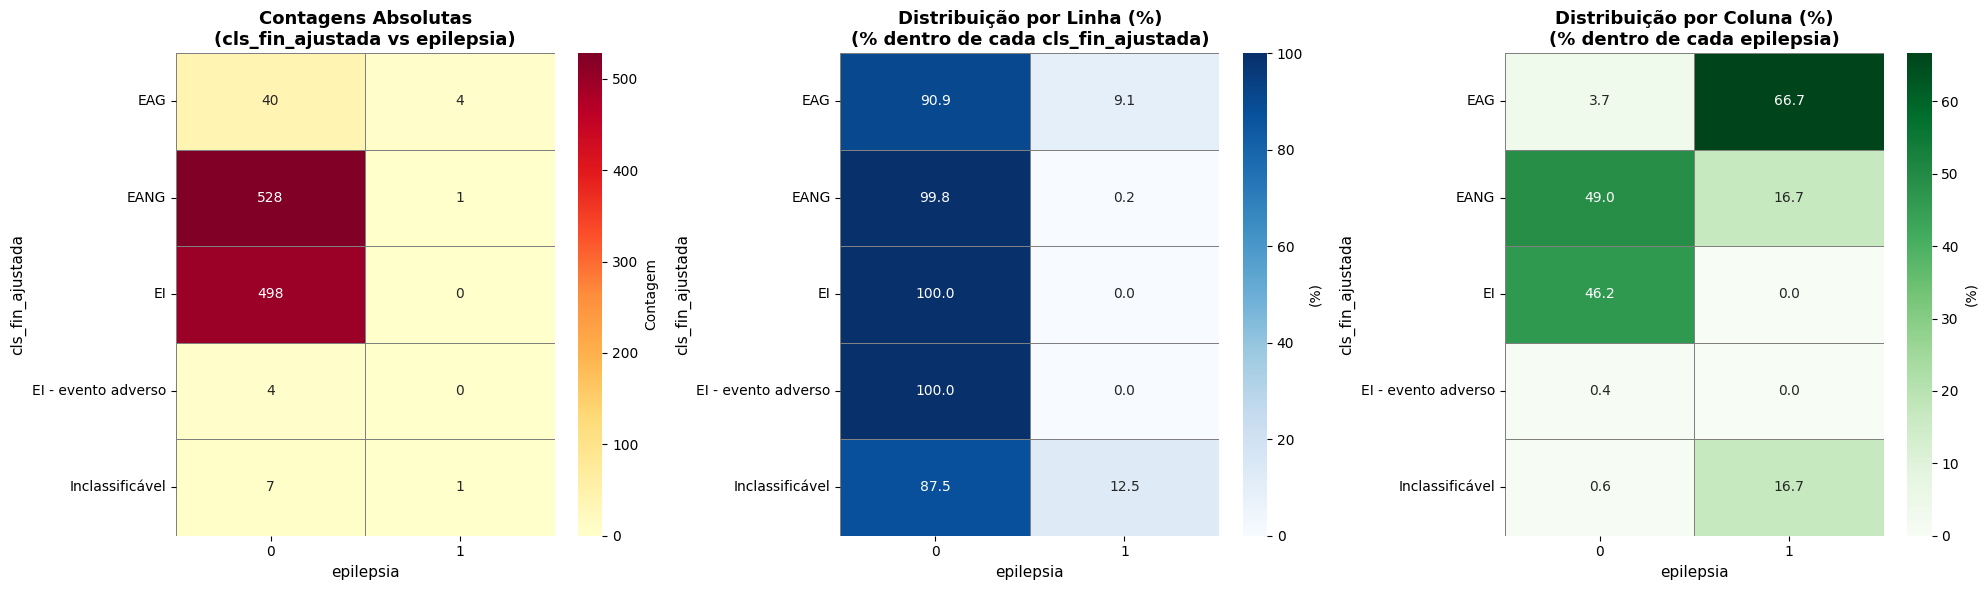


Gerando gráficos para: paralisia vs cls_fin_ajustada


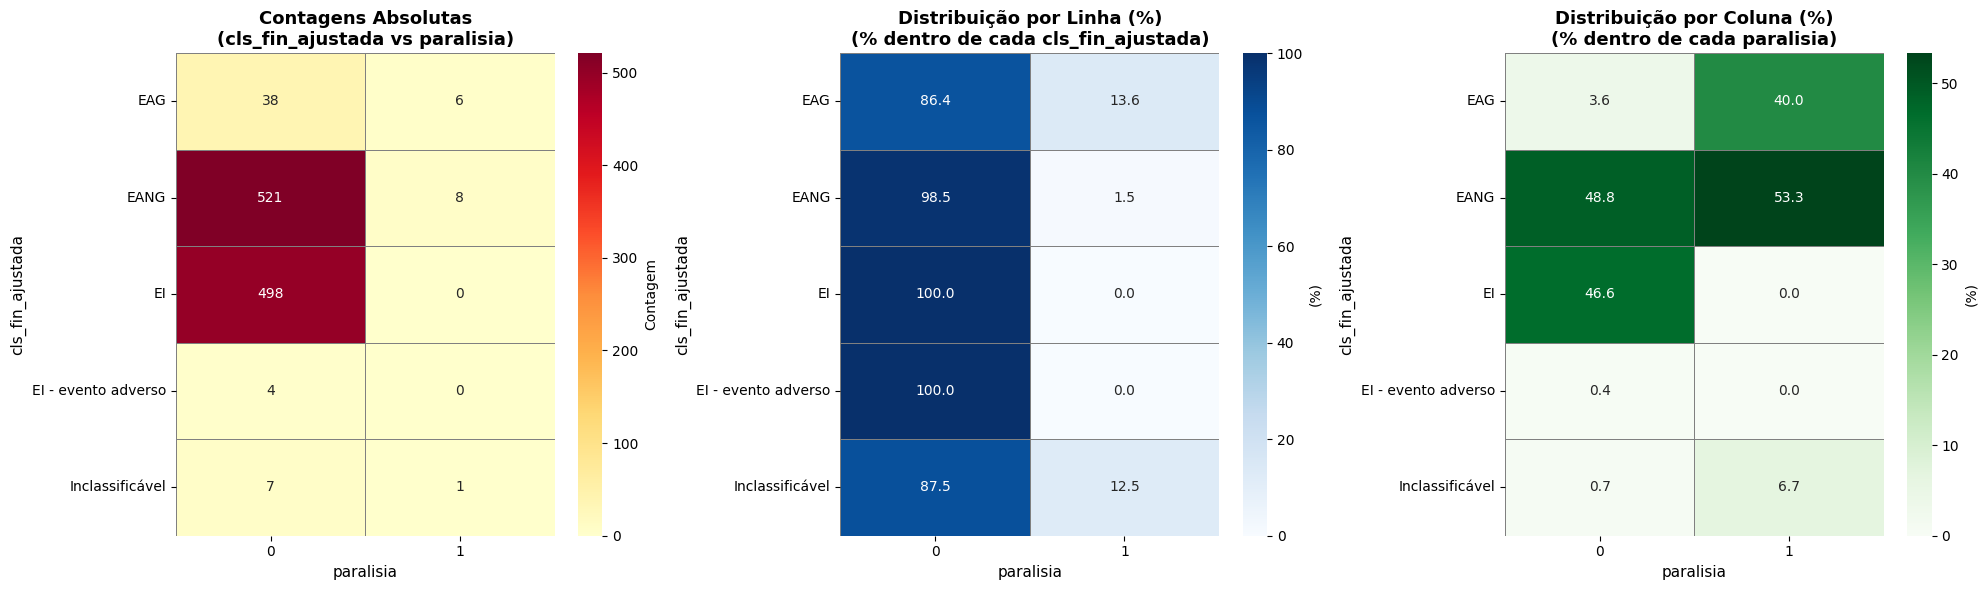


Gerando gráficos para: purpura_trombocitopenica vs cls_fin_ajustada


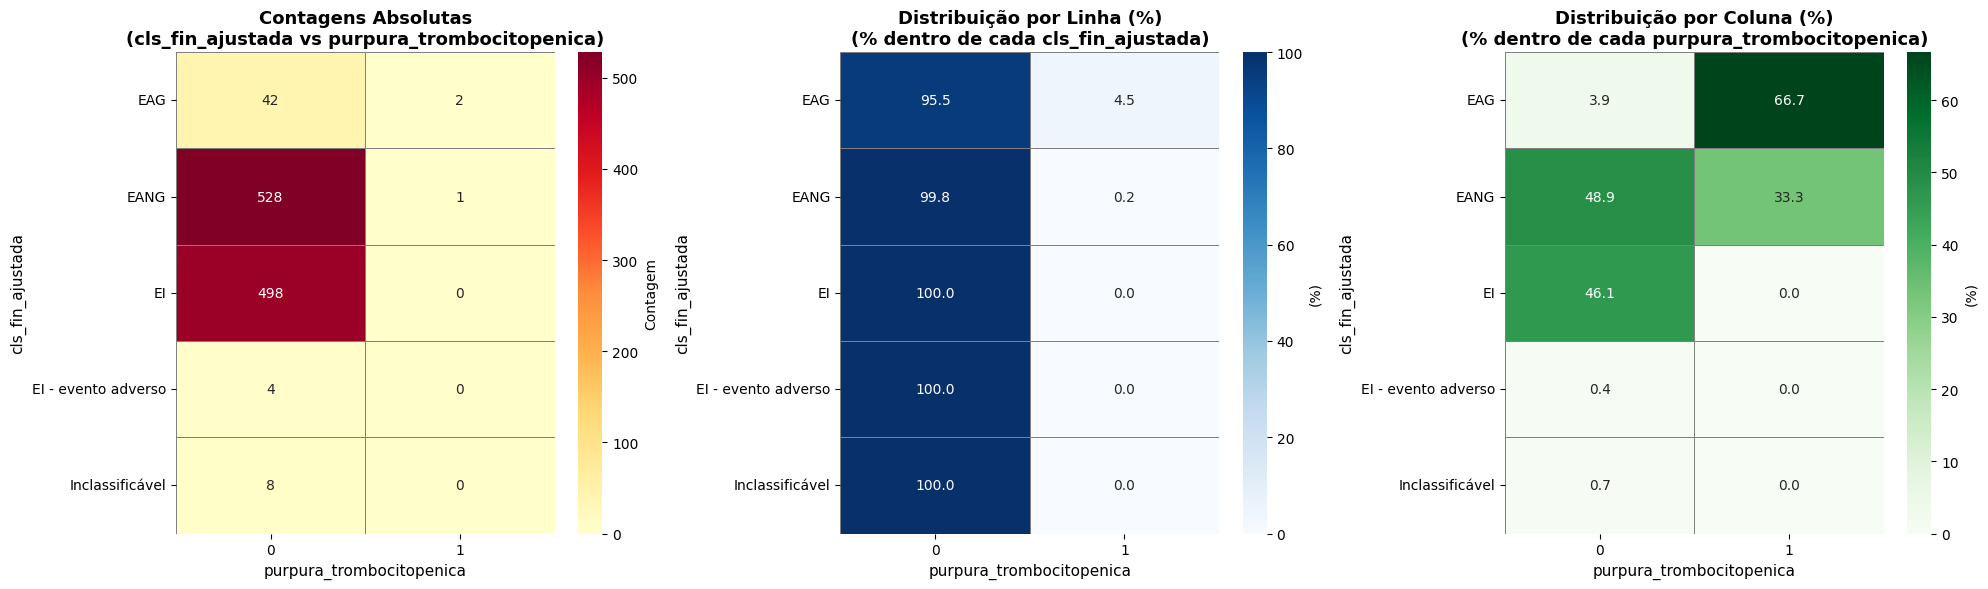


Gerando gráficos para: manifestacoes_locais vs cls_fin_ajustada


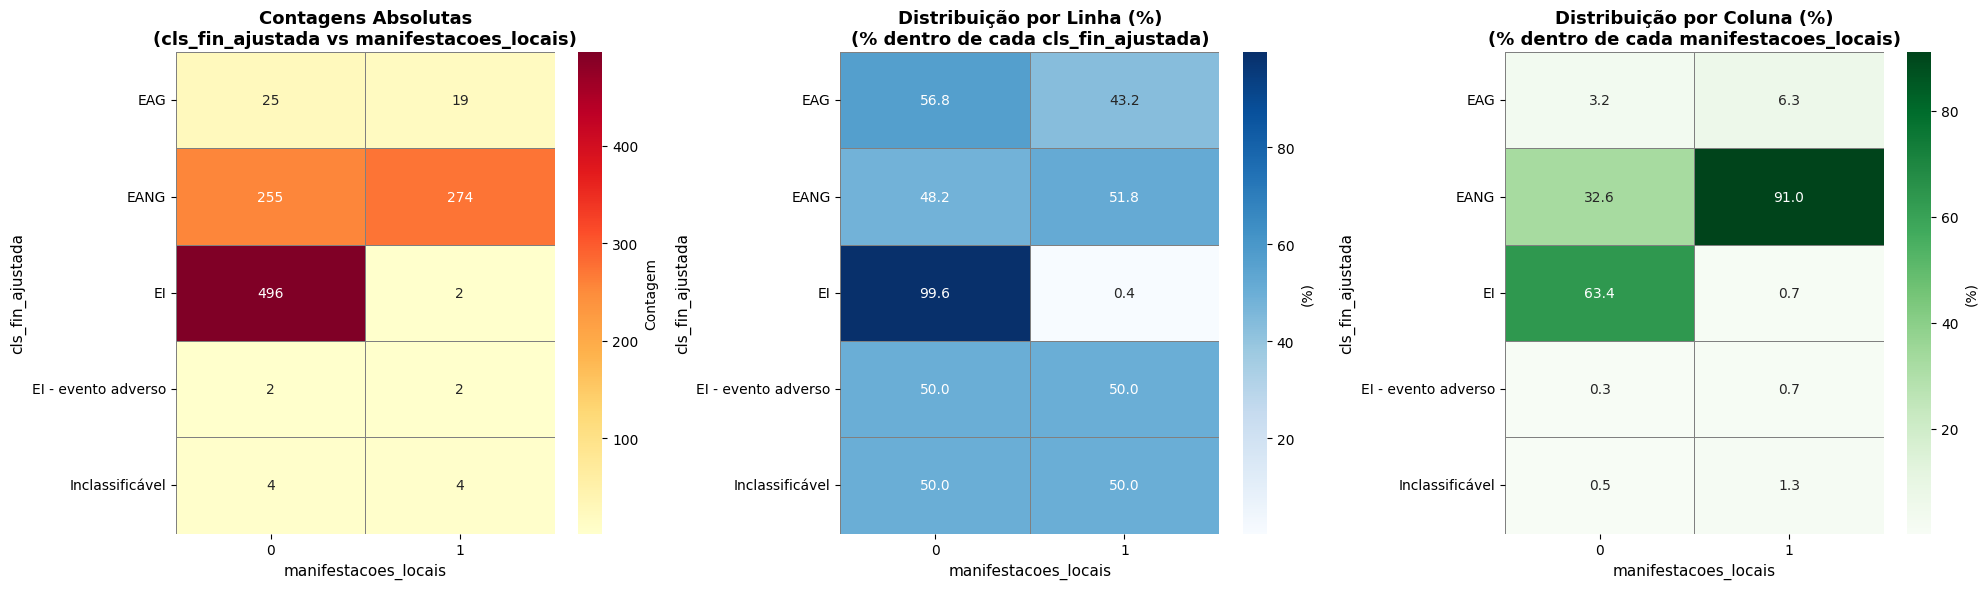


Gerando gráficos para: manifestacoes_sistemicas vs cls_fin_ajustada


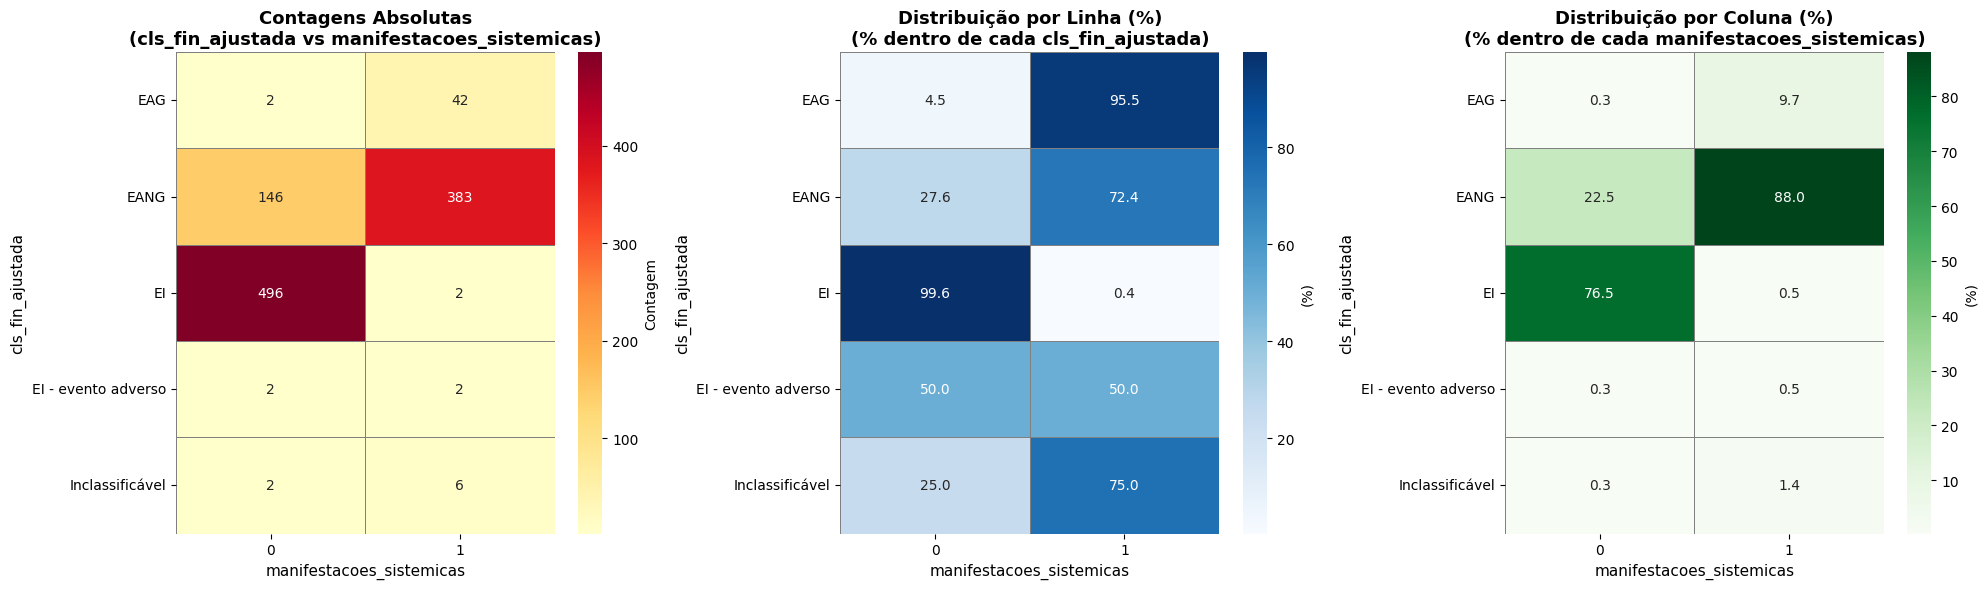

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Como coluna_resposta é uma lista no seu setup ['cls_fin_ajustada'], 
# vamos pegar a string dentro dela para usar nos títulos e eixos.
resposta = coluna_resposta[0] 

# Loop para passar por todas as variáveis explicativas
for comparacao in colunas_explicativas:
    
    # 1. Trava de segurança para variáveis com muitas categorias
    num_categorias = dados_finais[comparacao].nunique()
    if num_categorias > 20:
        print(f"\n{'-'*60}")
        print(f"Pulando '{comparacao}': possui {num_categorias} categorias.")
        print(f"Um heatmap com {num_categorias} colunas ficaria ilegível.")
        print(f"{'-'*60}\n")
        continue # Pula para a próxima variável da lista
        
    print(f"\nGerando gráficos para: {comparacao} vs {resposta}")
    
    # 2. Tabelas de Contingência
    # Usando dropna=False se quiser ver os nulos, ou deixe padrão para ignorá-los
    contagem = pd.crosstab(dados_finais[resposta], dados_finais[comparacao])
    percentual_linhas = pd.crosstab(dados_finais[resposta], dados_finais[comparacao], normalize='index') * 100
    percentual_colunas = pd.crosstab(dados_finais[resposta], dados_finais[comparacao], normalize='columns') * 100

    # 3. Configuração da Figura
    fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Aumentei um pouco a largura para caber bem as 3

    # --- Gráfico 1: Contagens Absolutas ---
    sns.heatmap(contagem, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Contagem'},
                ax=axes[0], linewidths=0.5, linecolor='gray')
    axes[0].set_title(f'Contagens Absolutas\n({resposta} vs {comparacao})', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(comparacao, fontsize=11)
    axes[0].set_ylabel(resposta, fontsize=11)

    # --- Gráfico 2: Distribuição por Linha ---
    sns.heatmap(percentual_linhas, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '(%)'},
                ax=axes[1], linewidths=0.5, linecolor='gray')
    axes[1].set_title(f'Distribuição por Linha (%)\n(% dentro de cada {resposta})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(comparacao, fontsize=11)
    axes[1].set_ylabel(resposta, fontsize=11)

    # --- Gráfico 3: Distribuição por Coluna ---
    sns.heatmap(percentual_colunas, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '(%)'},
                ax=axes[2], linewidths=0.5, linecolor='gray')
    axes[2].set_title(f'Distribuição por Coluna (%)\n(% dentro de cada {comparacao})', fontsize=13, fontweight='bold')
    axes[2].set_xlabel(comparacao, fontsize=11)
    axes[2].set_ylabel(resposta, fontsize=11)

    # Ajusta o layout para não cortar os eixos e exibe
    plt.tight_layout()
    plt.show()